In [ ]:
#asr transcription
#prompt
#reading error type, location reference, start time
#

#Detection

In [ ]:
import pandas as pd
import os
import numpy as np

Reformat_path = "/content/drive/MyDrive/REDC/Jasmin_Child_Reformat_SanneAnno/"
children_data_path = "/content/drive/MyDrive/REDC/JASMIN_textgrid/"
child_speaker_file = os.path.join(children_data_path+"sprekers_informatie.xlsx")
child_data = pd.read_excel(child_speaker_file, index_col=0, usecols = np.arange(0,11))

In [ ]:
def read_phone_file(filename):
    phone = []
    with open(filename, 'r') as file:
        for line in file:
            # Split each line into key and value
            phone.append(line.strip())

    return " ".join(phone)

In [ ]:
child_level = child_data.loc[child_data['Niveau']=='AVI-9']
child_level

##Extract Ground Truth

In [ ]:
# read word2phoneme dictionary file to a dictionary
def read_dict_file(filename):
    dictionary = {}
    with open(filename, 'r') as file:
        for line in file:
            # Split each line into key and value
            key, value = line.strip().split('\t')
            # Add key-value pair to the dictionary
            dictionary[key.strip()] = value.strip()
    return dictionary


#read prompt word2phoneme dictionary from G2P output, use index, string('1') for AVI-1
AVI_dict={}
dict_path='/content/drive/MyDrive/REDC/prompt_word_dict/'

for dict in os.listdir(dict_path):
  if dict.endswith('.dict'):
    my_dict = read_dict_file(dict_path+dict)
    print(dict)
    key=str(dict[4:5])
    AVI_dict[key]=' '.join(list(my_dict.values()))

#print(AVI_dict['1'])

AVI 1_word.dict
AVI 5_word.dict
AVI 4_word.dict
AVI 8_word.dict
AVI 7_word.dict
AVI 6_word.dict
AVI 9_word.dict
AVI 2_word.dict
AVI 3_word.dict


In [ ]:
AVI_dict['9'] = read_phone_file("/content/drive/MyDrive/REDC/Phone/ref9-phone.txt")

In [ ]:
AVI_dict['9']

'm E+ n o p a h e f t w E l t w I n t @ G d Y+ v @ h E+ x e f s @ A l @ m a l @ n a m z @ w o n @ I n @ n h O k I n d @ t Y+ n E n s @ k r E+ G @ E l k @ d A x r a n @ z a d E n p 2 l v r Y x t @ t @ e t @ d i E b @ z @ n o d @ x O m v O l d u n d @ e n E r Z i t @ h E b @ E n O m d @ t E m p @ r a t y r v A n Y n l I x a m O p E+ l t @ k Y n @ h A+ d @ o p a v @ r t E l d @ m @ d A t E r v e l s o r t @ d Y+ v @ b @ s t a n e v A n h E n I s d @ p O s d Y+ f d A t I z @ n d Y+ f d i j @ n h e l x r o t @ A f s t A n t I n e n k e r k A n A f l E G @ E x @ m A k @ l @ k d @ w E G n a r h Y+ s t @ r Y x f I n t E n d a r h e f t i d Y+ f x e N k O m p A s O f l A n k a r f o r n o d @ x h E+ w e t @ w E G d o r n a r d @ s O n t @ k E+ k @ d a r O m w E r d @ z @ I n d @ t E+ t v A n d @ A+ d @ r o m E+ n @ E n G r i k @ x @ b r Y+ k t O m b @ r I x t @ t @ v @ r s t y r @ t u n h A t m E n I m @ r s n O x e n A+ t o O f l i x t Y+ x O m p O s t m e t @ v @ r v u r @ d @ d Y+ v @ d r u 

In [ ]:
#Get error ground truth (location and type)

#example anno_keys(['N000025', 'N000025_FON', 'N000025_SEG', 'Prompt', 'Reading strategy', 'Reading errors'])
Prompt_id = 'Prompt' #may contain errors(missing last letter) due to import errors of unknown encoding, use AVI dict instead
Error_id = 'Reading errors'
Phone_id = '_SEG' #forced alignment
Re_Error_id = 'Reading strategy'

def get_error_reference(speaker):

  anno_addr = os.path.join(Reformat_path+speaker+".pkl")
  anno_temp = pd.read_pickle(anno_addr)

  speaker_id=anno_temp.tier_name[0]

  Prompt_audio = anno_temp.loc[anno_temp['tier_name'] == Prompt_id]
  Error_audio = anno_temp.loc[anno_temp['tier_name'] == Error_id]
  Re_Error_audio = anno_temp.loc[anno_temp['tier_name'] == Re_Error_id]
  Phone_audio = anno_temp.loc[anno_temp['tier_name'] == speaker_id+Phone_id]
  if (Prompt_audio.iloc[0].text[0:6]=='wil je'):
    print('Discard instruction prompt in speaker: ',speaker)
    Prompt_audio=Prompt_audio.drop(Prompt_audio.index[0])

  return Prompt_audio, Re_Error_audio, Error_audio, Phone_audio


def get_story_prompt_range(Prompt_audio):
  start_time = Prompt_audio.iloc[0].start_time
  end_time = Prompt_audio.iloc[-1].end_time

  return start_time, end_time #string type

def trim_df_by_time(df, start_prompt_time, end_prompt_time):
  df['start_time'] = df['start_time'].astype(float)
  df['end_time'] = df['end_time'].astype(float)

  df=df.loc[(df['end_time'] > float(start_prompt_time))& (df['start_time'] < float(end_prompt_time))]
  return df


def get_error_phone_inprompt(speaker):

  Prompt_audio, Re_Error_audio, Error_audio, Phone_audio = get_error_reference(speaker)

  start_prompt_time, end_prompt_time = get_story_prompt_range(Prompt_audio)

  Error_audio = trim_df_by_time(Error_audio, start_prompt_time, end_prompt_time)
  Phone_audio = trim_df_by_time(Phone_audio, start_prompt_time, end_prompt_time)
  Re_Error_audio = trim_df_by_time(Re_Error_audio, start_prompt_time, end_prompt_time)

  return Error_audio, Phone_audio, Re_Error_audio

def get_error_word_inprompt(speaker):

  Prompt_audio, Re_Error_audio, Error_audio, Phone_audio = get_error_reference(speaker)

  anno_addr = os.path.join(Reformat_path+speaker+".pkl")
  anno_temp = pd.read_pickle(anno_addr)

  speaker_id=anno_temp.tier_name[0]
  Word_audio = anno_temp.loc[anno_temp['tier_name'] == speaker_id]

  start_prompt_time, end_prompt_time = get_story_prompt_range(Prompt_audio)

  Error_audio = trim_df_by_time(Error_audio, start_prompt_time, end_prompt_time)
  Word_audio = trim_df_by_time(Word_audio, start_prompt_time, end_prompt_time)
  Re_Error_audio = trim_df_by_time(Re_Error_audio, start_prompt_time, end_prompt_time)

  return Error_audio, Word_audio, Re_Error_audio



In [ ]:
#test
#Error
'fn000151' #AVI-1
'fn000149' #AVI-2
'fn000121' #AVI-3
'fn000073' #AVI-4
'fn000139' #AVI-5
'fn000060' #AVI-6
'fn000133' #AVI-7
'fn000082' #AVI-8
'fn000096' #AVI-9
Prompt_audio, Re_Error_audio, Error_audio, Phone_audio = get_error_reference(speaker)

In [ ]:
speaker = 'fn000096'

In [ ]:
Error_audio, Phone_audio, Re_Error_audio = get_error_phone_inprompt(speaker)

In [ ]:
Re_Error_audio.loc[Re_Error_audio['text']=='af']

,tier_name,tier_type,start_time,end_time,text
6470,Reading strategy,IntervalTier,117.7702,118.642,af


In [ ]:
Re_Error_audio.loc[Re_Error_audio['text']=='ag']

,tier_name,tier_type,start_time,end_time,text
6431,Reading strategy,IntervalTier,102.2554,102.5033,ag


In [ ]:
Re_Error_audio.loc[Re_Error_audio['text']!='g']

,tier_name,tier_type,start_time,end_time,text
6304,Reading strategy,IntervalTier,34.3415,34.6416,f
6431,Reading strategy,IntervalTier,102.2554,102.5033,ag
6470,Reading strategy,IntervalTier,117.7702,118.6420,af
6471,Reading strategy,IntervalTier,118.6420,119.7810,f


In [ ]:
Error_audio

,tier_name,tier_type,start_time,end_time,text
6519,Reading errors,IntervalTier,34.3415,34.6416,g/23
6520,Reading errors,IntervalTier,117.7702,118.6420,14
6521,Reading errors,IntervalTier,118.6420,119.7810,29


In [ ]:
Error_audio

,tier_name,tier_type,start_time,end_time,text
6519,Reading errors,IntervalTier,34.3415,34.6416,g/23
6520,Reading errors,IntervalTier,117.7702,118.6420,14
6521,Reading errors,IntervalTier,118.6420,119.7810,29


In [ ]:
!pip install evaluate
!pip install jiwer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.7/536.7 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 12.9 MB/s eta 0:00:00


In [ ]:
phone = []
i=0
for speaker in child_data.index:
  #try:
    anno_addr = os.path.join(Reformat_path+speaker+".pkl")
    anno_temp = pd.read_pickle(anno_addr)

    speaker_id=anno_temp.tier_name[0]
    phone_sid = speaker_id+'_SEG'

    phoneme_transcription = anno_temp.loc[anno_temp['tier_name'] == phone_sid].text.values
    #if "#" in phoneme_transcription: print(i," : ",list(phoneme_transcription))
    phone.append(replace_at_with_1(' '.join(phoneme_transcription)))
    i+=1
  #except:
    #print("Errors in reading "+anno_addr)

In [ ]:
phone

In [ ]:
import json

file_path = '/content/drive/MyDrive/REDC/Transcription/wav2vec2-xlsr.txt'
with open(file_path, 'r') as file:
    # Step 2: Read the content
    file_content = file.read()

    # Step 3: Convert to dictionary using json
    try:
        my_dict = json.loads(file_content)
        print("Dictionary loaded successfully:", len(my_dict))
    except json.JSONDecodeError as e:
        print("Error decoding JSON:", e)

Dictionary loaded successfully: 71


In [ ]:
from evaluate import load
cer = load("cer")
cer_score = cer.compute(predictions=pred, references=phone)

In [ ]:
cer_score  #wav2vec2 xlsr

0.24850229242163516

In [ ]:
cer_score #wav2vec base

0.264285325424459

In [ ]:
import pandas as pd
#child-level-9

utterid=[]
#story = replace_at_with_1(AVI_dict['9'])
story = []

for speaker in child_data.index:
  id = 'spk'+speaker+'-utt01'
  utterid.append(id)

#reference level-9
d = {'utterance_id': utterid, 'transcript': phone}
df = pd.DataFrame(data=d)
df.to_csv('ref.csv', index=False)

d = {'utterance_id': utterid, 'transcript': pred}
df = pd.DataFrame(data=d)
df.to_csv('hyp.csv', index=False)

In [ ]:
!./sctk score \
  --ignore-first=true \
  --delimiter="," \
  --col-id=0 \
  --col-trn=1 \
  --cer=false \
  --out="per_report" \
  --ref="ref.csv" \
  --hyp="hyp.csv"

In [ ]:
ground_report_alignment =  get_report_alignemnt('/content/drive/MyDrive/REDC/phone_hubert/adult_report/hyp1.trn.pra.json')

NameError: name 'get_report_alignemnt' is not defined

In [ ]:
selected_items = []
for speaker in range(0, 9000):
  utter_id='(spk'+str(speaker)+'-utt01)'
  speaker_id='spk'+str(speaker)
  speaker_report_alignment = ground_report_alignment['speakers'][speaker_id][utter_id]['words']
  g_selected_items = [item for item in speaker_report_alignment if item['eval_label'] == 'S']
  c_selected_items = [item for item in speaker_report_alignment if item['eval_label'] == 'C']
  selected_items.extend(g_selected_items)
  selected_items.extend(c_selected_items)

In [ ]:
S_DF = pd.DataFrame(selected_items)
S_DF

,eval_label,ref,hyp
0,S,b,ec
1,S,i,e
2,S,ac,1
3,S,ac+,oc
4,C,d,d
...,...,...,...
363889,C,l,l
363890,C,icː,icː
363891,C,r,r
363892,C,1,1


In [ ]:
conf_matrix_adult.diagonal()-conf_matrix_child.diagonal()>0.1

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False])

In [ ]:
total=[]
total.extend(consonants)
total.extend(vowels)
for index, i in enumerate(conf_matrix_adult.diagonal()-conf_matrix_child.diagonal()>0.1):
  if i==True:
    print(index)
    print(total[index],conf_matrix_adult.diagonal()[index],conf_matrix_child.diagonal()[index])

In [ ]:
conf_matrix_child.diagonal()

array([0.92695883, 0.93488372, 0.91706539, 0.85617978, 0.98712737,
       0.        , 0.50413223, 0.96024096, 0.77138493, 0.74860335,
       0.89374185, 0.97962733, 0.5334891 , 0.81376518, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.95915589, 0.93986637, 0.82490272,
       0.88294076, 0.9001692 , 0.87629839, 0.94778114, 0.84354383,
       0.85527223, 0.92913386, 0.        , 0.92790698, 0.96511628])

In [ ]:
consonants

In [ ]:
conf_matrix_adult = confusion_matrix(S_DF.ref,
                               S_DF.hyp,labels=total, normalize ='true')

print(conf_matrix_adult.diagonal())

[0.92695883 0.93488372 0.91706539 0.85617978 0.98712737 0.
 0.50413223 0.96024096 0.77138493 0.74860335 0.89374185 0.97962733
 0.5334891  0.81376518 0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.95915589 0.93986637 0.82490272
 0.88294076 0.9001692  0.87629839 0.94778114 0.84354383 0.85527223
 0.92913386 0.         0.92790698 0.96511628]


In [ ]:
# Plot the confusion matrix using Seaborn
plt.figure(figsize=(8, 8))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False,
            xticklabels=consonants_back,yticklabels=consonants_back,)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of Subsitution Errors % in Consonants ')
plt.show()

In [ ]:
ground_report_alignment =  get_report_alignemnt('/content/drive/MyDrive/REDC/phone_hubert/per_report/hyp1.trn.pra.json')

In [ ]:
selected_items = []
for speaker in child_data.index:
  utter_id='(spk'+speaker+'-utt01)'
  speaker_id='spk'+speaker
  speaker_report_alignment = ground_report_alignment['speakers'][speaker_id][utter_id]['words']
  g_selected_items = [item for item in speaker_report_alignment if item['eval_label'] == 'S']
  c_selected_items = [item for item in speaker_report_alignment if item['eval_label'] == 'C']
  selected_items.extend(g_selected_items)
  selected_items.extend(c_selected_items)

In [ ]:
S_DF = pd.DataFrame(selected_items)
S_DF

,eval_label,ref,hyp
0,S,1,a
1,S,s,z
2,S,y,2
3,S,ec+,h
4,S,f,v
...,...,...,...
45511,C,d,d
45512,C,1,1
45513,C,m,m
45514,C,a,a


In [ ]:
total

In [ ]:
conf_matrix_child = confusion_matrix(S_DF.ref,
                               S_DF.hyp,labels=total)

print(conf_matrix_child.diagonal())

[ 698  603 2875 2286 1457    0  366  797 1515  536 1371 3943  685  201
    0    0    0    0    0    0    0    0    0    0    0    0    0 1409
 1688  636 1237  532  928 5318  895 1241  118    0  399  166]


In [ ]:
selected_items = []
for speaker in child_data.index:
  utter_id='(spk'+speaker+'-utt01)'
  speaker_id='spk'+speaker
  speaker_report_alignment = ground_report_alignment['speakers'][speaker_id][utter_id]['words']
  g_selected_items = [item for item in speaker_report_alignment if item['eval_label'] == 'S']
  selected_items.extend(g_selected_items)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

In [ ]:
S_DF = pd.DataFrame(selected_items)

In [ ]:
consonants = ['p','b','t','d','k','g','f','v','s','z','m','n','x','gc']
consonants_back = ['p','b','t','d','k','g','f','v','s','z','m','n','x','G']

SELECTED = S_DF.loc[S_DF['ref'].isin(consonants)]
SELECTED = SELECTED.loc[SELECTED['hyp'].isin(consonants)]
SELECTED

,eval_label,ref,hyp
1,S,s,z
4,S,f,v
5,S,x,gc
6,S,p,d
7,S,f,v
...,...,...,...
45508,C,n,n
45510,C,p,p
45511,C,d,d
45513,C,m,m


In [ ]:
conf_matrix = confusion_matrix(SELECTED.ref,
                               SELECTED.hyp,labels=consonants, normalize ='all')

conf_matrix = np.around(conf_matrix*100, decimals = 1)

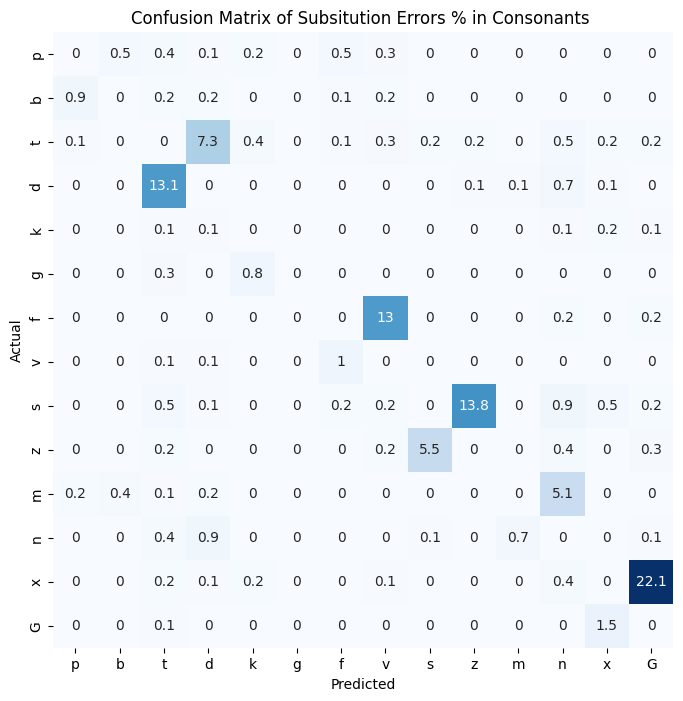

In [ ]:
# Plot the confusion matrix using Seaborn
plt.figure(figsize=(8, 8))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False,
            xticklabels=consonants_back,yticklabels=consonants_back,)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of Subsitution Errors % in Consonants ')
plt.show()

In [ ]:
vowels = ['a','ac','o','oc','i','ic','1','e','ec','y','yc','yc+','ac+']
vowelsback = ['a', 'A', 'o', 'O', 'i','I', '@', 'e', 'E', 'y','Y','Y+','A+']

SELECTED = S_DF.loc[S_DF['ref'].isin(vowels)]
SELECTED = SELECTED.loc[SELECTED['hyp'].isin(vowels)]
SELECTED

,eval_label,ref,hyp
0,S,1,a
8,S,o,ac+
9,S,e,ic
20,S,ec,1
26,S,a,1
...,...,...,...
45504,C,oc,oc
45507,C,1,1
45509,C,oc,oc
45512,C,1,1


In [ ]:
conf_matrix = confusion_matrix(SELECTED.ref,
                               SELECTED.hyp,labels=vowels, normalize ='all')

conf_matrix = np.around(conf_matrix, decimals = 2)

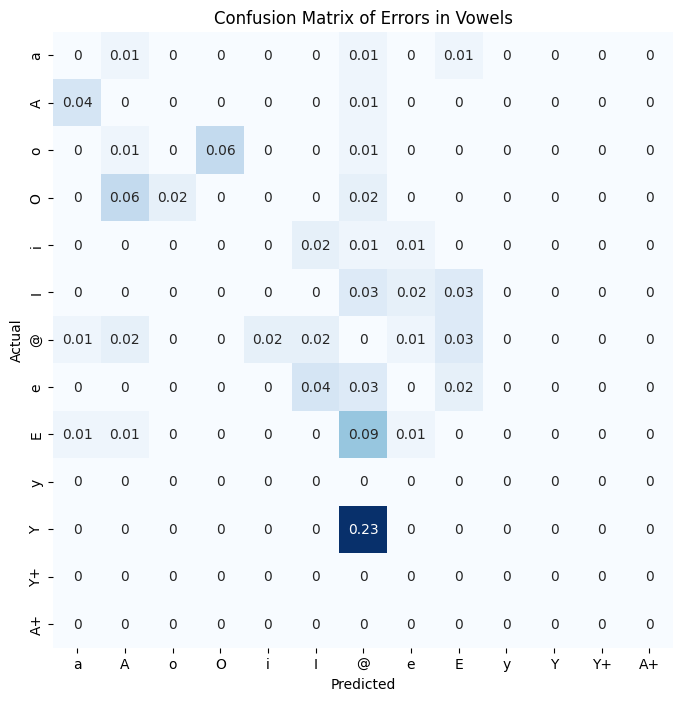

In [ ]:
# Plot the confusion matrix using Seaborn
plt.figure(figsize=(8, 8))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False,
            xticklabels=vowelsback,yticklabels=vowelsback,)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of Errors in Vowels')
plt.show()

In [ ]:
conf_matrix = confusion_matrix(SELECTED.ref,
                               SELECTED.hyp,labels=vowels)

##wer

In [ ]:
phone = []
i=0
for speaker in child_data.index:
  #try:
    anno_addr = os.path.join(Reformat_path+speaker+".pkl")
    anno_temp = pd.read_pickle(anno_addr)

    speaker_id=anno_temp.tier_name[0]
    phone_sid = speaker_id+'_SEG'

    phoneme_transcription = anno_temp.loc[anno_temp['tier_name'] == phone_sid].text.values
    #if "#" in phoneme_transcription: print(i," : ",list(phoneme_transcription))
    phone.append(' '.join(phoneme_transcription))
    i+=1
  #except:
    #print("Errors in reading "+anno_addr)

#Example Usage SCTK

In [ ]:
!version=v0.3.0 && wget -q -O sctk https://github.com/shahruk10/go-sctk/releases/download/${version}/sctk && chmod +x ./sctk


In [ ]:
# Getting Go SCTK CLI tool and giving it executable permissions.
!version=v0.3.0 && wget -q -O sctk https://github.com/shahruk10/go-sctk/releases/download/${version}/sctk && chmod +x ./sctk

# Printing usage docs.
#!./sctk score --help

In [ ]:
def replace_at_with_1(input_string):
    return input_string.replace("@", "1")

In [ ]:
with open('/content/report/hyp1.trn.pra.json', 'r') as file:
    data = json.load(file)

In [ ]:
data

In [ ]:
indices = [index for index, word in enumerate(data['speakers']['spk01']['(spk01-utt01)']['words']) if word['eval_label'] != 'C']

In [ ]:
indices

In [ ]:
import pandas as pd
d = {'utterance_id': ['spk01-utt01'], 'transcript': [replace_at_with_1(AVI_dict['9'])]}
df = pd.DataFrame(data=d)
df.to_csv('ref.csv', index=False)

In [ ]:
import pandas as pd
d = {'utterance_id': ['spk01-utt01'], 'transcript':  [replace_at_with_1(ipa2sampa(data['fn000096']['text'][:-50]))]}
df = pd.DataFrame(data=d)
df.to_csv('hyp.csv', index=False)

In [ ]:
!./sctk score \
  --ignore-first=true \
  --delimiter="," \
  --col-id=0 \
  --col-trn=1 \
  --cer=false \
  --out=./report \
  --ref=./ref.csv \
  --hyp=./hyp.csv

# Check Errors on each reading level

In [ ]:
Error_audio

,tier_name,tier_type,start_time,end_time,text
6519,Reading errors,IntervalTier,34.3415,34.6416,g/23
6520,Reading errors,IntervalTier,117.7702,118.6420,14
6521,Reading errors,IntervalTier,118.6420,119.7810,29


In [ ]:
 Phone_audio=trim_df_by_time(Phone_audio, start_prompt_time, end_prompt_time)
 Phone_audio

NameError: name 'start_prompt_time' is not defined

In [ ]:
child_level = child_data.loc[child_data['Niveau']=='AVI-1']
child_level

NameError: name 'child_data' is not defined

In [ ]:
short_audio = '/content/drive/MyDrive/REDC/Testaudio/fn000049_1_003.wav'
ground = 'j@run Is Ons@ byrmAn'
pred = ['j aː r n u m ɪ s ɔ n z ə b øː r ə n m aː m'] #from wav2vec2-xlsr

##Detection Test Single Audio

## Detection Entire Dataset

## Eval: Detection

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import numpy as np

def flatten_multioutput(predictions, ground_truth):
    # Flatten predictions and ground truth
    flat_predicted = np.array([label[0] for label in predictions])
    flat_ground_truth = np.array([label[0] for label in ground_truth])
    return flat_predicted, flat_ground_truth

def evaluate_model(predicted, ground_truth):
    # Compute accuracy
    accuracy = accuracy_score(ground_truth, predicted)

    # Compute confusion matrix
    confusion_mat = confusion_matrix(ground_truth, predicted)

    # Compute precision
    precision = precision_score(ground_truth, predicted, average='weighted')

    # Compute recall
    recall = recall_score(ground_truth, predicted, average='weighted')

    # Compute F1 score
    f1 = f1_score(ground_truth, predicted, average='weighted')

    return accuracy, precision, recall, f1, confusion_mat



In [ ]:


from collections import defaultdict

def calculate_metrics_with_occurrences(ground_truth, predictions):
    # Count occurrences of detections in ground truth and predictions
    ground_truth_counter = defaultdict(int)
    predictions_counter = defaultdict(int)
    for detection in ground_truth:
        ground_truth_counter[detection] += 1
    for detection in predictions:
        predictions_counter[detection] += 1

    # Calculate true positives, false positives, and false negatives
    TP = sum(min(ground_truth_counter[detection], predictions_counter[detection]) for detection in predictions)
    FP = sum(predictions_counter[detection] - min(ground_truth_counter[detection], predictions_counter[detection]) for detection in predictions)
    FN = sum(ground_truth_counter[detection] - min(ground_truth_counter[detection], predictions_counter[detection]) for detection in ground_truth)

    # Adjust FN based on extra occurrences in predictions
    FN += sum(occurrences - min(occurrences, ground_truth_counter[detection]) for detection, occurrences in ground_truth_counter.items() if detection not in predictions_counter)

    # Calculate precision and recall
    #precision = TP / (TP + FP) if TP + FP != 0 else 0
    #recall = TP / (TP + FN) if TP + FN != 0 else 0

    # Create confusion matrix
    #confusion_matrix = [[TP, FP], [FN, 0]]

    return TP, FP, FN

# Example ground truth and predictions
ground_truth = [(0,1),(0,3),(0,3)]
predictions = [(0,1),(0,3),(0,9),(1,8),(0,3),(0,3)]

# Calculate precision, recall, and confusion matrix
#precision, recall, confusion_matrix = calculate_metrics_with_occurrences(ground_truth, predictions)

#print("Precision:", precision)
#print("Recall:", recall)
#print("Confusion Matrix:")
#for row in confusion_matrix:
#    print(row)

# Pipe error detection AVI-9

In [ ]:
Map_errors = {'sub' : [1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 16, 17,'e','f','g','m'],
'del' : [0, 18, 20, 21, 22, 23, 24, 25, 26, 28, 29],
'ins' : [30, 32, 33, 34, 35, 37, 38,'k','l']}

In [ ]:
Map_errors['sub'] = [str(x) for x in Map_errors['sub']]
Map_errors['del'] = [str(x) for x in Map_errors['del']]
Map_errors['ins'] = [str(x) for x in Map_errors['ins']]

In [ ]:
##SCTK has specical processing with @

def replace_at_with_1(input_string):
    return input_string.replace("@", "3")

- 遍历数组对，得到prompt index，phone index， error type， 如果是insertion，得到insert前一个phone末端prompt index

- 如果phone index对应的start time，endtime在某个错误内，保留，否则丢掉，检查是否正确

- 遍历数组对，得到predit prompt index， error type，对比，confusion matrix

In [ ]:
report_alignment = get_report_alignemnt('speaker','/content/report/hyp1.trn.pra.json')

In [ ]:
speaker = 'fn000096'

In [ ]:
'''
rule:
if given error location: error type in alignment does not match error in sanne annotation
use error type in alignment and make a record

if reread happens, always assign it to insert errors
do not consider sub/del annotation anymore

not all reread are recorded
'''

def get_error_time_pairs(speaker):
  error_time_pairs = {}
  #error_time_pairs[error_type] = (start_time, end_time)
  Error_audio, Phone_audio, Re_Error_audio = get_error_phone_inprompt(speaker)

  ins_errors=[]
  sub_errors=[]
  del_errors=[]

  #first do reread, cause most of the time it overlaps with other errors
  #reread errors have annotation ag and af, should be insert errors
  re_read_errors = []
  ag = Re_Error_audio.loc[Re_Error_audio['text']=='ag']
  af = Re_Error_audio.loc[Re_Error_audio['text']=='af']

  for i, j in zip(ag.start_time.values, ag.end_time.values):
    re_read_errors.append((i,j))
  for i, j in zip(af.start_time.values, af.end_time.values):
    re_read_errors.append((i,j))


  for i in range(0,len(Error_audio.text)):
    detail = Error_audio.iloc[i]
    pair = (detail.start_time, detail.end_time)
    error_type = detail.text.split("/")
    error_type = error_type[-1] #if multiple types, use last error type
    #print(error_type)
    #this condition means not to include error pair in reread errors
    if pair not in re_read_errors:
      if error_type in Map_errors['ins']:
        #do error type match check here from align_ground to sanne_ground
        #if not match: print
        ins_errors.append(pair)
        #print(pair)
      elif error_type in Map_errors['sub']:
        sub_errors.append(pair)
        #print(pair)
      elif error_type in Map_errors['del']:
        del_errors.append(pair)
        #print(pair)

  ins_errors.extend(re_read_errors)

  error_time_pairs['ins'] = ins_errors
  error_time_pairs['sub'] = sub_errors
  error_time_pairs['del'] = del_errors


  return error_time_pairs

In [ ]:
import itertools

def flatten(list_item):
 return list(itertools.chain.from_iterable(list_item))

In [ ]:
def is_within_ranges(new_range, ranges_list):
    for r in ranges_list:
        if r[0] <= new_range[0] <= r[1] and r[0] <= new_range[1] <= r[1]:
            return True
    return False

In [ ]:
ranges_list = [(0, 5), (7, 9), (11, 14)]

# New range tuple to check
new_range = (3, 8)

# Check if the new range tuple is within the ranges list
result = is_within_ranges(new_range, ranges_list)
print(result)  # Output: True

False


In [ ]:
#phoneme true index = error data index - numberof(deletion index) before

def get_tphone_eindex(align_eindex,error_dictionary):
  phone={}
  for error_index in align_eindex:
    phone[error_index]=error_index-len([j for j in error_dictionary['del'] if j<error_index ])
  return phone


#prompt true index = error data index - numberof(insertion index) before

def get_tprompt_eindex(align_eindex,error_dictionary):
  prompt={}
  for error_index in align_eindex:
    prompt[error_index]=error_index-len([j for j in error_dictionary['ins'] if j<error_index ])
  return prompt

In [ ]:
#if start_time, end_time of phoneme true index is outside the time pair of
#sanne error annotation, delete it

def get_annotated_prompt_eindex(tphone_eindex,tprompt_eindex, Phone_audio,error_time_pairs):

  for error_index,errorphone_index in tphone_eindex.items():
    #print(Phone_audio.iloc[errorphone_index])
    start_time = Phone_audio.iloc[errorphone_index].start_time
    end_time = Phone_audio.iloc[errorphone_index].end_time

    new_range = (start_time,end_time)
    #print(new_range)
    if is_within_ranges(new_range, flatten(error_time_pairs.values())) == False:
      del tprompt_eindex[error_index]

  return tprompt_eindex

In [ ]:
'''
input: speaker, alignment
output: error ground for a speaker
        should be location at prompt and error type
        now prompt_error[error type] = [list of locations on prompt text]

example: fn000096, alignment in report
example output should be:
        1 deletion error
        1/more insertion errors
        but I decide to record all insertion errors in alignment error
        this could make some mistakes for insertion
'''

def extract_error_ground_Sanne(speaker, report_alignment):
  #create diction，read data
  Error_audio, Phone_audio, Re_Error_audio = get_error_phone_inprompt(speaker)
  #pd.DataFrame(report_alignment['speakers']['spk01']['(spk01-utt01)']['words'])
  utter_id='(spk'+speaker+'-utt01)'
  speaker_id='spk'+speaker
  speaker_report_alignment = report_alignment['speakers'][speaker_id][utter_id]['words']

  #read error data index detail
  error_dictionary = {}
  error_dictionary['ins'] = [index for index, word in enumerate(speaker_report_alignment) if word['eval_label'] == 'I']
  error_dictionary['del'] = [index for index, word in enumerate(speaker_report_alignment) if word['eval_label'] == 'D']
  error_dictionary['sub'] = [index for index, word in enumerate(speaker_report_alignment) if word['eval_label'] == 'S']

  #read error data index total
  align_eindex = [index for index, word in enumerate(speaker_report_alignment) if word['eval_label'] != 'C']

  #create phoneme index mapping
  #phoneme true index = error data index - numberof(deletion index) before
  #if start_time, end_time of phoneme true index is outside the time pair of sanne error annotation, delete it
  tphone_eindex = get_tphone_eindex(align_eindex,error_dictionary)
  tprompt_eindex = get_tprompt_eindex(align_eindex,error_dictionary)
  error_time_pairs = get_error_time_pairs(speaker)
  annotated_prompt_eindex = get_annotated_prompt_eindex(tphone_eindex,tprompt_eindex, Phone_audio,error_time_pairs)
  tprompt_ins_index = get_tprompt_eindex(error_dictionary['ins'],error_dictionary)

  annotated_prompt_eindex.update(tprompt_ins_index)
  #prompt_error ground
  prompt_error=[]

  for error_index in annotated_prompt_eindex.keys():
    detail = speaker_report_alignment[error_index]
    detail.update({'index':annotated_prompt_eindex[error_index]})
    prompt_error.append(detail)

  #prompt_error['ins'] = [annotated_prompt_eindex[error_index] for error_index in annotated_prompt_eindex.keys() if error_index in error_dictionary['ins'] ]
  #prompt_error['del'] = [annotated_prompt_eindex[error_index] for error_index in annotated_prompt_eindex.keys() if error_index in error_dictionary['del']]
  #prompt_error['sub'] = [annotated_prompt_eindex[error_index] for error_index in annotated_prompt_eindex.keys() if error_index in error_dictionary['sub']]

  return prompt_error


In [ ]:
[word for index, word in enumerate(speaker_report_alignment) if word['eval_label'] != 'C']

[{'eval_label': 'I', 'ref': '', 'hyp': 'spela', 'index': 30},
 {'eval_label': 'S', 'ref': 'spelen', 'hyp': 'spellen', 'index': 31},
 {'eval_label': 'D', 'ref': 'dat', 'hyp': ''},
 {'eval_label': 'D', 'ref': 'een', 'hyp': ''},
 {'eval_label': 'D', 'ref': 'en', 'hyp': ''},
 {'eval_label': 'I', 'ref': '', 'hyp': 'een', 'index': 84},
 {'eval_label': 'I', 'ref': '', 'hyp': 'aa', 'index': 96},
 {'eval_label': 'S', 'ref': 'hij', 'hyp': 'hijsu', 'index': 156},
 {'eval_label': 'D', 'ref': 'ze', 'hyp': '', 'index': 158}]

In [ ]:
#from src import phonecode_tables
import re,sys
#import phonecode_tables

CODES=set(('ipa','arpabet','xsampa','sampa','disc','callhome'))
LANGUAGES=set(('eng','deu','nld','arz','cmn','spa','yue','lao','vie'))

#vowels = phonecode_tables._ipa_vowels
#consonants = phonecode_tables._ipa_consonants

#####################################################################
def translate_string(s, d):
    '''(tl,ttf)=translate_string(s,d):
    Translate the string, s, using symbols from dict, d, as:
    1. Min # untranslatable symbols, then 2. Min # symbols.
    tl = list of translated or untranslated symbols.
    ttf[n] = True if tl[n] was translated, else ttf[n]=False.
'''
    N = len(s)
    symcost = 1    # path cost per translated symbol
    oovcost = 10   # path cost per untranslatable symbol
    maxsym = max(len(k) for k in d.keys())  # max input symbol length
    # (pathcost to s[(n-m):n], n-m, translation[s[(n-m):m]], True/False)
    lattice = [ (0,0,'',True) ]
    for n in range(1,N+1):

        # Initialize on the assumption that s[n-1] is untranslatable
        lattice.append((oovcost+lattice[n-1][0],n-1,s[(n-1):n],False))
        # Search for translatable sequences s[(n-m):n], and keep the best
        for m in range(1,min(n+1,maxsym+1)):
            if s[(n-m):n] in d and symcost+lattice[n-m][0] < lattice[n][0]:
                lattice[n] = (symcost+lattice[n-m][0],n-m,d[s[(n-m):n]],True)


    # Back-trace
    tl = []
    translated = []
    n = N
    while n > 0:
        tl.append(lattice[n][2])
        translated.append(lattice[n][3])
        n = lattice[n][1]
    return((tl[::-1], translated[::-1]))

def attach_tones_to_vowels(il, tones, vowels, searchstep, catdir):
    '''Return a copy of il, with each tone attached to nearest vowel if any.
    searchstep=1 means search for next vowel, searchstep=-1 means prev vowel.
    catdir>=0 means concatenate after vowel, catdir<0 means cat before vowel.
    Tones are not combined, except those also included in the vowels set.
    '''
    ol = il.copy()
    v = 0 if searchstep>0 else len(ol)-1
    t = -1
    while 0<=v and v<len(ol):
        if (ol[v] in vowels or (len(ol[v])>1 and ol[v][0] in vowels)) and t>=0:
            ol[v]= ol[v]+ol[t] if catdir>=0 else ol[t]+ol[v]
            ol = ol[0:t] + ol[(t+1):]  # Remove the tone
            t = -1 # Done with that tone
        if v<len(ol) and ol[v] in tones:
            t = v
        v += searchstep
    return(ol)

def sampa2ipa(x,language):
    '''Return the IPA equivalent of SAMPA phone x.'''
    (tl,ttf) = translate_string(x, phonecode_tables._sampa2ipa)
    return(''.join(tl))


_ipa2sampa = {
    k:re.sub(r'◌','',v) for (k,v) in {
"ɪ":"I",
"ɛ":"E",
"æ":"E",
"ɑ":"A",
"ɑ̃":"A",
"ɐ":"A",
"ɔ":"O",
"ʏ":"Y",
"ə":"@",
"ɵ":"@",
"ɨ":"@",
"œ'":"@",
"œ":"@",
"ɚ":"@",
"iː":"i",
"y":"y",
"yː":"y",
"uː":"u",
"oʊ":"ou",
"ʊ":"u",
"yʊ":"yu",
"aː":"a",
"aɪ":"E+",
"au":"au",
"eː":"e",
"øː":"2",
"ø":"2",
"oː":"o",
"oɪ":"oI",
"ɛɪ":"E+",
"œy":"Y+",
"ʌu":"A+",
"ʌʊ":"A+",
"ɛː":"E:",
"œː":"Y:",
"ɔː":"O:",
"#":"",
"ˈ":"!",
"p":"p",
"b":"b",
"b'":"b",
"t":"t",
"tʲ":"t",
"ɾ":"t",
"d":"d",
"ɟ":"d",
"k":"k",
"ɡ":"g",
"q":"q",
"ts":"ts",
"f":"f",
"v":"v",
"s":"s",
"ɕ":"s",
"z":"z",
"x":"x",
"ɣ":"G",
"ɦ":"h",
"ʒ":"Z",
"dʒ":"Z",
"ð":"Z",
"ʃ":"S",
"tʃ":"S",
"θ":"S",
"m":"m",
"n":"n",
"ŋ":"N",
"l":"l",
"r":"r",
"ʁ":"r",
"ɹ":"r",
"ʋ":"w",
"j":"j",
"ɲ":"J"

    }.items()
}


def ipa2sampa(x):
    '''Return the IPA equivalent of SAMPA phone x.'''
    (tl,ttf) = translate_string(x, _ipa2sampa)
    return(''.join(tl))

#ALL AVI-9

 - extract ground and predict error for each
 - ref, hyp, report for each model
 - compute detection error (location_type pair) performance
 - confusion s,i,d
 - details mistakes for each model[link text](https://)


##wav2vec2

In [ ]:


wav2vec_output="/content/drive/MyDrive/REDC/phone_w2v2/"

In [ ]:
import pandas as pd
#child-level-9

utterid=[]
story = replace_at_with_1(AVI_dict['9'])

for speaker in child_level.index:
  id = 'spk'+speaker+'-utt01'
  utterid.append(id)
#reference level-9
d = {'utterance_id': utterid, 'transcript': [story]*len(utterid)}
df = pd.DataFrame(data=d)
df.to_csv(wav2vec_output+'ref.csv', index=False)

In [ ]:
#phoneme error ground level-9
phoneme_transcription=[]
for speaker in child_data.index:
  Error_audio, Phone_audio, Re_Error_audio = get_error_phone_inprompt(speaker)
  phoneme_transcription.append(replace_at_with_1(" ".join(Phone_audio.text.values)))

d = {'utterance_id': utterid, 'transcript': phoneme_transcription}
df = pd.DataFrame(data=d)
df.to_csv(wav2vec_output+'hyp1.csv', index=False)

NameError: name 'replace_at_with_1' is not defined

In [ ]:
import json

file_path = '/content/drive/MyDrive/REDC/Transcription/new_transcription_trimed_wav2vec2-base-960h-phoneme-reco-dutch.json'
with open(file_path, 'r') as file:
    # Step 2: Read the content
    file_content = file.read()

    # Step 3: Convert to dictionary using json
    try:
        my_dict = json.loads(file_content)
        print("Dictionary loaded successfully:", len(my_dict))
    except json.JSONDecodeError as e:
        print("Error decoding JSON:", e)

In [ ]:
#wav2vec error prediction level-9
model_prediction=[]
for speaker in child_data.index:
  prediction = my_dict[speaker]['text']
  model_prediction.append(replace_at_with_1(ipa2sampa(prediction)))
d = {'utterance_id': utterid, 'transcript': model_prediction}
df = pd.DataFrame(data=d)
df.to_csv(wav2vec_output+'hyp2.csv', index=False)

NameError: name 'my_dict' is not defined

In [ ]:
!./sctk score \
  --ignore-first=true \
  --delimiter="," \
  --col-id=0 \
  --col-trn=1 \
  --cer=false \
  --out="/content/drive/MyDrive/REDC/phone_w2v2/ground_report" \
  --ref="/content/drive/MyDrive/REDC/phone_w2v2/ref.csv" \
  --hyp="/content/drive/MyDrive/REDC/phone_w2v2/hyp1.csv"

In [ ]:
!./sctk score \
  --ignore-first=true \
  --delimiter="," \
  --col-id=0 \
  --col-trn=1 \
  --cer=false \
  --out="/content/drive/MyDrive/REDC/phone_w2v2/pred_report" \
  --ref="/content/drive/MyDrive/REDC/phone_w2v2/ref.csv" \
  --hyp="/content/drive/MyDrive/REDC/phone_w2v2/hyp2.csv"

In [ ]:
!./sctk score \
  --ignore-first=true \
  --delimiter="," \
  --col-id=0 \
  --col-trn=1 \
  --cer=T \
  --out="/content/drive/MyDrive/REDC/phone_w2v2/per_report" \
  --ref="/content/drive/MyDrive/REDC/phone_w2v2/hyp1.csv" \
  --hyp="/content/drive/MyDrive/REDC/phone_w2v2/hyp2.csv"

In [ ]:
def metrics(error_type):
  ground_report_alignment =  get_report_alignemnt('/content/drive/MyDrive/REDC/phone_w2v2/ground_report/hyp1.trn.pra.json')
  pred_report_alignment =  get_report_alignemnt('/content/drive/MyDrive/REDC/phone_w2v2/pred_report/hyp1.trn.pra.json')
  tpt = fpt = fnt = lt = 0
  for speaker in child_level.index:
    tp, fp, fn, l = metrics_inter_error_types(error_type, speaker,ground_report_alignment,pred_report_alignment)
    tpt += tp
    fpt += fp
    fnt += fn
    lt += l

  precision = tpt / (tpt + fpt) if (tpt + fpt) > 0 else 0
  recall = tpt / (tpt + fnt) if (tpt + fnt) > 0 else 0
  accuracy = tpt / lt if lt > 0 else 0

  return precision,recall,accuracy

In [ ]:
precision,recall,accuracy = metrics("I")
print(precision,recall)

0.22941176470588234 0.5939086294416244


In [ ]:
precision,recall,accuracy = metrics("S")
print(precision,recall)

<ipython-input-252-b3c137fd6771>:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['start_time'] = df['start_time'].astype(float)


0.017275419545903257 0.660377358490566


In [ ]:
precision,recall,accuracy = metrics("D")
print(precision,recall)

<ipython-input-252-b3c137fd6771>:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['start_time'] = df['start_time'].astype(float)
<ipython-input-252-b3c137fd6771>:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['end_time'] = df['end_time'].astype(float)


0.027181688125894134 0.76


##wav2vec-xlsr

In [ ]:


xlsr_output="/content/drive/MyDrive/REDC/phone_xlsr/"

In [ ]:
import pandas as pd
#child-level-9

utterid=[]
story = replace_at_with_1(AVI_dict['9'])

for speaker in child_level.index:
  id = 'spk'+speaker+'-utt01'
  utterid.append(id)
#reference level-9
d = {'utterance_id': utterid, 'transcript': [story]*len(utterid)}
df = pd.DataFrame(data=d)
df.to_csv(xlsr_output+'ref.csv', index=False)

In [ ]:
#phoneme error ground level-9
phoneme_transcription=[]
for speaker in child_level.index:
  Error_audio, Phone_audio, Re_Error_audio = get_error_phone_inprompt(speaker)
  phoneme_transcription.append(replace_at_with_1(" ".join(Phone_audio.text.values)))

d = {'utterance_id': utterid, 'transcript': phoneme_transcription}
df = pd.DataFrame(data=d)
df.to_csv(xlsr_output+'hyp1.csv', index=False)

In [ ]:
import json

file_path = '/content/drive/MyDrive/REDC/Transcription/new_transcription_trimed_wav2vec2-xlsr-53-espeak-cv-ft.json'
with open(file_path, 'r') as file:
    # Step 2: Read the content
    file_content = file.read()

    # Step 3: Convert to dictionary using json
    try:
        my_dict = json.loads(file_content)
        print("Dictionary loaded successfully:", len(my_dict))
    except json.JSONDecodeError as e:
        print("Error decoding JSON:", e)

Dictionary loaded successfully: 71


In [ ]:
my_dict[speaker]

In [ ]:
#wav2vec error prediction level-9
model_prediction=[]
for speaker in child_level.index:
  prediction = my_dict[speaker]['text']
  model_prediction.append(replace_at_with_1(ipa2sampa(prediction)))
d = {'utterance_id': utterid, 'transcript': model_prediction}
df = pd.DataFrame(data=d)
df.to_csv(xlsr_output+'hyp2.csv', index=False)

In [ ]:
!./sctk score \
  --ignore-first=true \
  --delimiter="," \
  --col-id=0 \
  --col-trn=1 \
  --cer=false \
  --out="/content/drive/MyDrive/REDC/phone_xlsr/ground_report" \
  --ref="/content/drive/MyDrive/REDC/phone_xlsr/ref.csv" \
  --hyp="/content/drive/MyDrive/REDC/phone_xlsr/hyp1.csv"

In [ ]:
!./sctk score \
  --ignore-first=true \
  --delimiter="," \
  --col-id=0 \
  --col-trn=1 \
  --cer=false \
  --out="/content/drive/MyDrive/REDC/phone_xlsr/pred_report" \
  --ref="/content/drive/MyDrive/REDC/phone_xlsr/ref.csv" \
  --hyp="/content/drive/MyDrive/REDC/phone_xlsr/hyp2.csv"

In [ ]:
!./sctk score \
  --ignore-first=true \
  --delimiter="," \
  --col-id=0 \
  --col-trn=1 \
  --cer=T \
  --out="/content/drive/MyDrive/REDC/phone_xlsr/per_report" \
  --ref="/content/drive/MyDrive/REDC/phone_xlsr/hyp1.csv" \
  --hyp="/content/drive/MyDrive/REDC/phone_xlsr/hyp2.csv"

In [ ]:
ground_report_alignment =  get_report_alignemnt('/content/drive/MyDrive/REDC/phone_xlsr/ground_report/hyp1.trn.pra.json')
pred_report_alignment =  get_report_alignemnt('/content/drive/MyDrive/REDC/phone_xlsr/pred_report/hyp1.trn.pra.json')

In [ ]:
def metrics(error_type, child_data):
  ground_report_alignment =  get_report_alignemnt('/content/drive/MyDrive/REDC/phone_xlsr/ground_report/hyp1.trn.pra.json')
  pred_report_alignment =  get_report_alignemnt('/content/drive/MyDrive/REDC/phone_xlsr/pred_report/hyp1.trn.pra.json')
  tpt = fpt = fnt = lt = 0
  for speaker in child_data.index:
    tp, fp, fn, l = metrics_inter_error_types(error_type, speaker,ground_report_alignment,pred_report_alignment)
    tpt += tp
    fpt += fp
    fnt += fn
    lt += l

  precision = tpt / (tpt + fpt) if (tpt + fpt) > 0 else 0
  recall = tpt / (tpt + fnt) if (tpt + fnt) > 0 else 0
  accuracy = tpt / lt if lt > 0 else 0

  return precision,recall,accuracy

In [ ]:
precision,recall,accuracy = metrics("I")
print(precision,recall)

0.3551673944687045 0.6192893401015228


In [ ]:
precision,recall,accuracy = metrics("S")
print(precision,recall)

0.015476609215617306 0.8301886792452831


In [ ]:
precision,recall,accuracy = metrics("D")
print(precision,recall)

0.016795865633074936 0.52


In [ ]:
for speaker in child_level.index:
  #get pair
  #compute s,d,i,total accuracy
  #

# Get result from WORD-LEVEL models

In [ ]:
#get reference
#get jasmin word transcription
#get asr output
#get report

#now we compare

#can asr use for detect general reading errors in children speech
#can asr use for providing detail info of reading miscue, which is defined to improve children reading

#here we answer rq1: can asr use for detect reading errors in children speech

#loose/strict strategy
#location and type

  #normalize all text, generate alignment report
  #ground error: get ground prompt index for sub, ins, del errors compared to orthographic transcription
  #prediction error: get ground prompt index for sub, ins, del errors compared to ASR transcription
  #get error detection score
  #get performance analysis of false alarm and missed detection

  #get reading miscue detection (e,f,g,m,k,l,0)
  #计算semantic 距离？
  #计算ortho距离
  #是pseudo rod吗
  #是其他
  #insertion错误
  #insertion正确
  #get performance analysis of false alarm and missed detection

#optional: how well asr recognize children speech, ##(optional) how well asr evaluate reading speech, word accuracy in children speech, which is the teaching scoring strategy


#get result for each level

In [ ]:
Map_word_Sanne_errors = {'sub' : ['e','f','g','m'],
'del' : [0],
'ins' : ['k','l', 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 16, 17, 18, 20, 21, 22, 23, 24, 25, 26, 28, 29,30, 32, 33, 34, 35, 37, 38]}

Map_errors = {}
Map_errors['sub'] = [str(x) for x in Map_word_Sanne_errors['sub']]
Map_errors['del'] = [str(x) for x in Map_word_Sanne_errors['del']]
Map_errors['ins'] = [str(x) for x in Map_word_Sanne_errors['ins']]

## normalize all text, generate alignment report, wer, word reading accuracy

### get alignment function

In [ ]:
import pandas as pd
import os
import numpy as np
import json

Reformat_path = "/content/drive/MyDrive/REDC/Jasmin_Child_Reformat_SanneAnno/"
children_data_path = "/content/drive/MyDrive/REDC/JASMIN_textgrid/"
child_speaker_file = os.path.join(children_data_path+"sprekers_informatie.xlsx")
child_data = pd.read_excel(child_speaker_file, index_col=0, usecols = np.arange(0,11))

#long word can lead to index error in word_transcripiton
Long_word = {
    "thuis komt": "thuiskomt", "aan hebben": "aanhebben", "terug vindt": "terugvindt",
    "rond lopen": "rondlopen", "samen wonen": "samenwonen", "ten slotte" :"tenslotte",
    "terecht komt": "terechtkomt"
}


DUTCH_NORMALIZATION = {
    "okee": "ok", "oke": "ok", "okey": "ok", "OKEE": "ok", "OKE": "ok",
    "OKEY": "ok", "MIJN": "mijn", "mn": "mijn", "m'n": "mijn", "M'N": "mijn", "mjn": "mijn",
    "'t": "het", "'T": "het", "'n": "een", "Een": "een", "EEN": "een", "z'n": "zijn", "zn": "z'n",
    "'m":"hem",
    "d'r": "daar", "dr": "daar",
    "'s": "s", "zo'n": "zoon",
    "'k": "ik", "'K": "ik",
    "uh": "",  #remove disfluency
}

def normalize_Dutch_string(input_string):
    normalized_string = input_string
    for key, value in DUTCH_NORMALIZATION.items():
        normalized_string = normalized_string.replace(key, value)
    return normalized_string

def normalize_long_words(input_string):
    normalized_string = input_string
    for key, value in Long_word.items():
        normalized_string = normalized_string.replace(key, value)
    return normalized_string

def read_phone_file(filename):
    phone = []
    with open(filename, 'r') as file:
        for line in file:
            # Split each line into key and value
            phone.append(line.strip())

    return " ".join(phone)

def reverse(input_string):
    txt = input_string.split(" ") [::-1]
    return " ".join(txt)

def text_norm_all(s):
    # Convert to lowercase
    s = s.lower()

    # Replace tag_a words
    #s = s.replace("<tag_a>", "<unk>")  # Assuming <tag_a> is the tag to be replaced
    s = s.replace("*n", "")  # Remove *a
    s = s.replace("*a", "")  # Remove *a
    s = s.replace("*u", "")  # Remove *a
    s = s.replace("*s", "")  # Remove *a
    s = s.replace("*v", "")  # Remove *a
    s = s.replace("<unk>", "")  # Remove *a


    # Remove punctuation
    punctuation = ".?!,-"
    #punctuation = ',?!'
    for p in punctuation:
        s = s.replace(p, "")

    s = s.replace("’", "'")


#这样改统一prompt和word——transcription对于长单词的正确定义
    s = s.replace("é", "e")
    #s = s.replace("komt", "komt.")
    #s = s.replace("thuiskomt", "thuis komt")
    #s = s.replace("terechtkomt", "terecht komt")
    #s = s.replace("aanhebben", "aan hebben")
    #s = s.replace("terugvindt", "terug vindt")
    #s = s.replace("rondlopen", "rond lopen")
    s = s.replace("5", "vijf")
    s = s.replace("100", "honderd")
    s = s.replace("1", "een")
    s = s.replace("4", "vier")
    s = s.replace("6", "zes")

    # Replace ggg and xxx words
    #s = s.replace("ggg", "<unk>")
    #s = s.replace("xxx", "<unk>")

    s =  normalize_Dutch_string(s)
    s =  normalize_long_words(s)

    return s

In [ ]:
def get_storydict():
  storypath = "/content/drive/MyDrive/REDC/Word/"
  storydict={}
  for i in range(1,10):
    storydict[f'avi{i}'] = read_phone_file(os.path.join(storypath+f'AVI {i}_word.txt'))
    print(storydict[f'avi{i}'])
  return storydict

In [ ]:
!unzip "/content/drive/MyDrive/REDC/whisperx.zip"
def get_whisper():
  storypath = "/content/"
  storydict={}
  for speaker in child_data.index:
    filename = speaker+'.txt'
    storydict[speaker] = text_norm_all(read_phone_file(os.path.join(storypath+filename)))
  return storydict

In [ ]:
def get_storydict():
  storypath = "/content/drive/MyDrive/REDC/Word/"
  storydict={}
  for i in range(1,10):
    storydict[f'avi{i}'] = read_phone_file(os.path.join(storypath+f'AVI {i}_word.txt'))
    #print(storydict[f'avi{i}'])
  return storydict
def get_normed_ref_prompt(child_data,storydict):
  ref_normed_prompt = {}
  for speaker in child_data.index:
    i=child_data.loc[speaker]['Niveau'][-1]
    ref_normed_prompt[speaker] = text_norm_all(storydict[f'avi{i}'])

  return ref_normed_prompt

#get dataset transcription
reference = get_normed_ref_prompt(child_data,get_storydict())
#reference

In [ ]:
import os
i=0
df = []
for speaker in child_data.index:
  path = speaker + '.wav'
  text = reference[speaker]
  df.append({'id':speaker, 'path':path, 'sentences':text})


df = pd.DataFrame(df)
df.to_csv('train.csv', index=False)
df.to_csv('test.csv', index=False)

In [ ]:
reference['fn000092']

'de maan is net zo oud als de aarde dat betekent dat ze vijf miljard jaar oud is net als de aarde is zij ontstaan uit gas en stof daaruit zijn ook de zon en alle planeten ontstaan sommige geleerden denken dat de maan van de aarde is losgerukt eigenlijk weten we het niet zeker het is in elk geval wel zo dat de maan in de buurt van de aarde is ontstaan dat blijkt bijvoorbeeld uit bepaalde stoffen die ook op de aarde voorkomen wanneer je s avonds naar de maan kijkt lijkt het net of je een gezicht kunt zien dat komt door de donkere vlekken op de maan die noemen we kraters dat zijn plekken waar lang geleden door de ruimte zwevende brokken zijn ingeslagen op de maan is er geen lucht de ruimtevaarders die er rondlopen moeten dus ruimtepakken aanhebben daarin zit de lucht die ze nodig hebben om te ademen ook moet het pak hen beschermen tegen de zon die kan in de ruimte fel schijnen omdat er geen lucht en wolken zijn het kan tot meer dan honderd graden warm worden op de maan'

In [ ]:
Prompt_id = 'Prompt' #may contain errors(missing last letter) due to import errors of unknown encoding, use AVI dict instead
Word_id = '' #forced alignment

def get_story_prompt_range(Prompt_audio):
  start_time = Prompt_audio.iloc[0].start_time
  end_time = Prompt_audio.iloc[-1].end_time

  return start_time, end_time #string type

def trim_df_by_time(df, start_prompt_time, end_prompt_time):
  df['start_time'] = df['start_time'].astype(float)
  df['end_time'] = df['end_time'].astype(float)

  df=df.loc[(df['end_time'] > float(start_prompt_time))& (df['start_time'] < float(end_prompt_time))]
  return df

def get_word_inprompt(speaker):

  anno_addr = os.path.join(Reformat_path+speaker+".pkl")
  anno_temp = pd.read_pickle(anno_addr)

  speaker_id=anno_temp.tier_name[0]

  Prompt_audio = anno_temp.loc[anno_temp['tier_name'] == Prompt_id]
  Word_audio = anno_temp.loc[anno_temp['tier_name'] == speaker_id+Word_id]
  if (Prompt_audio.iloc[0].text[0:6]=='wil je'):
    print('Discard instruction prompt in speaker: ',speaker)
    Prompt_audio=Prompt_audio.drop(Prompt_audio.index[0])

  start_prompt_time, end_prompt_time = get_story_prompt_range(Prompt_audio)

  Word_audio = trim_df_by_time(Word_audio, start_prompt_time, end_prompt_time)

  return Prompt_audio, Word_audio


def get_normed_word_transcription(child_data):
  word_transcription={}
  for speaker in child_data.index:
    Prompt_audio, Word_audio = get_word_inprompt(speaker)
    word_transcription[speaker] = text_norm_all(" ".join(Word_audio.text.values))

  return word_transcription

word_transcription = get_normed_word_transcription(child_data)


<ipython-input-9-b0b3ef655b10>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['start_time'] = df['start_time'].astype(float)
<ipython-input-9-b0b3ef655b10>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['end_time'] = df['end_time'].astype(float)


Discard instruction prompt in speaker:  fn000051


<ipython-input-9-b0b3ef655b10>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['start_time'] = df['start_time'].astype(float)
<ipython-input-9-b0b3ef655b10>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['end_time'] = df['end_time'].astype(float)
<ipython-input-9-b0b3ef655b10>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas

Discard instruction prompt in speaker:  fn000066


<ipython-input-9-b0b3ef655b10>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['start_time'] = df['start_time'].astype(float)
<ipython-input-9-b0b3ef655b10>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['end_time'] = df['end_time'].astype(float)


...

<ipython-input-9-b0b3ef655b10>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['start_time'] = df['start_time'].astype(float)
<ipython-input-9-b0b3ef655b10>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['end_time'] = df['end_time'].astype(float)


Discard instruction prompt in speaker:  fn000070


<ipython-input-9-b0b3ef655b10>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['start_time'] = df['start_time'].astype(float)
<ipython-input-9-b0b3ef655b10>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['end_time'] = df['end_time'].astype(float)


Discard instruction prompt in speaker:  fn000073


<ipython-input-9-b0b3ef655b10>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['start_time'] = df['start_time'].astype(float)
<ipython-input-9-b0b3ef655b10>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['end_time'] = df['end_time'].astype(float)
<ipython-input-9-b0b3ef655b10>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas

In [ ]:
word_transcription['fn000094']

In [ ]:
def get_asr_output(filepath):

  with open(file_path, 'r') as file:
      # Step 2: Read the content
      file_content = file.read()

      # Step 3: Convert to dictionary using json
      try:
          my_dict = json.loads(file_content)
          print("Dictionary loaded successfully:", len(my_dict))
      except json.JSONDecodeError as e:
          print("Error decoding JSON:", e)


    #wav2vec error prediction level-9
  model_prediction={}
  for speaker in child_data.index:
    prediction = my_dict[speaker]['text']
    model_prediction[speaker] = text_norm_all(prediction)

  return model_prediction

In [ ]:
def get_files_alignment(output_path,reference,word_transcription,model_prediction):
  ref_path = output_path+'ref.csv'
  word_path = output_path+'hyp1.csv'
  pred_path = output_path+'hyp2.csv'
  utterid=[]
  for speaker in child_data.index:
    id = 'spk'+speaker+'-utt01'
    utterid.append(id)
  #reference level-9
  d = {'utterance_id': utterid, 'transcript': list(reference.values())}
  df = pd.DataFrame(data=d)
  df.to_csv(ref_path, index=False)

  d = {'utterance_id': utterid, 'transcript': list(word_transcription.values())}
  df = pd.DataFrame(data=d)
  df.to_csv(word_path, index=False)

  #model_prediction = get_asr_output(asr_output)
  d = {'utterance_id': utterid, 'transcript': list(model_prediction.values())}
  df = pd.DataFrame(data=d)
  df.to_csv(pred_path, index=False)

  return

In [ ]:
# Getting Go SCTK CLI tool and giving it executable permissions.
!version=v0.3.0 && wget -q -O sctk https://github.com/shahruk10/go-sctk/releases/download/${version}/sctk && chmod +x ./sctk

# Printing usage docs.
#!./sctk score --help

###normalized_long_word vs unomalized

In [ ]:
def text_norm_no_long(s):
    # Convert to lowercase
    s = s.lower()

    # Replace tag_a words
    #s = s.replace("<tag_a>", "<unk>")  # Assuming <tag_a> is the tag to be replaced
    s = s.replace("*n", "")  # Remove *a
    s = s.replace("*a", "")  # Remove *a
    s = s.replace("*u", "")  # Remove *a
    s = s.replace("*s", "")  # Remove *a
    s = s.replace("*v", "")  # Remove *a

    # Remove punctuation
    punctuation = ".?!,-"
    #punctuation = ',?!'
    for p in punctuation:
        s = s.replace(p, "")

    s = s.replace("’", "'")


#这样改统一prompt和word——transcription对于长单词的正确定义
    s = s.replace("é", "e")
    #s = s.replace("komt", "komt.")
    #s = s.replace("thuiskomt", "thuis komt")
    #s = s.replace("terechtkomt", "terecht komt")
    #s = s.replace("aanhebben", "aan hebben")
    #s = s.replace("terugvindt", "terug vindt")
    #s = s.replace("rondlopen", "rond lopen")
    s = s.replace("5", "vijf")

    # Replace ggg and xxx words
    #s = s.replace("ggg", "<unk>")
    #s = s.replace("xxx", "<unk>")

    s =  normalize_Dutch_string(s)

    return s

def get_normed_word_transcription_nolong(child_data):
  word_transcription={}
  for speaker in child_data.index:
    Prompt_audio, Word_audio = get_word_inprompt(speaker)
    word_transcription[speaker] = text_norm_no_long(" ".join(Word_audio.text.values))

  return word_transcription

#word_transcription_without_long = get_normed_word_transcription_nolong(child_data)

In [ ]:
normalized_output = "/content/drive/MyDrive/REDC/word_nomalized/"


get_files_alignment(normalized_output,reference,word_transcription_without_long,word_transcription_without_long)

In [ ]:
!./sctk score \
  --ignore-first=true \
  --delimiter="," \
  --col-id=0 \
  --col-trn=1 \
  --cer=false \
  --out="/content/drive/MyDrive/REDC/word_nomalized/ground_report" \
  --ref="/content/drive/MyDrive/REDC/word_nomalized/ref.csv" \
  --hyp="/content/drive/MyDrive/REDC/word_nomalized/hyp1.csv"

noisy_data

### word-ft-full

In [ ]:
import json
ft_full_output = "/content/drive/MyDrive/asr-augmentation/results/ft_full/"
file_path = '/content/drive/MyDrive/asr-augmentation/results/ft/transcription_trimed_i.json'

In [ ]:
import json
ft_full_output = "/content/results/ft_cfilter/"
!mkdir '/content/results/ft_cfilter'
file_path = '/content/test/transcription_Test_Jasmin_Audio_finetune-clean-filter.json'

In [ ]:
get_files_alignment(ft_full_output,reference,word_transcription,get_asr_output(file_path))

Dictionary loaded successfully: 71


In [ ]:
!./sctk score \
  --ignore-first=true \
  --delimiter="," \
  --col-id=0 \
  --col-trn=1 \
  --cer=false \
  --out="'/content/results/ft_cfilter/wer_report" \
  --ref="/content/results/ft_cfilter/hyp1.csv" \
  --hyp="/content/results/ft_cfilter/hyp2.csv"

In [ ]:
def get_files_bias_alignment(output_path,reference,word_transcription,model_prediction, bias):
  ref_path = output_path+'ref.csv'
  word_path = output_path+'hyp1.csv'
  pred_path = output_path+'hyp2.csv'
  utterid=[]
  for speaker in bias.index:
    id = 'spk'+speaker+'-utt01'
    utterid.append(id)
  #reference level-9
  d = {'utterance_id': utterid, 'transcript': list(reference.values())}
  df = pd.DataFrame(data=d)
  df.to_csv(ref_path, index=False)

  d = {'utterance_id': utterid, 'transcript': list(word_transcription.values())}
  df = pd.DataFrame(data=d)
  df.to_csv(word_path, index=False)

  #model_prediction = get_asr_output(asr_output)
  d = {'utterance_id': utterid, 'transcript': list(model_prediction.values())}
  df = pd.DataFrame(data=d)
  df.to_csv(pred_path, index=False)

  return

In [ ]:
import pandas as pd
bmdata = pd.read_csv('/content/drive/MyDrive/REDC/whisper_prompt/hyp2.csv')
dict_data = bmdata.to_dict()
dict_data['transcript'][0]

'jeroen is onze buurman hij houdt van grapjes en is altijd vrolijk wanneer we voetballen doet hij graag mee maar nu is hij verliefd nu heeft hij geen zin meer in spellen hij denkt alleen maar aan haar en loopt met zijn hoofd in de wolken mijn mama zegt dat normaal is als je pas verliefd bent en dat het een heel fijn gevoel is we stellen hem wel honderd vragen is ze knap kan ze goed voetballen zijn jullie al samen naar in de film geweest wanneer zien we haar een keer haar naam is anneleen vertelt hij ze is heel sportief maar ze kan niet zwemmen ze speelt wel goed basketbal en net als ik houdt ze van muziek jeroen vertelt dat ze niet kan kloppen lopen ze zit in een rolstoel haar twee benen zijn verland zo is ze geboren de bus nemen of ergens aanbellen is voor haar niet gemakkelijk dan verklapt hij dat snel zullen samenwonen en dat anneleen dan onze buurvrouw wordt dan zullen we haar vaak genoeg kunnen zien'

In [ ]:
file_path = '/content/drive/MyDrive/REDC/Transcription/new_transcription_trimed_wav2vec2-dutch-large-ft-cgn.json'
file_path = '/content/drive/MyDrive/asr-augmentation/results/ft/transcription_trimed_i_err.json'

In [ ]:
bias = child_data.loc[child_data['Age'] < 8]
bias_group_human ={}
bias_group_asr = {}
model_pre = get_asr_output(file_path)
for speaker in bias.index:
  #print(speaker)
  bias_group_human[speaker] =word_transcription[speaker]
  bias_group_asr[speaker] =model_pre[speaker]

ft_full_bias_output = "/content/drive/MyDrive/asr-augmentation/results/ft_full_bias/"
get_files_bias_alignment(ft_full_bias_output,bias_group_human,bias_group_human,bias_group_asr,bias)

Dictionary loaded successfully: 71


In [ ]:
len(bias)

4

In [ ]:
!./sctk score \
  --ignore-first=true \
  --delimiter="," \
  --col-id=0 \
  --col-trn=1 \
  --cer=false \
  --out="/content/drive/MyDrive/asr-augmentation/results/ft_full_bias/wer_report" \
  --ref="/content/drive/MyDrive/asr-augmentation/results/ft_full_bias/hyp1.csv" \
  --hyp="/content/drive/MyDrive/asr-augmentation/results/ft_full_bias/hyp2.csv"

In [ ]:
!./sctk score \
  --ignore-first=true \
  --delimiter="," \
  --col-id=0 \
  --col-trn=1 \
  --cer=false \
  --out="/content/drive/MyDrive/asr-augmentation/results/ft_full/wer_report" \
  --ref="/content/drive/MyDrive/asr-augmentation/results/ft_full/hyp1.csv" \
  --hyp="/content/drive/MyDrive/asr-augmentation/results/ft_full/hyp2.csv"

In [ ]:
!./sctk score \
  --ignore-first=true \
  --delimiter="," \
  --col-id=0 \
  --col-trn=1 \
  --cer=false \
  --out="/content/drive/MyDrive/asr-augmentation/results/ft_full/wer_report" \
  --ref="/content/drive/MyDrive/asr-augmentation/results/ft_full/hyp1.csv" \
  --hyp="/content/drive/MyDrive/asr-augmentation/results/ft_full/hyp2.csv"

In [ ]:
!./sctk score \
  --ignore-first=true \
  --delimiter="," \
  --col-id=0 \
  --col-trn=1 \
  --cer=false \
  --out="/content/drive/MyDrive/asr-augmentation/results/ft_full/ground_report" \
  --ref="/content/drive/MyDrive/asr-augmentation/results/ft_full/ref.csv" \
  --hyp="/content/drive/MyDrive/asr-augmentation/results/ft_full/hyp1.csv"

In [ ]:
!./sctk score \
  --ignore-first=true \
  --delimiter="," \
  --col-id=0 \
  --col-trn=1 \
  --cer=false \
  --out="/content/drive/MyDrive/asr-augmentation/results/ft_full/pred_report" \
  --ref="/content/drive/MyDrive/asr-augmentation/results/ft_full/ref.csv" \
  --hyp="/content/drive/MyDrive/asr-augmentation/results/ft_full/hyp2.csv"

### word-ft-err

In [ ]:
import json
#ft_ex1
ft_err_output = "/content/drive/MyDrive/asr-augmentation/results/ft_err/"
file_path = '/content/drive/MyDrive/asr-augmentation/results/ft/transcription_trimed_i_err.json'

In [ ]:
get_files_alignment(ft_err_output,reference,word_transcription,get_asr_output(file_path))

Dictionary loaded successfully: 71


In [ ]:
word_transcription

{'fn000049': 'jeroen is onze buurman hij houdt van grapjes en is altijd vrolijk wanneer we voetballen doet hij graag mee maar nu is hij verliefd nu heeft hij geen zin meer in spel spellen hij denkt alleen maar aan haar en loopt met zijn hoofd in de wolken mijn mama zegt dat normaal is als je pas verliefd bent en dat het heel fijn gevoel is we stellen hem wel honderd vragen is ze knap kan ze goed voetballen zijn jullie al samen naar een de film geweest wanneer zien we haar een keer haar naam is a anneleen vertelt hij ze is heel sportief maar ze kan niet zwemmen ze speelt wel goed basketbal en net als ik houdt ze van muziek jeroen vertelt dat ze niet kan lopen ze zit in een rolstoel haar twee benen zijn verlamd zo is ze geboren de bus nemen of ergens aanbellen is voor haar niet gemakkelijk dan verklapt hijs dat snel zullen samenwonen en dat anneleen dan onze buurvrouw wordt dan zullen we haar vaak genoeg kunnen zien',
 'fn000051': 'er is een cameraploeg op school vandaag m dat komt omdat

In [ ]:
!./sctk score \
  --ignore-first=true \
  --delimiter="," \
  --col-id=0 \
  --col-trn=1 \
  --cer=false \
  --out="/content/drive/MyDrive/asr-augmentation/results/ft_err/wer_report" \
  --ref="/content/drive/MyDrive/asr-augmentation/results/ft_err/hyp1.csv" \
  --hyp="/content/drive/MyDrive/asr-augmentation/results/ft_err/hyp2.csv"

### word-ft-ex1

In [ ]:
import json
#ft_ex1
ft_ex1_output = "/content/drive/MyDrive/asr-augmentation/results/ft_ex1/"
file_path = '/content/drive/MyDrive/asr-augmentation/results/ft/transcription_trimed_wav2vec2-ft-ex1.json'

In [ ]:
get_files_alignment(ft_ex1_output,reference,word_transcription,get_asr_output(file_path))

Dictionary loaded successfully: 71


In [ ]:
!./sctk score \
  --ignore-first=true \
  --delimiter="," \
  --col-id=0 \
  --col-trn=1 \
  --cer=false \
  --out="/content/drive/MyDrive/asr-augmentation/results/ft_ex1/ground_report" \
  --ref="/content/drive/MyDrive/asr-augmentation/results/ft_ex1/ref.csv" \
  --hyp="/content/drive/MyDrive/asr-augmentation/results/ft_ex1/hyp1.csv"

In [ ]:
!./sctk score \
  --ignore-first=true \
  --delimiter="," \
  --col-id=0 \
  --col-trn=1 \
  --cer=false \
  --out="/content/drive/MyDrive/asr-augmentation/results/ft_ex1/pred_report" \
  --ref="/content/drive/MyDrive/asr-augmentation/results/ft_ex1/ref.csv" \
  --hyp="/content/drive/MyDrive/asr-augmentation/results/ft_ex1/hyp2.csv"

In [ ]:
!./sctk score \
  --ignore-first=true \
  --delimiter="," \
  --col-id=0 \
  --col-trn=1 \
  --cer=false \
  --out="/content/drive/MyDrive/asr-augmentation/results/ft_ex1/wer_report" \
  --ref="/content/drive/MyDrive/asr-augmentation/results/ft_ex1/hyp1.csv" \
  --hyp="/content/drive/MyDrive/asr-augmentation/results/ft_ex1/hyp2.csv"

### word-w2v2

In [ ]:
w2v2_word_output = "/content/drive/MyDrive/REDC/word_w2v2/"
import json
file_path = '/content/drive/MyDrive/REDC/Transcription/new_transcription_trimed_wav2vec2-dutch-large-ft-cgn.json'
file_path = '/content/drive/MyDrive/REDC/transcription_Test_Jasmin_Audio_wav2vec2-dutch-large-ft-cgn.json'

In [ ]:
!mkdir /content/drive/MyDrive/REDC/word_ftw2v2/
w2v2_ftclean_output = "/content/drive/MyDrive/REDC/word_ftw2v2/"

In [ ]:
get_files_alignment(w2v2_word_output,reference,word_transcription,get_asr_output(file_path))

Dictionary loaded successfully: 71


In [ ]:
!./sctk score \
  --ignore-first=true \
  --delimiter="," \
  --col-id=0 \
  --col-trn=1 \
  --cer=false \
  --out="/content/drive/MyDrive/REDC/word_w2v2/ground_report" \
  --ref="/content/drive/MyDrive/REDC/word_w2v2/ref.csv" \
  --hyp="/content/drive/MyDrive/REDC/word_w2v2/hyp1.csv"

In [ ]:
!./sctk score \
  --ignore-first=true \
  --delimiter="," \
  --col-id=0 \
  --col-trn=1 \
  --cer=false \
  --out="/content/drive/MyDrive/REDC/word_w2v2/pred_report" \
  --ref="/content/drive/MyDrive/REDC/word_w2v2/ref.csv" \
  --hyp="/content/drive/MyDrive/REDC/word_w2v2/hyp2.csv"

In [ ]:
!./sctk score \
  --ignore-first=true \
  --delimiter="," \
  --col-id=0 \
  --col-trn=1 \
  --cer=false \
  --out="/content/drive/MyDrive/REDC/word_w2v2/wer_report" \
  --ref="/content/drive/MyDrive/REDC/word_w2v2/hyp1.csv" \
  --hyp="/content/drive/MyDrive/REDC/word_w2v2/hyp2.csv"

In [ ]:
file_path = '/content/drive/MyDrive/REDC/word_w2v2/transcription_Test_Jasmin_Audio_new_finetune_clean.json'
get_files_alignment(w2v2_ftclean_output,reference,word_transcription,get_asr_output(file_path))

Dictionary loaded successfully: 71


In [ ]:
!mkdir /content/drive/MyDrive/REDC/word_ftw2v2/pred_report
!mkdir /content/drive/MyDrive/REDC/word_ftw2v2/wer_report

mkdir: cannot create directory ‘/content/drive/MyDrive/REDC/w2v2_ftclean_output/pred_report’: No such file or directory
mkdir: cannot create directory ‘/content/drive/MyDrive/REDC/w2v2_ftclean_output/wer_report’: No such file or directory


In [ ]:
!./sctk score \
  --ignore-first=true \
  --delimiter="," \
  --col-id=0 \
  --col-trn=1 \
  --cer=false \
  --out="/content/drive/MyDrive/REDC/word_ftw2v2/pred_report" \
  --ref="/content/drive/MyDrive/REDC/word_ftw2v2/ref.csv" \
  --hyp="/content/drive/MyDrive/REDC/word_ftw2v2/hyp2.csv"

In [ ]:
!./sctk score \
  --ignore-first=true \
  --delimiter="," \
  --col-id=0 \
  --col-trn=1 \
  --cer=false \
  --out="/content/drive/MyDrive/REDC/word_ftw2v2/wer_report" \
  --ref="/content/drive/MyDrive/REDC/word_ftw2v2/hyp1.csv" \
  --hyp="/content/drive/MyDrive/REDC/word_ftw2v2/hyp2.csv"

### word-xlsr

In [ ]:
xlsr_word_output = "/content/drive/MyDrive/REDC/word_xlsr/"
file_path = '/content/drive/MyDrive/REDC/Transcription/new_transcription_trimed_wav2vec2-large-xlsr-53-dutch.json'


In [ ]:
get_files_alignment(xlsr_word_output,reference,word_transcription,get_asr_output(file_path))


Dictionary loaded successfully: 71


In [ ]:
!rm -rf /content/drive/MyDrive/REDC/word_xlsr/per_report

In [ ]:
!./sctk score \
  --ignore-first=true \
  --delimiter="," \
  --col-id=0 \
  --col-trn=1 \
  --cer=false \
  --out="/content/drive/MyDrive/REDC/word_xlsr/ground_report" \
  --ref="/content/drive/MyDrive/REDC/word_xlsr/ref.csv" \
  --hyp="/content/drive/MyDrive/REDC/word_xlsr/hyp1.csv"

In [ ]:
!./sctk score \
  --ignore-first=true \
  --delimiter="," \
  --col-id=0 \
  --col-trn=1 \
  --cer=false \
  --out="/content/drive/MyDrive/REDC/word_xlsr/pred_report" \
  --ref="/content/drive/MyDrive/REDC/word_xlsr/ref.csv" \
  --hyp="/content/drive/MyDrive/REDC/word_xlsr/hyp2.csv"

In [ ]:
!./sctk score \
  --ignore-first=true \
  --delimiter="," \
  --col-id=0 \
  --col-trn=1 \
  --cer=false \
  --out="/content/drive/MyDrive/REDC/word_xlsr/wer_report" \
  --ref="/content/drive/MyDrive/REDC/word_xlsr/hyp1.csv" \
  --hyp="/content/drive/MyDrive/REDC/word_xlsr/hyp2.csv"

### word_mms

In [ ]:
mms_word_output = "/content/drive/MyDrive/REDC/word_mms/"

In [ ]:
file_path = '/content/drive/MyDrive/REDC/Transcription/transcription_trimed_mms.json'
get_files_alignment(mms_word_output,reference,word_transcription,get_asr_output(file_path))


Dictionary loaded successfully: 71


In [ ]:
!./sctk score \
  --ignore-first=true \
  --delimiter="," \
  --col-id=0 \
  --col-trn=1 \
  --cer=false \
  --out="/content/drive/MyDrive/REDC/word_mms/ground_report" \
  --ref="/content/drive/MyDrive/REDC/word_mms/ref.csv" \
  --hyp="/content/drive/MyDrive/REDC/word_mms/hyp1.csv"

In [ ]:
!./sctk score \
  --ignore-first=true \
  --delimiter="," \
  --col-id=0 \
  --col-trn=1 \
  --cer=false \
  --out="/content/drive/MyDrive/REDC/word_mms/pred_report" \
  --ref="/content/drive/MyDrive/REDC/word_mms/ref.csv" \
  --hyp="/content/drive/MyDrive/REDC/word_mms/hyp2.csv"

In [ ]:
!./sctk score \
  --ignore-first=true \
  --delimiter="," \
  --col-id=0 \
  --col-trn=1 \
  --cer=false \
  --out="/content/drive/MyDrive/REDC/word_mms/wer_report" \
  --ref="/content/drive/MyDrive/REDC/word_mms/hyp1.csv" \
  --hyp="/content/drive/MyDrive/REDC/word_mms/hyp2.csv"

### word_whisper

In [ ]:
model_prediction = get_whisper()

In [ ]:
!rm -rf /content/drive/MyDrive/REDC/whisper/ground_report

In [ ]:
whisper_output = '/content/sample_data/'

In [ ]:
speaker_irlist = ["fn000051", "fn000064", "fn000062", "fn000552", "fn000558", "fn000561"]

In [ ]:
def get_werfiles_alignment(output_path,word_transcription,model_prediction):
  word_path = output_path+'hyp1.csv'
  pred_path = output_path+'hyp2.csv'
  utterid=[]
  word = []
  model = []
  for speaker in speaker_irlist:
    id = 'spk'+speaker+'-utt01'
    utterid.append(id)
    word.append(word_transcription[speaker])
    model.append(model_prediction[speaker])

  d = {'utterance_id': utterid, 'transcript': list(word)}
  df = pd.DataFrame(data=d)
  df.to_csv(word_path, index=False)

  #model_prediction = get_asr_output(asr_output)
  d = {'utterance_id': utterid, 'transcript': list(model)}
  df = pd.DataFrame(data=d)
  df.to_csv(pred_path, index=False)

  return

In [ ]:
get_werfiles_alignment(whisper_output,word_transcription,model_prediction)

In [ ]:
!./sctk score \
  --ignore-first=true \
  --delimiter="," \
  --col-id=0 \
  --col-trn=1 \
  --cer=false \
  --out="/content/sample_data/wer_report" \
  --ref="/content/sample_data/hyp1.csv" \
  --hyp="/content/sample_data/hyp2.csv"

In [ ]:
get_files_alignment(whisper_output,reference,word_transcription,model_prediction)

In [ ]:
word_transcription['fn000094']

'mijn opa heeft wel twintig duiven hij geeft ze allemaal een naam ze wonen in een hok in de tuin en ze krijgen elke dag granen zaden en peulvruchten te eten die hebben ze nodig om voldoende energie te hebben en om de temperatuur van hun lichaam op peil te kunnen houden opa vertelde me dat er veel soorten duiven bestaan een van hen is de postduif dat is een duif die een heel grote afstand in een keer kan afleggen en gemakkelijk de weg naar huis terugvindt en daar heeft die duif geen kompas of landkaart voor nodig hij weet de weg door naar de zon te kijken daarom werden ze in de tijd van de oude romeinen en de grieken gebruikt om berichten te versturen toen had men immers nog geen auto of vliegtuig om de post mee te vervoeren de dui de duiven daaroegen dan kleine berichtjes met zich mee in een kokrtje aan hun poot nu zorgt de postbode dat je brief in de juiste bus terechtkomt toch zijn veel mensen in nederland en belgië lid van een postduicheduivenvereniging we noemen ze duivenmelkers ma

In [ ]:
!./sctk score \
  --ignore-first=true \
  --delimiter="," \
  --col-id=0 \
  --col-trn=1 \
  --cer=false \
  --out="/content/drive/MyDrive/REDC/whisper/ground_report" \
  --ref="/content/drive/MyDrive/REDC/whisper/ref.csv" \
  --hyp="/content/drive/MyDrive/REDC/whisper/hyp1.csv"

In [ ]:
!./sctk score \
  --ignore-first=true \
  --delimiter="," \
  --col-id=0 \
  --col-trn=1 \
  --cer=false \
  --out="/content/drive/MyDrive/REDC/whisper/pred_report" \
  --ref="/content/drive/MyDrive/REDC/whisper/ref.csv" \
  --hyp="/content/drive/MyDrive/REDC/whisper/hyp2.csv"

In [ ]:
!./sctk score \
  --ignore-first=true \
  --delimiter="," \
  --col-id=0 \
  --col-trn=1 \
  --cer=false \
  --out="/content/drive/MyDrive/REDC/whisper/wer_report" \
  --ref="/content/drive/MyDrive/REDC/whisper/hyp1.csv" \
  --hyp="/content/drive/MyDrive/REDC/whisper/hyp2.csv"

In [ ]:
!./sctk score \
  --ignore-first=true \
  --delimiter="," \
  --col-id=0 \
  --col-trn=1 \
  --cer=false \
  --out="/content/drive/MyDrive/REDC/whisper_prompt/wer_report" \
  --ref="/content/drive/MyDrive/REDC/whisper/hyp1.csv" \
  --hyp="/content/drive/MyDrive/REDC/whisper_prompt/hyp1.csv"

In [ ]:
!./sctk score \
  --ignore-first=true \
  --delimiter="," \
  --col-id=0 \
  --col-trn=1 \
  --cer=false \
  --out="/content/drive/MyDrive/REDC/whisper_prompt/pred_report" \
  --ref="/content/drive/MyDrive/REDC/whisper/ref.csv" \
  --hyp="/content/drive/MyDrive/REDC/whisper_prompt/hyp2.csv"

In [ ]:
!./sctk score \
  --ignore-first=true \
  --delimiter="," \
  --col-id=0 \
  --col-trn=1 \
  --cer=false \
  --out="/content/drive/MyDrive/REDC/whisper_prompt/ground_report" \
  --ref="/content/drive/MyDrive/REDC/whisper/ref.csv" \
  --hyp="/content/drive/MyDrive/REDC/whisper/hyp1.csv"

In [ ]:
!mkdir "/content/drive/MyDrive/REDC/whisper_prompt/wer_100_report"

In [ ]:
!./sctk score \
  --ignore-first=true \
  --delimiter="," \
  --col-id=0 \
  --col-trn=1 \
  --cer=false \
  --out="/content/drive/MyDrive/REDC/whisper_prompt/wer_10_report" \
  --ref="/content/drive/MyDrive/REDC/whisper/hyp1.csv" \
  --hyp="/content/drive/MyDrive/REDC/whisper_prompt/hyp2_10errortext.csv"

In [ ]:
!./sctk score \
  --ignore-first=true \
  --delimiter="," \
  --col-id=0 \
  --col-trn=1 \
  --cer=false \
  --out="/content/drive/MyDrive/REDC/whisper_prompt/wer_errorori_report" \
  --ref="/content/drive/MyDrive/REDC/whisper/hyp1.csv" \
  --hyp="/content/drive/MyDrive/REDC/whisper/hyp2.csv"

In [ ]:
!mkdir /content/drive/MyDrive/REDC/whisper_prompt/pred_10_report
!./sctk score \
  --ignore-first=true \
  --delimiter="," \
  --col-id=0 \
  --col-trn=1 \
  --cer=false \
  --out="/content/drive/MyDrive/REDC/whisper_prompt/pred_10_report" \
  --ref="/content/drive/MyDrive/REDC/whisper/ref.csv" \
  --hyp="/content/drive/MyDrive/REDC/whisper_prompt/hyp2_10errortext.csv"

In [ ]:
!mkdir /content/drive/MyDrive/REDC/whisper_prompt/pred_100_report
!./sctk score \
  --ignore-first=true \
  --delimiter="," \
  --col-id=0 \
  --col-trn=1 \
  --cer=false \
  --out="/content/drive/MyDrive/REDC/whisper_prompt/pred_100_report" \
  --ref="/content/drive/MyDrive/REDC/whisper/ref.csv" \
  --hyp="/content/drive/MyDrive/REDC/whisper_prompt/hyp2_100errortext.csv"

In [ ]:
!mkdir /content/drive/MyDrive/REDC/whisper_prompt/pred_llm_report
!./sctk score \
  --ignore-first=true \
  --delimiter="," \
  --col-id=0 \
  --col-trn=1 \
  --cer=false \
  --out="/content/drive/MyDrive/REDC/whisper_prompt/pred_llm_report" \
  --ref="/content/drive/MyDrive/REDC/whisper/ref.csv" \
  --hyp="/content/drive/MyDrive/REDC/whisper_prompt/hyp2_llm.csv"

In [ ]:
!mkdir /content/drive/MyDrive/REDC/whisper_prompt/pred_llmalign_report
!./sctk score \
  --ignore-first=true \
  --delimiter="," \
  --col-id=0 \
  --col-trn=1 \
  --cer=false \
  --out="/content/drive/MyDrive/REDC/whisper_prompt/pred_llmalign_report" \
  --ref="/content/drive/MyDrive/REDC/whisper/ref.csv" \
  --hyp="/content/drive/MyDrive/REDC/whisper_prompt/hyp2_llm_align.csv"

In [ ]:
#!mkdir /content/drive/MyDrive/REDC/whisper_prompt/pred_llmalign_report
!./sctk score \
  --ignore-first=true \
  --delimiter="," \
  --col-id=0 \
  --col-trn=1 \
  --cer=false \
  --out="/content/drive/MyDrive/REDC/whisper_prompt/pred_report" \
  --ref="/content/drive/MyDrive/REDC/whisper/ref.csv" \
  --hyp="/content/drive/MyDrive/REDC/whisper_prompt/hyp2.csv"

## error detection

  #ground error: get ground prompt index for sub, ins, del errors compared to orthographic transcription
  #prediction error: get ground prompt index for sub, ins, del errors compared to ASR transcription
  #get error detection score

In [ ]:
'''
alignment example
a   b c d
a f s c d
  I S

alignment index is unique, and can correspond to several different ref index
should return dict[alignment index] = ref index
dict[1] = 1
dict[2] = 1
'''

# 原function会出错

def get_align_ref_index_dict(align_index,error_dictionary):
  align_ref_index_dict={}
  for report_index in align_index:
    ref_index = report_index-len([j for j in error_dictionary['ins'] if j<report_index ])
    align_ref_index_dict[report_index]=ref_index
  return align_ref_index_dict


In [ ]:
def get_report_alignemnt(report_path):
  with open(report_path, 'r') as file:
    report_alignment = json.load(file)
  return report_alignment


In [ ]:
def get_error_with_ref_index(speaker, report_alignment):

  utter_id='(spk'+speaker+'-utt01)'
  speaker_id='spk'+speaker
  speaker_report_alignment = report_alignment['speakers'][speaker_id][utter_id]['words']

  error_dictionary = {}
  error_dictionary['ins'] = [index for index, word in enumerate(speaker_report_alignment) if word['eval_label'] == 'I']
  error_dictionary['del'] = [index for index, word in enumerate(speaker_report_alignment) if word['eval_label'] == 'D']
  error_dictionary['sub'] = [index for index, word in enumerate(speaker_report_alignment) if word['eval_label'] == 'S']

  #read original index
  report_index = [index for index, word in enumerate(speaker_report_alignment)]
  #get word_index: original index pair
  align_ref_index_dict = get_align_ref_index_dict(report_index,error_dictionary)

  error_index_list = [index for index, word in enumerate(speaker_report_alignment) if word['eval_label'] != 'C']

  speaker_error_detail=[]

  for index in error_index_list:
    alignment_index=index

    #alignment_info_previous=speaker_report_alignment[alignment_index-1]
    alignment_info = speaker_report_alignment[alignment_index]
    alignment_info['hyp2'] = ''

    if alignment_info['eval_label'] == 'S' and alignment_index-1!=0:
        previous_info = speaker_report_alignment[alignment_index-1]
        if previous_info['eval_label'] == 'I':
            alignment_info['hyp2'] = previous_info['hyp']

    if alignment_info['eval_label'] == 'D'and alignment_index+1!=len(speaker_report_alignment):
        late_info = speaker_report_alignment[alignment_index+1]
        if late_info['eval_label'] == 'S':
          alignment_info['hyp2'] = late_info['hyp']

    alignment_info['ref_index'] = align_ref_index_dict[index]
    speaker_error_detail.append(alignment_info)
  #if alignment_info['eval_label']=='S' and alignment_info_previous['eval_label']!='C': print(alignment_info_previous)
    #print(alignment_info)

  return speaker_error_detail

In [ ]:
#sanity check
speaker = 'fn000558'
test_alignment = {'speakers': {'spkfn000558': {'(spkfn000558-utt01)':{'words':[
    {'eval_label': 'C', 'ref':'a', 'hyp':'a'},
    {'eval_label': 'I', 'ref':' ', 'hyp':'f'},
    {'eval_label': 'S', 'ref':'b', 'hyp':'s'},
    {'eval_label': 'C', 'ref':'c', 'hyp':'c'},
    {'eval_label': 'C', 'ref':'d', 'hyp':'d'}
]}}}}


In [ ]:
#sanity check
get_error_with_ref_index(speaker, test_alignment)

NameError: name 'speaker' is not defined

In [ ]:
ground_report_alignment =  get_report_alignemnt('/content/drive/MyDrive/REDC/word_w2v2/ground_report/hyp1.trn.pra.json')
pred_report_alignment =  get_report_alignemnt('/content/drive/MyDrive/REDC/word_w2v2/pred_report/hyp1.trn.pra.json')

In [ ]:
def loose_metric_speaker(speaker, ground_report_alignment, pred_report_alignment, error_type = 'all'):

  ground_error_info = get_error_with_ref_index(speaker, ground_report_alignment)
  predict_error_info = get_error_with_ref_index(speaker, pred_report_alignment)

  if error_type != 'all':
    ground_error_selected = [item for item in ground_error_info if item['eval_label'] == error_type]
    predict_error_selected = [item for item in predict_error_info if item['eval_label'] == error_type]

    ground_error_info = ground_error_selected
    predict_error_info = predict_error_selected

  ground_error_list_loose = [(word['eval_label'], word['ref_index'])for word in ground_error_info]
  predict_error_list_loose = [(word['eval_label'], word['ref_index'])for word in predict_error_info]

  tp, fp, fn, tplist, fplist, fnlist = calculate_metrics(ground_error_list_loose, predict_error_list_loose)

  return tp, fp, fn, tplist, fplist, fnlist

In [ ]:
speaker = 'fn000534'

In [ ]:
loose_metric_speaker(speaker, ground_report_alignment, pred_report_alignment, error_type = 'all')

NameError: name 'speaker' is not defined

In [ ]:
strict_metric_speaker(speaker, ground_report_alignment, pred_report_alignment, error_type = 'all')

NameError: name 'strict_metric_speaker' is not defined

In [ ]:
def loose_results(ground_report_alignment, pred_report_alignment, error_type = 'all'):
  tpt, fpt, fnt = 0,0,0
  tptlist, fptlist, fntlist =[],[],[]
  for speaker in child_data.index:
    tp, fp, fn, tplist, fplist,fnlist  = loose_metric_speaker(speaker, ground_report_alignment, pred_report_alignment, error_type)
    tpt += tp
    fpt += fp
    fnt += fn
    tptlist.extend(tplist)
    fptlist.extend(fplist)
    fntlist.extend(fnlist)

  precision = tpt/(tpt+fpt) if tpt+fpt != 0 else 0
  recall = tpt/(tpt+fnt) if tpt+fnt != 0 else 0
  f1 = 2*(precision*recall)/(precision+recall) if precision+recall != 0 else 0
  return precision, recall, f1, tptlist, fptlist, fntlist

In [ ]:
def strict_results(ground_report_alignment, pred_report_alignment, error_type = 'all'):
  tpt, fpt, fnt = 0,0,0
  tptlist, fptlist, fntlist =[],[],[]
  for speaker in child_data.index:
    tp, fp, fn, tplist, fplist,fnlist  = strict_metric_speaker(speaker, ground_report_alignment, pred_report_alignment, error_type)
    tpt += tp
    fpt += fp
    fnt += fn
    tptlist.extend(tplist)
    fptlist.extend(fplist)
    fntlist.extend(fnlist)

  precision = tpt/(tpt+fpt)
  recall = tpt/(tpt+fnt)
  f1 = 2*(precision*recall)/(precision+recall)
  return precision, recall, f1, tptlist, fptlist, fntlist

In [ ]:
def strict_metric_speaker(speaker, ground_report_alignment, pred_report_alignment, error_type = 'all'):

  ground_error_info = get_error_with_ref_index(speaker, ground_report_alignment)
  predict_error_info = get_error_with_ref_index(speaker, pred_report_alignment)


  if error_type != 'all':
    ground_error_selected = [item for item in ground_error_info if item['eval_label'] == error_type]
    predict_error_selected = [item for item in predict_error_info if item['eval_label'] == error_type]

    ground_error_info = ground_error_selected
    predict_error_info = predict_error_selected

  ground_error_list_strict = [(word['eval_label'], word['ref_index'], word['hyp'])for word in ground_error_info]
  predict_error_list_strict = [(word['eval_label'], word['ref_index'], word['hyp'])for word in predict_error_info]

  tp, fp, fn, tplist, fplist, fnlist = calculate_metrics(ground_error_list_strict, predict_error_list_strict)

  return tp, fp, fn, tplist, fplist, fnlist


In [ ]:
def get_predict(speaker, pred_report_alignment, error_type = 'S'):

  predict_error_info = get_error_with_ref_index(speaker, pred_report_alignment)


  if error_type != 'all':
    predict_error_selected = [item for item in predict_error_info if item['eval_label'] == error_type]

    predict_error_info = predict_error_selected

  predict_error_list_strict = [(word['eval_label'], word['ref_index'], word['ref'],word['hyp'])for word in predict_error_info]


  return predict_error_list_strict

In [ ]:
#sanity check
speaker = 'fn000558'
ground_test_alignment = {'speakers': {'spkfn000558': {'(spkfn000558-utt01)':{'words':[
    {'eval_label': 'C', 'ref':'a', 'hyp':'a'},
    {'eval_label': 'C', 'ref':'a', 'hyp':'a'},
    {'eval_label': 'I', 'ref':' ', 'hyp':'f'},
    {'eval_label': 'S', 'ref':'b', 'hyp':'s'},
    {'eval_label': 'C', 'ref':'c', 'hyp':'c'},
    {'eval_label': 'D', 'ref':'w', 'hyp':' '},
    {'eval_label': 'C', 'ref':'d', 'hyp':'d'}
]}}}}
predict_test_alignment = {'speakers': {'spkfn000558': {'(spkfn000558-utt01)':{'words':[
    {'eval_label': 'S', 'ref':'a', 'hyp':'e'},
    {'eval_label': 'C', 'ref':'a', 'hyp':'a'},
    {'eval_label': 'I', 'ref':' ', 'hyp':'v'},
    {'eval_label': 'S', 'ref':'b', 'hyp':'s'},
    {'eval_label': 'C', 'ref':'c', 'hyp':'c'},
    {'eval_label': 'D', 'ref':'w', 'hyp':' '},
    {'eval_label': 'D', 'ref':'d', 'hyp':' '}
]}}}}


In [ ]:
strict_metric(speaker, ground_test_alignment, predict_test_alignment, error_type = 'all')

(2,
 3,
 1,
 [('S', 2, 's'), ('D', 4, ' ')],
 [('S', 0, 'e'), ('I', 2, 'v'), ('D', 5, ' ')],
 [('I', 2, 'f')])

In [ ]:
loose_metric_speaker(speaker, ground_test_alignment, predict_test_alignment, error_type = 'all')

(3, 2, 0, [('I', 2), ('S', 2), ('D', 4)], [('S', 0), ('D', 5)], [])

In [ ]:
loose_metric_speaker(speaker, ground_test_alignment, predict_test_alignment, error_type = 'D')

(1, 1, 0, [('D', 4)], [('D', 5)], [])

In [ ]:
def intersection(predict, ground):
    tp = [value for value in predict if value in ground]
    return tp

def set_difference(a, b):  #set A excluding set B
    sd = [value for value in a if value not in b]
    return sd

def calculate_metrics(error_ground_truth, error_predictions):
    # Convert ground truth and predictions into sets for efficient lookup
    #ground_truth_set = set(ground_truth)
    #predictions_set = set(predictions)

    # Compute true positives, false positives, and false negatives
    tplist = intersection(error_predictions, error_ground_truth)
    fplist = set_difference(error_predictions, tplist)
    fnlist = set_difference(error_ground_truth, tplist)
    tp = len(tplist)
    fp = len(error_predictions) -  tp
    fn = len(error_ground_truth) -  tp

    # Compute precision, recall, and accuracy
    #precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    #recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    #accuracy = tp / len(ground_truth_set) if len(ground_truth_set) > 0 else 0

    return tp, fp, fn, tplist, fplist, fnlist


###wav2vec error detection

In [ ]:
ground_report_alignment =  get_report_alignemnt('/content/drive/MyDrive/REDC/word_w2v2/ground_report/hyp1.trn.pra.json')
pred_report_alignment =  get_report_alignemnt('/content/drive/MyDrive/REDC/word_w2v2/pred_report/hyp1.trn.pra.json')

####loose

In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = loose_results(ground_report_alignment, pred_report_alignment, error_type = 'all')
print(precision, recall, f1)

0.43320610687022904 0.7998590556730092 0.5620203020549641


In [ ]:
len([i for i in fntlist if i[0]=='S'])

51

In [ ]:
[i for i in fntlist if i[0]=='S']

In [ ]:
[i for i in fntlist if i[0]=='I']

In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = loose_results(ground_report_alignment, pred_report_alignment, error_type = 'S')
print(precision, recall, f1)

0.1660261337432744 0.8089887640449438 0.2755102040816327


In [ ]:
0.18*0.8/(0.18+0.8)

0.14693877551020407

In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = loose_results(ground_report_alignment, pred_report_alignment, error_type = 'D')
print(precision, recall, f1)

0.47317073170731705 0.7886178861788617 0.5914634146341463


In [ ]:
len(tptlist + fptlist)

205

In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = loose_results(ground_report_alignment, pred_report_alignment, error_type = 'I')
print(precision, recall, f1)

0.7387791741472173 0.7677238805970149 0.7529734675205856


In [ ]:
len(tptlist + fptlist)

1114

####strict

In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = strict_results(ground_report_alignment, pred_report_alignment, error_type = 'all')
print(precision, recall, f1)

0.28435114503816794 0.5250176180408739 0.3689031938598663


In [ ]:
fntlist

[('I', 31, 'spel'),
 ('I', 85, 'een'),
 ('I', 97, 'a'),
 ('S', 156, 'hijs'),
 ('I', 7, 'm'),
 ('I', 15, 'poeze'),
 ('S', 15, 'poezie'),
 ('S', 17, 'elke'),
 ('I', 31, 'dat'),
 ('I', 31, 'win'),
 ('I', 39, 'mmm'),
 ('I', 59, 'op'),
 ('I', 59, 'een'),
 ('I', 70, 'de'),
 ('S', 78, 'poezie'),
 ('I', 90, 'slech'),
 ('I', 98, 'da'),
 ('I', 98, 'da'),
 ('I', 114, 'ca'),
 ('I', 117, 'h'),
 ('I', 117, 'ha'),
 ('I', 124, 'k'),
 ('I', 126, 'klap'),
 ('I', 137, 'ggg'),
 ('I', 159, 'zij'),
 ('S', 161, 'wij'),
 ('I', 12, 'm'),
 ('I', 97, 'an'),
 ('I', 117, 'houdt'),
 ('I', 117, 'f'),
 ('I', 139, 'ggg'),
 ('I', 70, 'zo'),
 ('I', 128, 'm'),
 ('S', 132, 'erg'),
 ('I', 0, 'vroe'),
 ('I', 6, 'i'),
 ('I', 22, 'dat'),
 ('I', 22, 'zijn'),
 ('I', 76, 'een'),
 ('I', 76, 'goede'),
 ('I', 76, 'jag'),
 ('I', 79, 'een'),
 ('I', 79, 'krij'),
 ('D', 82, ''),
 ('I', 96, 'gro'),
 ('I', 112, 'oor'),
 ('I', 169, 'z'),
 ('I', 169, 'ze'),
 ('I', 169, 'zorg'),
 ('I', 187, 'als'),
 ('I', 187, 'moeder'),
 ('I', 76, 'va'),
 

In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = strict_results(ground_report_alignment, pred_report_alignment, error_type = 'S')
print(precision, recall, f1)

0.09915449654112221 0.48314606741573035 0.1645408163265306


In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = strict_results(ground_report_alignment, pred_report_alignment, error_type = 'D')
print(precision, recall, f1)

0.47317073170731705 0.7886178861788617 0.5914634146341463


In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = strict_results(ground_report_alignment, pred_report_alignment, error_type = 'I')
print(precision, recall, f1)

0.4658886894075404 0.5043731778425656 0.48436770881941205


In [ ]:
###wav2vec error detection

###XLSR error detection

In [ ]:
ground_report_alignment =  get_report_alignemnt('/content/drive/MyDrive/REDC/word_xlsr/ground_report/hyp1.trn.pra.json')
pred_report_alignment =  get_report_alignemnt('/content/drive/MyDrive/REDC/word_xlsr/pred_report/hyp1.trn.pra.json')

In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = loose_results(ground_report_alignment, pred_report_alignment, error_type = 'all')
print(precision, recall, f1)

0.3274103323461665 0.7011980267794221 0.4463885150291611


In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = loose_results(ground_report_alignment, pred_report_alignment, error_type = 'S')
print(precision, recall, f1)

0.12937685459940654 0.8164794007490637 0.22336065573770494


In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = loose_results(ground_report_alignment, pred_report_alignment, error_type = 'D')
print(precision, recall, f1)

0.23684210526315788 0.7317073170731707 0.3578528827037773


In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = loose_results(ground_report_alignment, pred_report_alignment, error_type = 'I')
print(precision, recall, f1)

0.7053388090349076 0.6676384839650146 0.6859710434348477


####strict

In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = strict_results(ground_report_alignment, pred_report_alignment, error_type = 'all')
print(precision, recall, f1)

0.2194800921355709 0.4700493305144468 0.2992373261552265


In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = strict_results(ground_report_alignment, pred_report_alignment, error_type = 'S')
print(precision, recall, f1)

0.06468842729970327 0.40823970037453183 0.11168032786885247


In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = strict_results(ground_report_alignment, pred_report_alignment, error_type = 'D')
print(precision, recall, f1)

0.23684210526315788 0.7317073170731707 0.3578528827037773


In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = strict_results(ground_report_alignment, pred_report_alignment, error_type = 'I')
print(precision, recall, f1)

0.4804928131416838 0.45481049562682213 0.4672990514228657


###mms

In [ ]:
ground_report_alignment =  get_report_alignemnt('/content/drive/MyDrive/REDC/word_mms/ground_report/hyp1.trn.pra.json')
pred_report_alignment =  get_report_alignemnt('/content/drive/MyDrive/REDC/word_mms/pred_report/hyp1.trn.pra.json')

In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = loose_results(ground_report_alignment, pred_report_alignment, error_type = 'all')
print(precision, recall, f1)

0.17004504504504506 0.3192389006342495 0.221895664952241


In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = loose_results(ground_report_alignment, pred_report_alignment, error_type = 'S')
print(precision, recall, f1)

0.10918544194107452 0.7078651685393258 0.1891891891891892


In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = loose_results(ground_report_alignment, pred_report_alignment, error_type = 'D')
print(precision, recall, f1)

0.14241486068111456 0.7479674796747967 0.23927178153446035


In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = loose_results(ground_report_alignment, pred_report_alignment, error_type = 'I')
print(precision, recall, f1)

0.5993031358885017 0.16715257531584063 0.26139817629179335


####strict

In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = strict_results(ground_report_alignment, pred_report_alignment, error_type = 'all')
print(precision, recall, f1)

0.12124624624624625 0.22762508809020437 0.15821699730590252


In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = strict_results(ground_report_alignment, pred_report_alignment, error_type = 'S')
print(precision, recall, f1)

0.06008087810514154 0.3895131086142322 0.10410410410410409


In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = strict_results(ground_report_alignment, pred_report_alignment, error_type = 'D')
print(precision, recall, f1)

0.14241486068111456 0.7479674796747967 0.23927178153446035


In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = strict_results(ground_report_alignment, pred_report_alignment, error_type = 'I')
print(precision, recall, f1)

0.4425087108013937 0.12342079689018465 0.19300911854103342


###whisper prompt

In [ ]:
import json

In [ ]:
ground_report_alignment =  get_report_alignemnt('/content/drive/MyDrive/REDC/whisper_prompt/ground_report/hyp1.trn.pra.json')
pred_report_alignment =  get_report_alignemnt('/content/drive/MyDrive/REDC/whisper_prompt/pred_llmalign_report/hyp1.trn.pra.json')

In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = loose_results(ground_report_alignment, pred_report_alignment, error_type = 'all')
print(precision, recall, f1)

0.7604078164825828 0.7030636292223095 0.7306122448979591


In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = loose_results(ground_report_alignment, pred_report_alignment, error_type = 'I')
print(precision, recall, f1)

0.6857962697274032 0.8535714285714285 0.760540970564837


In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = loose_results(ground_report_alignment, pred_report_alignment, error_type = 'S')
print(precision, recall, f1)

0.8773584905660378 0.5205223880597015 0.6533957845433256


In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = loose_results(ground_report_alignment, pred_report_alignment, error_type = 'D')
print(precision, recall, f1)

0.8518518518518519 0.7796610169491526 0.8141592920353983


####whisper

In [ ]:
ground_report_alignment =  get_report_alignemnt('/content/drive/MyDrive/REDC/whisper/ground_report/hyp1.trn.pra.json')
pred_report_alignment =  get_report_alignemnt('/content/drive/MyDrive/REDC/whisper/pred_report/hyp1.trn.pra.json')

In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = loose_results(ground_report_alignment, pred_report_alignment, error_type = 'all')
print(precision, recall, f1)

0.5411042944785276 0.3107822410147992 0.39480752014324083


In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = loose_results(ground_report_alignment, pred_report_alignment, error_type = 'S')
print(precision, recall, f1)

0.38636363636363635 0.6367041198501873 0.4809052333804808


In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = loose_results(ground_report_alignment, pred_report_alignment, error_type = 'D')
print(precision, recall, f1)

0.603448275862069 0.8536585365853658 0.7070707070707071


In [ ]:
len(tptlist+fptlist)

174

In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = loose_results(ground_report_alignment, pred_report_alignment, error_type = 'I')
print(precision, recall, f1)

0.8258706467661692 0.16132167152575316 0.2699186991869919


In [ ]:
len(tptlist+fptlist)

143

In [ ]:
fntlist

In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = loose_results_sanne(ground_report_alignment, pred_report_alignment, error_type = 'I')
print(precision, recall, f1)

####strict

In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = strict_results(ground_report_alignment, pred_report_alignment, error_type = 'all')
print(precision, recall, f1)

0.4723926380368098 0.2713178294573643 0.34467323187108323


In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = strict_results(ground_report_alignment, pred_report_alignment, error_type = 'S')
print(precision, recall, f1)

0.30454545454545456 0.50187265917603 0.37906647807637905


In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = strict_results(ground_report_alignment, pred_report_alignment, error_type = 'D')
print(precision, recall, f1)

0.603448275862069 0.8536585365853658 0.7070707070707071


In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = strict_results(ground_report_alignment, pred_report_alignment, error_type = 'I')
print(precision, recall, f1)

0.7263681592039801 0.14188532555879493 0.2373983739837398


In [ ]:
#Get error ground truth (location and type)

#example anno_keys(['N000025', 'N000025_FON', 'N000025_SEG', 'Prompt', 'Reading strategy', 'Reading errors'])
Prompt_id = 'Prompt' #may contain errors(missing last letter) due to import errors of unknown encoding, use AVI dict instead
Error_id = 'Reading errors'
Phone_id = '_SEG' #forced alignment
Re_Error_id = 'Reading strategy'

def get_error_reference(speaker):

  anno_addr = os.path.join(Reformat_path+speaker+".pkl")
  anno_temp = pd.read_pickle(anno_addr)

  speaker_id=anno_temp.tier_name[0]

  Prompt_audio = anno_temp.loc[anno_temp['tier_name'] == Prompt_id]
  Error_audio = anno_temp.loc[anno_temp['tier_name'] == Error_id]
  Re_Error_audio = anno_temp.loc[anno_temp['tier_name'] == Re_Error_id]
  Phone_audio = anno_temp.loc[anno_temp['tier_name'] == speaker_id+Phone_id]
  if (Prompt_audio.iloc[0].text[0:6]=='wil je'):
    print('Discard instruction prompt in speaker: ',speaker)
    Prompt_audio=Prompt_audio.drop(Prompt_audio.index[0])

  return Prompt_audio, Re_Error_audio, Error_audio, Phone_audio


def get_story_prompt_range(Prompt_audio):
  start_time = Prompt_audio.iloc[0].start_time
  end_time = Prompt_audio.iloc[-1].end_time

  return start_time, end_time #string type

def trim_df_by_time(df, start_prompt_time, end_prompt_time):
  df['start_time'] = df['start_time'].astype(float)
  df['end_time'] = df['end_time'].astype(float)

  df=df.loc[(df['end_time'] > float(start_prompt_time))& (df['start_time'] < float(end_prompt_time))]
  return df


def get_error_phone_inprompt(speaker):

  Prompt_audio, Re_Error_audio, Error_audio, Phone_audio = get_error_reference(speaker)

  start_prompt_time, end_prompt_time = get_story_prompt_range(Prompt_audio)

  Error_audio = trim_df_by_time(Error_audio, start_prompt_time, end_prompt_time)
  Phone_audio = trim_df_by_time(Phone_audio, start_prompt_time, end_prompt_time)
  Re_Error_audio = trim_df_by_time(Re_Error_audio, start_prompt_time, end_prompt_time)

  return Error_audio, Phone_audio, Re_Error_audio

def get_error_word_inprompt(speaker):

  Prompt_audio, Re_Error_audio, Error_audio, Phone_audio = get_error_reference(speaker)

  anno_addr = os.path.join(Reformat_path+speaker+".pkl")
  anno_temp = pd.read_pickle(anno_addr)

  speaker_id=anno_temp.tier_name[0]
  Word_audio = anno_temp.loc[anno_temp['tier_name'] == speaker_id]

  start_prompt_time, end_prompt_time = get_story_prompt_range(Prompt_audio)

  Error_audio = trim_df_by_time(Error_audio, start_prompt_time, end_prompt_time)
  Word_audio = trim_df_by_time(Word_audio, start_prompt_time, end_prompt_time)
  Re_Error_audio = trim_df_by_time(Re_Error_audio, start_prompt_time, end_prompt_time)

  return Error_audio, Word_audio, Re_Error_audio



In [ ]:
'''
rule:
if given error location: error type in alignment does not match error in sanne annotation
use error type in alignment and make a record

if reread happens, always assign it to insert errors
do not consider sub/del annotation anymore

not all reread are recorded
'''
import json
def get_report_alignemnt(report_path):
  with open(report_path, 'r') as file:
    report_alignment = json.load(file)
  return report_alignment

def get_error_time_pairs(speaker):
  error_time_pairs = {}
  #error_time_pairs[error_type] = (start_time, end_time)
  Error_audio, Phone_audio, Re_Error_audio = get_error_phone_inprompt(speaker)

  ins_errors=[]
  sub_errors=[]
  del_errors=[]

  #first do reread, cause most of the time it overlaps with other errors
  #reread errors have annotation ag and af, should be insert errors
  re_read_errors = []
  ag = Re_Error_audio.loc[Re_Error_audio['text']=='ag']
  af = Re_Error_audio.loc[Re_Error_audio['text']=='af']

  for i, j in zip(ag.start_time.values, ag.end_time.values):
    re_read_errors.append((i,j))
  for i, j in zip(af.start_time.values, af.end_time.values):
    re_read_errors.append((i,j))


  for i in range(0,len(Error_audio.text)):
    detail = Error_audio.iloc[i]
    pair = (detail.start_time, detail.end_time)
    error_type = detail.text.split("/")
    error_type = error_type[-1] #if multiple types, use last error type
    #print(error_type)
    #this condition means not to include error pair in reread errors
    if pair not in re_read_errors:
      if error_type in Map_errors['ins']:
        #do error type match check here from align_ground to sanne_ground
        #if not match: print
        ins_errors.append(pair)
        #print(pair)
      elif error_type in Map_errors['sub']:
        sub_errors.append(pair)
        #print(pair)
      elif error_type in Map_errors['del']:
        del_errors.append(pair)
        #print(pair)

  ins_errors.extend(re_read_errors)

  error_time_pairs['ins'] = ins_errors
  error_time_pairs['sub'] = sub_errors
  error_time_pairs['del'] = del_errors


  return error_time_pairs

In [ ]:
import itertools

def flatten(list_item):
    return list(itertools.chain.from_iterable(list_item))

def is_within_ranges(new_range, ranges_list):
    for r in ranges_list:
        if r[0] <= new_range[0] <= r[1] and r[0] <= new_range[1] <= r[1]:
            return True
    return False

In [ ]:
#phoneme true index = error data index - numberof(deletion index) before

def get_tphone_eindex(align_eindex,error_dictionary):
  phone={}
  for error_index in align_eindex:
    phone[error_index]=error_index-len([j for j in error_dictionary['del'] if j<error_index ])
  return phone


#prompt true index = error data index - numberof(insertion index) before

def get_tprompt_eindex(align_eindex,error_dictionary):
  prompt={}
  for error_index in align_eindex:
    prompt[error_index]=error_index-len([j for j in error_dictionary['ins'] if j<error_index ])
  return prompt

In [ ]:
#if start_time, end_time of phoneme true index is outside the time pair of
#sanne error annotation, delete it

def get_annotated_prompt_eindex(tphone_eindex,tprompt_eindex, Phone_audio,error_time_pairs):

  for error_index,errorphone_index in tphone_eindex.items():
    #print(Phone_audio.iloc[errorphone_index])
    start_time = Phone_audio.iloc[errorphone_index].start_time
    end_time = Phone_audio.iloc[errorphone_index].end_time

    new_range = (start_time,end_time)
    #print(new_range)
    if is_within_ranges(new_range, flatten(error_time_pairs.values())) == False:
      del tprompt_eindex[error_index]

  return tprompt_eindex

In [ ]:
'''
input: speaker, alignment
output: error ground for a speaker
        should be location at prompt and error type
        now prompt_error[error type] = [list of locations on prompt text]

example: fn000096, alignment in report
example output should be:
        1 deletion error
        1/more insertion errors
        but I decide to record all insertion errors in alignment error
        this could make some mistakes for insertion
'''

def extract_error_ground_Sanne(speaker, report_alignment):
  #create diction，read data
  Error_audio, Phone_audio, Re_Error_audio = get_error_phone_inprompt(speaker)
  #pd.DataFrame(report_alignment['speakers']['spk01']['(spk01-utt01)']['words'])
  utter_id='(spk'+speaker+'-utt01)'
  speaker_id='spk'+speaker
  speaker_report_alignment = report_alignment['speakers'][speaker_id][utter_id]['words']

  #read error data index detail
  error_dictionary = {}
  error_dictionary['ins'] = [index for index, word in enumerate(speaker_report_alignment) if word['eval_label'] == 'I']
  error_dictionary['del'] = [index for index, word in enumerate(speaker_report_alignment) if word['eval_label'] == 'D']
  error_dictionary['sub'] = [index for index, word in enumerate(speaker_report_alignment) if word['eval_label'] == 'S']

  #read error data index total
  align_eindex = [index for index, word in enumerate(speaker_report_alignment) if word['eval_label'] != 'C']

  #create phoneme index mapping
  #phoneme true index = error data index - numberof(deletion index) before
  #if start_time, end_time of phoneme true index is outside the time pair of sanne error annotation, delete it
  tphone_eindex = get_tphone_eindex(align_eindex,error_dictionary)
  tprompt_eindex = get_tprompt_eindex(align_eindex,error_dictionary)
  error_time_pairs = get_error_time_pairs(speaker)
  annotated_prompt_eindex = get_annotated_prompt_eindex(tphone_eindex,tprompt_eindex, Phone_audio,error_time_pairs)
  tprompt_ins_index = get_tprompt_eindex(error_dictionary['ins'],error_dictionary)

  annotated_prompt_eindex.update(tprompt_ins_index)
  #prompt_error ground
  prompt_error=[]

  for error_index in annotated_prompt_eindex.keys():
    detail = speaker_report_alignment[error_index]
    detail.update({'index':annotated_prompt_eindex[error_index]})
    prompt_error.append(detail)

  #prompt_error['ins'] = [annotated_prompt_eindex[error_index] for error_index in annotated_prompt_eindex.keys() if error_index in error_dictionary['ins'] ]
  #prompt_error['del'] = [annotated_prompt_eindex[error_index] for error_index in annotated_prompt_eindex.keys() if error_index in error_dictionary['del']]
  #prompt_error['sub'] = [annotated_prompt_eindex[error_index] for error_index in annotated_prompt_eindex.keys() if error_index in error_dictionary['sub']]

  return prompt_error


In [ ]:
ground_report_alignment =  get_report_alignemnt('/content/drive/MyDrive/REDC/word_w2v2/ground_report/hyp1.trn.pra.json')
pred_report_alignment =  get_report_alignemnt('/content/drive/MyDrive/REDC/word_w2v2/pred_report/hyp1.trn.pra.json')

def metrics(error_type, child_data, ground_report_alignment, pred_report_alignment):

  tpt = fpt = fnt = lt = 0
  for speaker in child_data.index:
    tp, fp, fn, l = metrics_inter_error_types(error_type, speaker,ground_report_alignment,pred_report_alignment)
    tpt += tp
    fpt += fp
    fnt += fn
    lt += l

  precision = tpt / (tpt + fpt) if (tpt + fpt) > 0 else 0
  recall = tpt / (tpt + fnt) if (tpt + fnt) > 0 else 0
  accuracy = tpt / lt if lt > 0 else 0

  return precision,recall,accuracy

In [ ]:
import os
speaker = 'fn000558'

In [ ]:
ground_speaker = extract_error_ground_Sanne(speaker, ground_report_alignment)
ground_speaker

[{'eval_label': 'D', 'ref': 'im', 'hyp': '', 'index': 144},
 {'eval_label': 'I', 'ref': '', 'hyp': 'heeft', 'index': 2},
 {'eval_label': 'I', 'ref': '', 'hyp': 'hun', 'index': 174},
 {'eval_label': 'I', 'ref': '', 'hyp': 'poot', 'index': 174}]

In [ ]:
def metrics_inter_error_types(error_type, speaker,ground_report_alignment,pred_report_alignment):


    ground_speaker = extract_error_ground_Sanne(speaker, ground_report_alignment)
    pred_speaker = extract_error_prediction(speaker, pred_report_alignment)

    g_selected_items = [item for item in ground_speaker if item['eval_label'] == error_type]
    p_selected_items = [item for item in pred_speaker if item['eval_label'] == error_type]

    ground_result = [d['index'] for d in g_selected_items]
    pred_result = [d['index'] for d in p_selected_items]

    tp, fp, fn, l = calculate_metrics(ground_result, pred_result)
    #print(tp, fp, fn, l)
    return tp, fp, fn, l

In [ ]:
ground_truth = [(0,'I'), (1,'I'), (1,'I')]
predictions = [(2,'I'), (1,'I'), (1,'I')]
calculate_metrics(ground_truth, predictions)

(2, 1, 1, 3)

In [ ]:
def intersection(predict, ground):
    tp = [value for value in predict if value in ground]
    return tp



def calculate_metrics(error_ground_truth, error_predictions):
    # Convert ground truth and predictions into sets for efficient lookup
    #ground_truth_set = set(ground_truth)
    #predictions_set = set(predictions)

    # Compute true positives, false positives, and false negatives
    tplist = intersection(error_predictions, error_ground_truth)
    tp = len(tplist)
    fp = len(predictions) -  tp
    fn = len(ground_truth) -  tp

    # Compute precision, recall, and accuracy
    #precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    #recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    #accuracy = tp / len(ground_truth_set) if len(ground_truth_set) > 0 else 0

    return tp, fp, fn, len(ground_truth)


In [ ]:
#get reference

In [ ]:
'''

解码：
(a) 逐音节解码（错误或正确），但未尝试合成阅读，例如，voet… bal [足球… 球]
(b) 逐字解码（错误或正确），但未尝试合成阅读，例如，b… a… l [b… a… ll]
(c) 部分解码（任何（组合的）字母、音节），但未尝试合成阅读，例如，v… oe… t… bal [f…oo…t…ball]

直接词汇识别：
(e) 一个已存在的词被另一个正字形相似的词替换（在一次尝试中），例如，staart/straat [云/可以]
(f) 一个已存在的词被另一个在语义上相似的词替换（在一次尝试中），例如，poes/kat [猫/小猫]，并/或者在读取的文本中在语义上适合
(g) 一个已存在的词被一个伪词替换（在一次尝试中），例如，straat/skraat [街/虚构]
(h) 一个伪词被一个在正字形上相似的已存在的词替换（注：整个词需要是一个真实的词）例如，foetbans/voetbal [足球/足球]

(m）：一个词被另一个存在的词替换，这个词在拼写和语义上都不相同，并且在所在的文本段落中也不适合。

(k）insertion 合语义
(l) insertion 不合语义
'''

In [ ]:
#loose miscue
#loose detail miscue

#extract reading strategy = vkf, f, O, *s, check word, or reading errors

In [ ]:
Map_word_Sanne_errors = {'sub' : ['e','f','g','m', 0],
'del' : [0],
'ins' : ['k','l','a', 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 16, 17, 18, 20, 21, 22, 23, 24, 25, 26, 28, 29,30, 32, 33, 34, 35, 37, 38]}

Map_errors = {}
Map_errors['sub'] = [str(x) for x in Map_word_Sanne_errors['sub']]
Map_errors['del'] = [str(x) for x in Map_word_Sanne_errors['del']]
Map_errors['ins'] = [str(x) for x in Map_word_Sanne_errors['ins']]

##error detection Sanne
  #extract reading strategy = vkf, f, O, *s, check word, or reading errors
  #对于insertion error， 如果他是往后6个单词的substring in prompt/prediction，这是restart，丢弃
  #如果找不到对应，计算距离, 得到标签k/l
  #对于sub error， 计算hyp（+hyp2）与ref的距离, 得到标签e,f,g,m， check strategy = f
  #对于del，不动, 找到
  #get prompt index， 算precision， recal


In [ ]:
import os
speaker = 'fn000151'
Error_audio, Word_audio, Re_Error_audio = get_error_word_inprompt(speaker)

<ipython-input-1-7f348428d0b6>:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['start_time'] = df['start_time'].astype(float)
<ipython-input-1-7f348428d0b6>:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['end_time'] = df['end_time'].astype(float)


In [ ]:
Re_Error_audio.loc[Re_Error_audio['text']=='vkf']

,tier_name,tier_type,start_time,end_time,text


In [ ]:
Re_Error_audio.loc[Re_Error_audio['text']=='af']

,tier_name,tier_type,start_time,end_time,text
4138,Reading strategy,IntervalTier,36.3292,36.8736,af
4237,Reading strategy,IntervalTier,91.7774,91.9711,af
4238,Reading strategy,IntervalTier,91.9711,92.3944,af
4315,Reading strategy,IntervalTier,142.9949,143.1016,af
4321,Reading strategy,IntervalTier,145.9503,146.5249,af


In [ ]:
Re_Error_audio.loc[Re_Error_audio['text']=='0']

,tier_name,tier_type,start_time,end_time,text
2241,Reading strategy,IntervalTier,24.791400,24.845200,0
2274,Reading strategy,IntervalTier,39.050949,39.099100,0
2292,Reading strategy,IntervalTier,45.811184,45.931700,0
2310,Reading strategy,IntervalTier,53.016400,53.088745,0
2313,Reading strategy,IntervalTier,54.417854,54.493900,0
2346,Reading strategy,IntervalTier,69.042000,69.155200,0


In [ ]:
Re_Error_audio.loc[Re_Error_audio['text']=='f']

,tier_name,tier_type,start_time,end_time,text
4159,Reading strategy,IntervalTier,46.7335,47.3605,f
4195,Reading strategy,IntervalTier,68.8744,69.7471,f
4234,Reading strategy,IntervalTier,89.6449,90.2519,f
4272,Reading strategy,IntervalTier,114.2752,114.7911,f
4288,Reading strategy,IntervalTier,125.3216,125.4856,f
4298,Reading strategy,IntervalTier,130.0624,130.5083,f
4303,Reading strategy,IntervalTier,136.7459,137.0758,f
4320,Reading strategy,IntervalTier,145.2738,145.6603,f
4345,Reading strategy,IntervalTier,158.8968,159.1850,f


In [ ]:
Error_audio

,tier_name,tier_type,start_time,end_time,text
2352,Reading errors,IntervalTier,17.168700,17.474300,m
2353,Reading errors,IntervalTier,19.635700,19.949500,m
2354,Reading errors,IntervalTier,24.791400,24.845200,0
2355,Reading errors,IntervalTier,39.050949,39.099100,0
2356,Reading errors,IntervalTier,42.068700,42.221200,l
2357,Reading errors,IntervalTier,45.254100,45.491600,m
2358,Reading errors,IntervalTier,45.491600,45.811184,m
2359,Reading errors,IntervalTier,45.811184,45.931700,0
2360,Reading errors,IntervalTier,46.142300,46.257700,f
2361,Reading errors,IntervalTier,53.016400,53.088745,0


In [ ]:
def error_windex(speaker):
  Error_audio, Word_audio, Re_Error_audio = get_error_word_inprompt(speaker)
  speaker_elist = []
  index_0 = Word_audio.index[0]
  #print(index_0)
  for error in Error_audio.index:
    e_start_time = Error_audio.loc[error].start_time

    error_type = Error_audio.loc[error].text
    error_word = Word_audio.loc[Word_audio['start_time']==e_start_time].text.values #match start_time

    error_word_index = Word_audio.loc[Word_audio['start_time']==e_start_time].index
    error_word_index = error_word_index - index_0 #start refer from 0

    if error_word.size != 0:
      error_info = {'index':error_word_index.to_list()[0], 'error_type':error_type, 'error_text':error_word}

      speaker_elist.append(error_info)
      #print(error_info)

    if error_word.size == 0:
      e_end_time = Error_audio.loc[error].end_time
      error_word_endtime = Word_audio.loc[Word_audio['end_time']==e_end_time].text.values

      if error_word_endtime.size != 0:
        error_word_index = Word_audio.loc[Word_audio['end_time']==e_end_time].index
        error_word_index = error_word_index - index_0 #start refer from 0
        error_info = {'index':error_word_index.to_list()[0], 'error_type':error_type, 'error_text':error_word_endtime}
        speaker_elist.append(error_info)
        print(speaker,error_info)
      #speaker_elist.append(error_type)
      #print(elist)
      #print(Error_audio.loc[error])

  return speaker_elist


#Result in 29 deletion of words, an exception is 7 in fn000051, should be a restart error
#other deletion should be regarded as substution?

In [ ]:
def get_error_alignment(speaker, wer_report_alignment):

  utter_id='(spk'+speaker+'-utt01)'
  speaker_id='spk'+speaker
  speaker_report_alignment = wer_report_alignment['speakers'][speaker_id][utter_id]['words']

  error_dictionary = {}
  error_dictionary['ins'] = [index for index, word in enumerate(speaker_report_alignment) if word['eval_label'] == 'I']
  error_dictionary['del'] = [index for index, word in enumerate(speaker_report_alignment) if word['eval_label'] == 'D']
  error_dictionary['sub'] = [index for index, word in enumerate(speaker_report_alignment) if word['eval_label'] == 'S']

  #read original index
  report_index = [index for index, word in enumerate(speaker_report_alignment)]
  #get word_index: original index pair
  report_ref_true_index = get_ref_true_index(report_index,error_dictionary)

  speaker_error = error_windex(speaker)

  error_index_list = [info['index'] for info in speaker_error]

  speaker_error_detail=[]
  for index in error_index_list:
    alignment_index=report_ref_true_index[index]

    #alignment_info_previous=speaker_report_alignment[alignment_index-1]
    alignment_info = speaker_report_alignment[alignment_index]
    alignment_info['sanne_anno'] = str([info['error_type'] for info in speaker_error if info['index'] == index])

    if alignment_info['eval_label'] == 'S':
        previous_info = speaker_report_alignment[alignment_index-1]
        if previous_info['eval_label'] == 'I':
            alignment_info['pre_hyp'] = previous_info['hyp']

    if alignment_info['eval_label'] == 'D':
        late_info = speaker_report_alignment[alignment_index+1]
        if late_info['eval_label'] != 'C':
          alignment_info['late_hyp'] = late_info['hyp']

    speaker_error_detail.append(alignment_info)
  #if alignment_info['eval_label']=='S' and alignment_info_previous['eval_label']!='C': print(alignment_info_previous)
    #print(alignment_info)

  return speaker_error_detail

In [ ]:
def get_ref_true_index(align_eindex,error_dictionary):
  ref_report_index={}
  for index in align_eindex:
    ref_index = index-len([j for j in error_dictionary['ins'] if j<index ])
    ref_report_index[ref_index]=index
  return ref_report_index

In [ ]:
def get_error_alignment(speaker, wer_report_alignment):

  utter_id='(spk'+speaker+'-utt01)'
  speaker_id='spk'+speaker
  speaker_report_alignment = wer_report_alignment['speakers'][speaker_id][utter_id]['words']

  error_dictionary = {}
  error_dictionary['ins'] = [index for index, word in enumerate(speaker_report_alignment) if word['eval_label'] == 'I']
  error_dictionary['del'] = [index for index, word in enumerate(speaker_report_alignment) if word['eval_label'] == 'D']
  error_dictionary['sub'] = [index for index, word in enumerate(speaker_report_alignment) if word['eval_label'] == 'S']

  #read original index
  report_index = [index for index, word in enumerate(speaker_report_alignment)]
  #get word_index: original index pair
  report_ref_true_index = get_ref_true_index(report_index,error_dictionary)

  speaker_error = error_windex(speaker)

  error_index_list = [info['index'] for info in speaker_error]

  speaker_error_detail=[]
  for index in error_index_list:
    alignment_index=report_ref_true_index[index]

    #alignment_info_previous=speaker_report_alignment[alignment_index-1]
    alignment_info = speaker_report_alignment[alignment_index]
    alignment_info['sanne_anno'] = str([info['error_type'] for info in speaker_error if info['index'] == index])

    if alignment_info['eval_label'] == 'S':
        previous_info = speaker_report_alignment[alignment_index-1]
        if previous_info['eval_label'] == 'I':
            alignment_info['pre_hyp'] = previous_info['hyp']

    if alignment_info['eval_label'] == 'D':
        late_info = speaker_report_alignment[alignment_index+1]
        if late_info['eval_label'] != 'C':
          alignment_info['late_hyp'] = late_info['hyp']

    speaker_error_detail.append(alignment_info)
  #if alignment_info['eval_label']=='S' and alignment_info_previous['eval_label']!='C': print(alignment_info_previous)
    #print(alignment_info)

  return speaker_error_detail

###error functions

In [ ]:
#Get error ground truth (location and type) in jasmin word transcription

#example anno_keys(['N000025', 'N000025_FON', 'N000025_SEG', 'Prompt', 'Reading strategy', 'Reading errors'])
Prompt_id = 'Prompt' #may contain errors(missing last letter) due to import errors of unknown encoding, use AVI dict instead
Error_id = 'Reading errors'
Phone_id = '_SEG' #forced alignment
Re_Error_id = 'Reading strategy'

def get_error_reference(speaker):

  anno_addr = os.path.join(Reformat_path+speaker+".pkl")
  anno_temp = pd.read_pickle(anno_addr)

  speaker_id=anno_temp.tier_name[0]

  Prompt_audio = anno_temp.loc[anno_temp['tier_name'] == Prompt_id]
  Error_audio = anno_temp.loc[anno_temp['tier_name'] == Error_id]
  Re_Error_audio = anno_temp.loc[anno_temp['tier_name'] == Re_Error_id]
  Phone_audio = anno_temp.loc[anno_temp['tier_name'] == speaker_id+Phone_id]
  if (Prompt_audio.iloc[0].text[0:6]=='wil je'):
    print('Discard instruction prompt in speaker: ',speaker)
    Prompt_audio=Prompt_audio.drop(Prompt_audio.index[0])

  return Prompt_audio, Re_Error_audio, Error_audio, Phone_audio


def get_story_prompt_range(Prompt_audio):
  start_time = Prompt_audio.iloc[0].start_time
  end_time = Prompt_audio.iloc[-1].end_time

  return start_time, end_time #string type

def trim_df_by_time(df, start_prompt_time, end_prompt_time):
  df['start_time'] = df['start_time'].astype(float)
  df['end_time'] = df['end_time'].astype(float)

  df=df.loc[(df['end_time'] > float(start_prompt_time))& (df['start_time'] < float(end_prompt_time))]
  return df


def get_error_phone_inprompt(speaker):

  Prompt_audio, Re_Error_audio, Error_audio, Phone_audio = get_error_reference(speaker)

  start_prompt_time, end_prompt_time = get_story_prompt_range(Prompt_audio)

  Error_audio = trim_df_by_time(Error_audio, start_prompt_time, end_prompt_time)
  Phone_audio = trim_df_by_time(Phone_audio, start_prompt_time, end_prompt_time)
  Re_Error_audio = trim_df_by_time(Re_Error_audio, start_prompt_time, end_prompt_time)

  return Error_audio, Phone_audio, Re_Error_audio

def get_error_word_inprompt(speaker):

  Prompt_audio, Re_Error_audio, Error_audio, Phone_audio = get_error_reference(speaker)

  anno_addr = os.path.join(Reformat_path+speaker+".pkl")
  anno_temp = pd.read_pickle(anno_addr)

  speaker_id=anno_temp.tier_name[0]
  Word_audio = anno_temp.loc[anno_temp['tier_name'] == speaker_id]

  start_prompt_time, end_prompt_time = get_story_prompt_range(Prompt_audio)

  Error_audio = trim_df_by_time(Error_audio, start_prompt_time, end_prompt_time)
  Word_audio = trim_df_by_time(Word_audio, start_prompt_time, end_prompt_time)
  Re_Error_audio = trim_df_by_time(Re_Error_audio, start_prompt_time, end_prompt_time)

  return Error_audio, Word_audio, Re_Error_audio



In [ ]:
import json
def get_report_alignemnt(report_path):
  with open(report_path, 'r') as file:
    report_alignment = json.load(file)
  return report_alignment

In [ ]:
'''
rule:
if given error location: error type in alignment does not match error in sanne annotation
use error type in alignment and make a record

if reread happens, always assign it to insert errors
do not consider sub/del annotation anymore

not all reread are recorded
'''

def get_error_time_pairs(speaker):
  error_time_pairs = {}
  #error_time_pairs[error_type] = (start_time, end_time)
  Error_audio, Phone_audio, Re_Error_audio = get_error_phone_inprompt(speaker)

  ins_errors=[]
  sub_errors=[]
  del_errors=[]

  #first do reread, cause most of the time it overlaps with other errors
  #reread errors have annotation ag and af, should be insert errors
  re_read_errors = []
  ag = Re_Error_audio.loc[Re_Error_audio['text']=='ag']
  af = Re_Error_audio.loc[Re_Error_audio['text']=='af']

  for i, j in zip(ag.start_time.values, ag.end_time.values):
    re_read_errors.append((i,j))
  for i, j in zip(af.start_time.values, af.end_time.values):
    re_read_errors.append((i,j))


  for i in range(0,len(Error_audio.text)):
    detail = Error_audio.iloc[i]
    pair = (detail.start_time, detail.end_time)
    error_type = detail.text.split("/")
    error_type = error_type[-1] #if multiple types, use last error type
    #print(error_type)
    #this condition means not to include error pair in reread errors
    if pair not in re_read_errors:
      if error_type in Map_errors['ins']:
        #do error type match check here from align_ground to sanne_ground
        #if not match: print
        ins_errors.append(pair)
        #print(pair)
      elif error_type in Map_errors['sub']:
        sub_errors.append(pair)
        #print(pair)
      elif error_type in Map_errors['del']:
        del_errors.append(pair)
        #print(pair)

  ins_errors.extend(re_read_errors)

  error_time_pairs['ins'] = ins_errors
  error_time_pairs['sub'] = sub_errors
  error_time_pairs['del'] = del_errors


  return error_time_pairs

In [ ]:
import itertools

def flatten(list_item):
 return list(itertools.chain.from_iterable(list_item))

In [ ]:
def is_within_ranges(new_range, ranges_list):
    for r in ranges_list:
        if r[0] <= new_range[0] <= r[1] and r[0] <= new_range[1] <= r[1]:
            return True
    return False

In [ ]:
#phoneme true index = error data index - numberof(deletion index) before

def get_tphone_eindex(align_eindex,error_dictionary):
  phone={}
  for error_index in align_eindex:
    phone[error_index]=error_index-len([j for j in error_dictionary['del'] if j<=error_index ])
  return phone


#prompt true index = error data index - numberof(insertion index) before

def get_tprompt_eindex(align_eindex,error_dictionary):
  prompt={}
  for error_index in align_eindex:
    prompt[error_index]=error_index-len([j for j in error_dictionary['ins'] if j<=error_index ])
  return prompt

In [ ]:
#if start_time, end_time of phoneme true index is outside the time pair of
#sanne error annotation, delete it

def get_annotated_prompt_eindex(tphone_eindex,tprompt_eindex, Phone_audio,error_time_pairs):

  for error_index,errorphone_index in tphone_eindex.items():
    #print(Phone_audio.iloc[errorphone_index])
    start_time = Phone_audio.iloc[errorphone_index].start_time
    end_time = Phone_audio.iloc[errorphone_index].end_time

    new_range = (start_time,end_time)
    #print(new_range)
    if is_within_ranges(new_range, flatten(error_time_pairs.values())) == False:
      del tprompt_eindex[error_index]

  return tprompt_eindex

In [ ]:
'''
input: speaker, alignment
output: error ground for a speaker
        should be location at prompt and error type
        now prompt_error[error type] = [list of locations on prompt text]

example: fn000096, alignment in report
example output should be:
        1 deletion error
        1/more insertion errors
        but I decide to record all insertion errors in alignment error
        this could make some mistakes for insertion
'''

def extract_error_ground_Sanne(speaker, report_alignment):
  #create diction，read data
  Error_audio, Phone_audio, Re_Error_audio = get_error_phone_inprompt(speaker)
  #pd.DataFrame(report_alignment['speakers']['spk01']['(spk01-utt01)']['words'])
  utter_id='(spk'+speaker+'-utt01)'
  speaker_id='spk'+speaker
  speaker_report_alignment = report_alignment['speakers'][speaker_id][utter_id]['words']

  #read error data index detail
  error_dictionary = {}
  error_dictionary['ins'] = [index for index, word in enumerate(speaker_report_alignment) if word['eval_label'] == 'I']
  error_dictionary['del'] = [index for index, word in enumerate(speaker_report_alignment) if word['eval_label'] == 'D']
  error_dictionary['sub'] = [index for index, word in enumerate(speaker_report_alignment) if word['eval_label'] == 'S']

  #read error data index total
  align_eindex = [index for index, word in enumerate(speaker_report_alignment) if word['eval_label'] != 'C']

  #create phoneme index mapping
  #phoneme true index = error data index - numberof(deletion index) before
  #if start_time, end_time of phoneme true index is outside the time pair of sanne error annotation, delete it
  tphone_eindex = get_tphone_eindex(align_eindex,error_dictionary)
  tprompt_eindex = get_tprompt_eindex(align_eindex,error_dictionary)
  error_time_pairs = get_error_time_pairs(speaker)
  annotated_prompt_eindex = get_annotated_prompt_eindex(tphone_eindex,tprompt_eindex, Phone_audio,error_time_pairs)
  tprompt_ins_index = get_tprompt_eindex(error_dictionary['ins'],error_dictionary)

  annotated_prompt_eindex.update(tprompt_ins_index)
  #prompt_error ground
  prompt_error=[]

  for error_index in annotated_prompt_eindex.keys():
    detail = speaker_report_alignment[error_index]
    detail.update({'index':annotated_prompt_eindex[error_index]})
    prompt_error.append(detail)

  #prompt_error['ins'] = [annotated_prompt_eindex[error_index] for error_index in annotated_prompt_eindex.keys() if error_index in error_dictionary['ins'] ]
  #prompt_error['del'] = [annotated_prompt_eindex[error_index] for error_index in annotated_prompt_eindex.keys() if error_index in error_dictionary['del']]
  #prompt_error['sub'] = [annotated_prompt_eindex[error_index] for error_index in annotated_prompt_eindex.keys() if error_index in error_dictionary['sub']]

  return prompt_error


In [ ]:
def error_windex(speaker, Error_audio, Word_audio):
  speaker_elist = []
  index_0 = Word_audio.index[0]
  #print(index_0)
  for error in Error_audio.index:
    e_start_time = Error_audio.loc[error].start_time

    error_type = Error_audio.loc[error].text
    error_word = Word_audio.loc[Word_audio['start_time']==e_start_time].text.values #match start_time

    error_word_index = Word_audio.loc[Word_audio['start_time']==e_start_time].index
    error_word_index = error_word_index - index_0 #start refer from 0

    if error_word.size != 0:
      error_info = {'index':error_word_index.to_list()[0], 'eval_label':error_type.split("/")[0], 'hyp':text_norm_all(error_word.tolist()[0])}

      speaker_elist.append(error_info)
      #print(error_info)

    if error_word.size == 0:
      e_end_time = Error_audio.loc[error].end_time
      error_word_endtime = Word_audio.loc[Word_audio['end_time']==e_end_time].text.values

      if error_word_endtime.size != 0:
        error_word_index = Word_audio.loc[Word_audio['end_time']==e_end_time].index
        error_word_index = error_word_index - index_0 #start refer from 0
        error_info = {'index':error_word_index.to_list()[0], 'eval_label':error_type.split("/")[0], 'hyp':text_norm_all(error_word_endtime.tolist()[0])}
        speaker_elist.append(error_info)
        print(speaker,error_info)
      #speaker_elist.append(error_type)
      #print(elist)
      #print(Error_audio.loc[error])

  return speaker_elist

In [ ]:
speaker_elist = error_windex(speaker, Error_audio, Word_audio)
speaker_elist

NameError: name 'Error_audio' is not defined

In [ ]:
error_with_prompt_index_df.hyp.values

In [ ]:
speaker = 'fn000049'
error_with_prompt_index = get_error_with_ref_index(speaker, ground_report_alignment)
error_with_prompt_index


In [ ]:
extract_error_with_prompt_index_Sanne('fn000049', ground_report_alignment)

In [ ]:

Map_word_Sanne_errors = {'sub' : ['e','f','g','m'],
'del' : [0],
'ins' : ['k','l', 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 16, 17, 18, 20, 21, 22, 23, 24, 25, 26, 28, 29,30, 32, 33, 34, 35, 37, 38]}

Map_errors = {}
Map_errors['sub'] = [str(x) for x in Map_word_Sanne_errors['sub']]
Map_errors['del'] = [str(x) for x in Map_word_Sanne_errors['del']]
Map_errors['ins'] = [str(x) for x in Map_word_Sanne_errors['ins']]

In [ ]:
def extract_error_with_prompt_index_Sanne(speaker, ground_report_alignment):
    Error_audio, Word_audio, Re_Error_audio = get_error_word_inprompt(speaker)
    miscue_with_prompt_index_Sanne_supra = []
    miscue_with_prompt_index_Sanne_detail = []

    #pd.DataFrame(report_alignment['speakers']['spk01']['(spk01-utt01)']['words'])
    utter_id='(spk'+speaker+'-utt01)'
    speaker_id='spk'+speaker
    speaker_report_alignment = ground_report_alignment['speakers'][speaker_id][utter_id]['words']

    #read error data index detail
    error_dictionary = {}
    error_dictionary['ins'] = [index for index, word in enumerate(speaker_report_alignment) if word['eval_label'] == 'I']
    error_dictionary['del'] = [index for index, word in enumerate(speaker_report_alignment) if word['eval_label'] == 'D']
    error_dictionary['sub'] = [index for index, word in enumerate(speaker_report_alignment) if word['eval_label'] == 'S']

    #insertion and substitution of word f,f(W)
    #Wrong_words = Re_Error_audio.loc[Re_Error_audio['text'] == 'f']

    #insertion and substitution of part-of-word af ->insertion

    #Wrong_part = Re_Error_audio.loc[Re_Error_audio['text'] == 'af']

    #correct part-of-word ag ->insertion

    #Correct_part = Re_Error_audio.loc[Re_Error_audio['text'] == 'ag']

    #deletion of word 0 ->deletion
    #Deletion = Re_Error_audio.loc[Re_Error_audio['text'] == '0']

    #dict[align] = {word_index:x, prompt_index:x, word_text:}

    deletion_prompt_index = -1

    speaker_elist = error_windex(speaker, Error_audio, Word_audio)
    error_with_prompt_index = get_error_with_ref_index(speaker, ground_report_alignment)
    error_with_prompt_index_df = pd.DataFrame(error_with_prompt_index)

    for e in speaker_elist:
      if e['eval_label']!='0':

        supra_df = error_with_prompt_index_df.loc[error_with_prompt_index_df['hyp']==e['hyp']]
        if len(supra_df) == 0: continue
        supra = {'eval_label': e['eval_label'], 'ref': supra_df.ref.values[0], 'hyp': supra_df.hyp.values[0],  'ref_index': supra_df.ref_index.values[0]}
        #detail = error_with_prompt_index_df.loc[]
        miscue_with_prompt_index_Sanne_detail.append(supra)
        #miscue_with_prompt_index_Sanne_detail.append()

    for word in error_with_prompt_index:
      if word['eval_label']=='D':
        miscue_with_prompt_index_Sanne_detail.append(word)
    #index->align
    #align->prompt

    for miscue in miscue_with_prompt_index_Sanne_detail:
      if miscue['eval_label'] in Map_errors['sub']:
        temp = miscue
        temp['eval_label'] = 'S'
        miscue_with_prompt_index_Sanne_supra.append(temp)

      elif miscue['eval_label'] in Map_errors['ins']:
        temp = miscue
        temp['eval_label'] = 'I'

        miscue_with_prompt_index_Sanne_supra.append(temp)




    #prompt index, error type Sanne, ref, hyp,
    #prompt index, error type Sanne detail, ref, hyp,

    return miscue_with_prompt_index_Sanne_supra#,  miscue_with_prompt_index_Sanne_detail


In [ ]:
speaker_elist

In [ ]:
error_with_prompt_index

In [ ]:
speaker

In [ ]:
def loose_metric_speaker_sanne(speaker, ground_report_alignment, pred_report_alignment, error_type = 'all'):

  ground_error_info = extract_error_with_prompt_index_Sanne(speaker, ground_report_alignment)
  predict_error_info = post_encode_miscue_supra(speaker, pred_report_alignment)

  if error_type != 'all':
    ground_error_selected = [item for item in ground_error_info if item['eval_label'] == error_type]
    predict_error_selected = [item for item in predict_error_info if item['eval_label'] == error_type]

    ground_error_info = ground_error_selected
    predict_error_info = predict_error_selected

  ground_error_list_loose = [(word['eval_label'], word['ref_index'])for word in ground_error_info]
  predict_error_list_loose = [(word['eval_label'], word['ref_index'])for word in predict_error_info]

  tp, fp, fn, tplist, fplist, fnlist = calculate_metrics(ground_error_list_loose, predict_error_list_loose)

  return tp, fp, fn, tplist, fplist, fnlist

In [ ]:
loose_metric_speaker_sanne(speaker, ground_report_alignment, pred_report_alignment, 'I')

In [ ]:
tpt, fpt, fnt = 0,0,0
tptlist, fptlist, fntlist =[],[],[]
for speaker in child_data.index:
  tp, fp, fn, tplist, fplist,fnlist  = loose_metric_speaker_sanne(speaker, ground_report_alignment, pred_report_alignment, 'all')
  tpt += tp
  fpt += fp
  fnt += fn
  tptlist.extend(tplist)
  fptlist.extend(fplist)
  fntlist.extend(fnlist)

precision = tpt/(tpt+fpt)
recall = tpt/(tpt+fnt)
f1 = 2*(precision*recall)/(precision+recall)


In [ ]:
speaker

In [ ]:
def loose_results_sanne(ground_report_alignment, pred_report_alignment, error_type = 'all'):
  tpt, fpt, fnt = 0,0,0
  tptlist, fptlist, fntlist =[],[],[]
  for speaker in child_data.index:
    tp, fp, fn, tplist, fplist,fnlist  = loose_metric_speaker_sanne(speaker, ground_report_alignment, pred_report_alignment, error_type)
    tpt += tp
    fpt += fp
    fnt += fn
    tptlist.extend(tplist)
    fptlist.extend(fplist)
    fntlist.extend(fnlist)

  precision = tpt / (tpt + fpt) if (tpt + fpt) > 0 else 0
  recall = tpt / (tpt + fnt) if (tpt + fnt) > 0 else 0
  f1 = 2*(precision*recall)/(precision+recall) if (precision+recall) > 0 else 0
  return precision, recall, f1, tptlist, fptlist, fntlist

In [ ]:
#Sanne error: error audio: (orth_index, orth_text, error_type) -> (orth_index, orth_text, prompt_index, prompt_text, error_type)

ground_report_alignment =  get_report_alignemnt('/content/drive/MyDrive/REDC/word_nomalized/ground_report/hyp1.trn.pra.json')
pred_report_alignment =  get_report_alignemnt('/content/drive/MyDrive/REDC/word_w2v2/pred_report/hyp1.trn.pra.json')


In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = loose_results_sanne(ground_report_alignment, pred_report_alignment, error_type = 'all')

In [ ]:
print(precision, recall, f1)

In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = loose_results_sanne(ground_report_alignment, pred_report_alignment, error_type = 'S')

In [ ]:
print(precision, recall, f1)

0.603448275862069 0.8536585365853658 0.7070707070707071


In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = loose_results_sanne(ground_report_alignment, pred_report_alignment, error_type = 'I')

In [ ]:
print(len(tptlist+fptlist))

819


In [ ]:
print(precision, recall, f1)

0.20634920634920634 0.8802083333333334 0.33432245301681496


In [ ]:
 precision, recall, f1, tptlist, fptlist, fntlist = loose_results_sanne(ground_report_alignment, pred_report_alignment, error_type = 'D')

In [ ]:
print(precision, recall, f1)

In [ ]:
loose_results_sanne(ground_report_alignment, pred_report_alignment, error_type = 'all')

<ipython-input-122-b0b3ef655b10>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['start_time'] = df['start_time'].astype(float)
<ipython-input-122-b0b3ef655b10>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['end_time'] = df['end_time'].astype(float)
<ipython-input-122-b0b3ef655b10>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/

{'eval_label': 'I', 'ref': '', 'hyp': 'sa', 'hyp2': '', 'ref_index': 157}
sa
['dat', 'snel', 'zullen', 'samenwonen', 'en']
{'eval_label': 'I', 'ref': '', 'hyp': 'an', 'hyp2': '', 'ref_index': 164}
an
['dan', 'onze', 'buurvrouw', 'wordt', 'dan']
Discard instruction prompt in speaker:  fn000051
{'eval_label': 'I', 'ref': '', 'hyp': 'deze', 'hyp2': '', 'ref_index': 20}
deze
['kind', 'uit', 'deze', 'klas', 'onze']
{'eval_label': 'I', 'ref': '', 'hyp': 'onze', 'hyp2': '', 'ref_index': 20}
onze
['kind', 'uit', 'deze', 'klas', 'onze']
{'eval_label': 'I', 'ref': '', 'hyp': 'h', 'hyp2': '', 'ref_index': 31}
h
['en', 'er', 'is', 'een', 'gedicht']
{'eval_label': 'I', 'ref': '', 'hyp': 'en', 'hyp2': '', 'ref_index': 70}
en
['op', 'een', 'op', 'het', 'bureau']
{'eval_label': 'I', 'ref': '', 'hyp': 'en', 'hyp2': '', 'ref_index': 95}
en
['zegt', 'dat', 'een', 'gedicht', 'uit']
{'eval_label': 'I', 'ref': '', 'hyp': 'm', 'hyp2': '', 'ref_index': 98}
m
['gedicht', 'uit', 'uitkiezen', 'moeilijk', 'was']


<ipython-input-122-b0b3ef655b10>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['start_time'] = df['start_time'].astype(float)
<ipython-input-122-b0b3ef655b10>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['end_time'] = df['end_time'].astype(float)
<ipython-input-122-b0b3ef655b10>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/

fn000062 {'index': 131, 'eval_label': 'e', 'hyp': 'die'}
fn000062 {'index': 170, 'eval_label': '0', 'hyp': 'kan'}
{'eval_label': 'I', 'ref': '', 'hyp': 'ge', 'hyp2': '', 'ref_index': 59}
ge
['geval', 'wel', 'zo', 'dat', 'de']
{'eval_label': 'I', 'ref': '', 'hyp': 'als', 'hyp2': '', 'ref_index': 96}
als
['net', 'als', 'of', 'je', 'een']
{'eval_label': 'I', 'ref': '', 'hyp': 'in', 'hyp2': '', 'ref_index': 126}
in
['zwevende', 'brokken', 'in', 'zijn', 'ingeslagen']
{'eval_label': 'I', 'ref': '', 'hyp': 'ia', 'hyp2': '', 'ref_index': 6}
ia
['soorten', 'i', 'indianen', 'die', 'woonden']
{'eval_label': 'I', 'ref': '', 'hyp': 'dat', 'hyp2': '', 'ref_index': 21}
dat
['waren', 'het', 'nomaden', 'dat', 'zijn']
{'eval_label': 'I', 'ref': '', 'hyp': 'om', 'hyp2': '', 'ref_index': 30}
om
['geen', 'vaste', 'plaats', 'hadden', 'om']
{'eval_label': 'I', 'ref': '', 'hyp': 'en', 'hyp2': '', 'ref_index': 76}
en
['de', 'indianen', 'was', 'dat', 'niet']
{'eval_label': 'I', 'ref': '', 'hyp': 'en', 'hyp2': '

<ipython-input-122-b0b3ef655b10>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['start_time'] = df['start_time'].astype(float)
<ipython-input-122-b0b3ef655b10>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['end_time'] = df['end_time'].astype(float)
<ipython-input-122-b0b3ef655b10>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/

...

<ipython-input-122-b0b3ef655b10>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['start_time'] = df['start_time'].astype(float)
<ipython-input-122-b0b3ef655b10>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['end_time'] = df['end_time'].astype(float)
<ipython-input-122-b0b3ef655b10>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/

maken
['na', 'samen', 'make', 'maken', 'ze']
{'eval_label': 'I', 'ref': '', 'hyp': 'kun', 'hyp2': '', 'ref_index': 111}
kun
['en', 'wild', 'en', 'dan', 'kun']
fn000552 {'index': 142, 'eval_label': '29', 'hyp': 'verlamlamd'}
{'eval_label': 'I', 'ref': '', 'hyp': 'hij', 'hyp2': '', 'ref_index': 9}
hij
['hij', 'is', 'altijd', 'vrolijk', 'wanneer']
{'eval_label': 'I', 'ref': '', 'hyp': 'kan', 'hyp2': '', 'ref_index': 106}
kan
['maar', 'ze', 'kan', 'kan', 'niet']
{'eval_label': 'I', 'ref': '', 'hyp': 'rol', 'hyp2': '', 'ref_index': 133}
rol
['zit', 'in', 'een', 'rolstoel', 'ma']
{'eval_label': 'I', 'ref': '', 'hyp': 'eememe', 'hyp2': '', 'ref_index': 145}
eememe
['ze', 'geboren', 'de', 'bus', 'neememe']
{'eval_label': 'I', 'ref': '', 'hyp': 'dan', 'hyp2': '', 'ref_index': 163}
dan
['dan', 'verklapt', 'hij', 'dat', 'ze']
{'eval_label': 'I', 'ref': '', 'hyp': 'hij', 'hyp2': '', 'ref_index': 24}
hij
['hij', 'nu', 'heeft', 'hij', 'geen']
{'eval_label': 'I', 'ref': '', 'hyp': 'f', 'hyp2': '', 'r

<ipython-input-122-b0b3ef655b10>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['start_time'] = df['start_time'].astype(float)
<ipython-input-122-b0b3ef655b10>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['end_time'] = df['end_time'].astype(float)
<ipython-input-122-b0b3ef655b10>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/

{'eval_label': 'I', 'ref': '', 'hyp': 'gg', 'hyp2': '', 'ref_index': 40}
gg
['te', 'hebben', 'ggg', 'en', 'om']
{'eval_label': 'I', 'ref': '', 'hyp': 'de', 'hyp2': '', 'ref_index': 112}
de
['de', 'zon', 'te', 'kijken', 'daarom']
{'eval_label': 'I', 'ref': '', 'hyp': 'is', 'hyp2': '', 'ref_index': 22}
is
['is', 'on', 'is', 'zij', 'ontzettend']
{'eval_label': 'I', 'ref': '', 'hyp': 'ontzettend', 'hyp2': '', 'ref_index': 24}
ontzettend
['is', 'zij', 'ontzettend', '', 'is']
{'eval_label': 'I', 'ref': '', 'hyp': 'is', 'hyp2': '', 'ref_index': 24}
is
['is', 'zij', 'ontzettend', '', 'is']


(0.13548387096774195,
 0.6494845360824743,
 0.22419928825622776,
 [('I', 31),
  ('I', 31),
  ('S', 31),
  ('S', 15),
  ('S', 161),
  ('S', 154),
  ('S', 36),
  ('S', 51),
  ('I', 70),
  ('S', 116),
  ('S', 130),
  ('S', 167),
  ('I', 199),
  ('I', 199),
  ('I', 76),
  ('I', 85),
  ('S', 154),
  ('I', 161),
  ('I', 161),
  ('S', 70),
  ('S', 155),
  ('I', 170),
  ('I', 170),
  ('I', 170),
  ('I', 170),
  ('I', 170),
  ('S', 63),
  ('I', 128),
  ('I', 128),
  ('S', 24),
  ('S', 49),
  ('S', 57),
  ('S', 69),
  ('I', 106),
  ('I', 116),
  ('S', 73),
  ('S', 94),
  ('S', 104),
  ('S', 107),
  ('I', 121),
  ('S', 135),
  ('I', 9),
  ('I', 153),
  ('S', 154),
  ('S', 118),
  ('S', 139),
  ('S', 171),
  ('S', 26),
  ('S', 36),
  ('I', 114),
  ('I', 114),
  ('S', 158),
  ('S', 159),
  ('S', 1),
  ('S', 17),
  ('S', 40),
  ('S', 159),
  ('S', 23),
  ('S', 35),
  ('S', 159),
  ('S', 180),
  ('I', 178),
  ('S', 208),
  ('S', 63),
  ('I', 85),
  ('I', 85),
  ('S', 14),
  ('I', 43),
  ('I', 3),
  (

In [ ]:
def post_encode_miscue_supra():


  prompt_word_text = reference[speaker]
  check 想后5个word， 是否是substring
  是，丢掉insert

  return predict_miscue_supra

In [ ]:
def post_encode_miscue_detail(): #for word mistakes

  算similarity
  check dictionary

  assign detail label

  return predict_miscue_detail

#Data inspect, interval, miscue

In [ ]:
Anno_Interval_num = 0
error_strategy = 0
error_strategy_list=[]
Error_tier_annotation = 0
error_tier_list=[]

correct_num = 0

for speaker in child_data.index:
  Error_audio, Word_audio, Re_Error_audio = get_error_word_inprompt(speaker)
  error_reading = Re_Error_audio.loc[Re_Error_audio['text']!='g']
  error_reading = error_reading.loc[error_reading['text']!='vkg']
  error_reading = error_reading.loc[error_reading['text']!='xxx']
  error_reading = error_reading.loc[error_reading['text']!='*s']
  error_reading = error_reading.loc[error_reading['text']!='niet lessbaar']
  error_reading = error_reading.loc[error_reading['text']!='u']
  error_reading = error_reading.loc[error_reading['text']!='ssg']
  error_reading = error_reading.loc[error_reading['text']!='ag']
  error_reading = error_reading.loc[error_reading['text']!='g(W)']
  error_reading = error_reading.loc[error_reading['text']!='alg']

  correct1 = Re_Error_audio.loc[Re_Error_audio['text']=='g']
  correct2 = Re_Error_audio.loc[Re_Error_audio['text']=='vkg']

  correct_total= len(correct1)+len(correct2)
  correct_num += correct_total
  error_strategy_list.extend(set(error_reading.text.values.tolist()))
  error_tier_list.extend(set(Error_audio.text.values.tolist()))
  Anno_Interval_num += len(Re_Error_audio)
  error_strategy += len(error_reading)
  Error_tier_annotation += len(Error_audio)

<ipython-input-44-b3c137fd6771>:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['start_time'] = df['start_time'].astype(float)
<ipython-input-44-b3c137fd6771>:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['end_time'] = df['end_time'].astype(float)


Discard instruction prompt in speaker:  fn000051


<ipython-input-44-b3c137fd6771>:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['start_time'] = df['start_time'].astype(float)
<ipython-input-44-b3c137fd6771>:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['end_time'] = df['end_time'].astype(float)
<ipython-input-44-b3c137fd6771>:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pan

Discard instruction prompt in speaker:  fn000066


<ipython-input-44-b3c137fd6771>:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['start_time'] = df['start_time'].astype(float)
<ipython-input-44-b3c137fd6771>:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['end_time'] = df['end_time'].astype(float)


...

<ipython-input-44-b3c137fd6771>:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['start_time'] = df['start_time'].astype(float)
<ipython-input-44-b3c137fd6771>:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['end_time'] = df['end_time'].astype(float)


Discard instruction prompt in speaker:  fn000070


<ipython-input-44-b3c137fd6771>:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['start_time'] = df['start_time'].astype(float)
<ipython-input-44-b3c137fd6771>:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['end_time'] = df['end_time'].astype(float)


Discard instruction prompt in speaker:  fn000073


<ipython-input-44-b3c137fd6771>:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['start_time'] = df['start_time'].astype(float)
<ipython-input-44-b3c137fd6771>:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['end_time'] = df['end_time'].astype(float)
<ipython-input-44-b3c137fd6771>:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pan

In [ ]:
correct_num

13333

In [ ]:
from collections import Counter

Counter([i.split("/")[0] for i in error_tier_list])

Counter({'f': 37,
         'e': 123,
         'g': 41,
         '0': 48,
         '20': 1,
         'l': 32,
         '7': 1,
         'k': 25,
         '4': 10,
         'm': 42,
         'a': 8,
         '14': 23,
         '16': 9,
         '11': 7,
         '30': 2,
         '29': 8,
         '26': 4,
         '35': 5,
         '17': 4,
         '23': 1,
         '9': 3,
         '1': 2,
         '38': 1})

In [ ]:
error_tier_list

['f',
 'e/23',
 'g/35',
 '0',
 '20',
 'e/5',
 'f/17',
 'f',
 'e/f/4',
 'e/30',
 'e/35',
 'l',
 'e/20',
 '7',
 'g/7',
 'k',
 'e/14',
 'e/14',
 'e/20',
 'e/30',
 'e/35',
 'e/18',
 '4/16',
 'k',
 'e/f/14',
 '0',
 'g/5',
 'l',
 'e/f/32',
 'e/11',
 '0',
 'm/17',
 'e/5',
 'e/14',
 'a',
 '14',
 'l',
 'm',
 '0',
 '16',
 'e/14',
 'f',
 'l',
 'e/20',
 'e/f/32',
 '0',
 'l',
 'e/5',
 'm',
 'f',
 '0',
 'e/15',
 'f',
 'm',
 'e/20',
 '11',
 'k',
 'e/11',
 '0',
 'f',
 'l',
 'g/21',
 'e/20',
 '11',
 '30',
 'e/4',
 'e/17',
 'g/35',
 'g/14',
 '16',
 '29',
 '26',
 'm',
 'k',
 '0',
 'e/14',
 'g/14',
 'm',
 'e/20',
 '14',
 'e/18',
 'e/20',
 'e/35',
 'g/17/35',
 'e/f/4',
 '0',
 'f',
 'e/f/4',
 '11',
 'm/2/11',
 'g/35',
 'f',
 'e/11',
 'e/f/14',
 '0',
 'e/14',
 '14',
 'e/f/4',
 '14',
 'g/23',
 '29',
 'e/f/18',
 'e/30',
 '14',
 'e/f/4',
 'l',
 'k',
 '0',
 'g/14',
 '16',
 'e/14',
 'f/17',
 '0',
 'g/35',
 '11',
 'f',
 '14',
 'e/23',
 'l',
 '35',
 'e/f/16',
 '4',
 'g/35',
 '0',
 'g/11',
 '14',
 '26',
 '0',
 '17',

In [ ]:
错误只算reading error tier
正确只算g，vkg
未计算，ag,alg,gw,ssg,u,xxx,deletion of word,other sounds

In [ ]:
set(error_strategy_list)
g、vkg： 正确

set(error_strategy_list)
{"'niet leesbaar'", 听不清/不可读
 '*s', 听不清
 '0', skip
 'af', 部分读错
 'ag', 部分正确
 'alg', 部分正确
 'f', 错
 'f(W)', 错，替换位置
 'g(W)', 对，替换位置
 'lsf', 读字母，读错
 'ssf', 读音节，读错
 'ssg', 读音，对了
 'u', 显而易见的停顿
 'xxx'} 非朗读语音

SyntaxError: invalid character '、' (U+3001) (<ipython-input-56-267732a796eb>, line 2)

In [ ]:
error_strategy

619

In [ ]:
Anno_Interval_num

14298

In [ ]:
Error_annotation

615

word-level error detection 怎么办，非error tier 全部算成insertion,非字母全部是substitution， reading strategy0全部为deletion of word

*italicized text*#get other errors

In [ ]:
ground_report_alignment =  get_report_alignemnt('/content/drive/MyDrive/REDC/word_w2v2/ground_report/hyp1.trn.pra.json')
pred_report_alignment =  get_report_alignemnt('/content/drive/MyDrive/REDC/word_w2v2/pred_report/hyp1.trn.pra.json')

report_alignment = get_report_alignemnt('/content/drive/MyDrive/REDC/word_w2v2/wer_report/hyp1.trn.pra.json')


In [ ]:
speaker = 'fn000558'
promopt,re_error,error,_, = get_error_reference(speaker)
error

,tier_name,tier_type,start_time,end_time,text
4351,Reading errors,IntervalTier,36.3292,36.8736,4/23
4352,Reading errors,IntervalTier,44.3686,44.50017924771318,0
4353,Reading errors,IntervalTier,46.7335,47.3605,f/17
4354,Reading errors,IntervalTier,68.8744,69.7471,e/32
4355,Reading errors,IntervalTier,89.6449,90.2519,e/20
4356,Reading errors,IntervalTier,91.7774,91.9711,9
4357,Reading errors,IntervalTier,91.9711,92.3944,35
4358,Reading errors,IntervalTier,114.2752,114.7911,m/17
4359,Reading errors,IntervalTier,119.5048,120.9438,a
4360,Reading errors,IntervalTier,125.3216,125.4856,k


In [ ]:
8

In [ ]:
utter_id='(spk'+speaker+'-utt01)'
speaker_id='spk'+speaker
speaker_report_alignment = report_alignment['speakers'][speaker_id][utter_id]['words']


In [ ]:
promopt,re_error,error,_, = get_error_reference(speaker)

Discard instruction prompt in speaker:  fn000066


In [ ]:
error

,tier_name,tier_type,start_time,end_time,text
4088,Reading errors,IntervalTier,65.8459,67.1447,7
4089,Reading errors,IntervalTier,67.1447,67.7355,g/7
4090,Reading errors,IntervalTier,69.4701,69.9154,e/30
4091,Reading errors,IntervalTier,70.7852,71.1338,f/17
4092,Reading errors,IntervalTier,88.8917,89.2688,e/14
4093,Reading errors,IntervalTier,90.4338,90.88,e/20
4094,Reading errors,IntervalTier,115.8047,116.0829,f
4095,Reading errors,IntervalTier,129.6804,130.0445,k
4096,Reading errors,IntervalTier,138.3604,138.9626,g/7
4097,Reading errors,IntervalTier,158.7428,159.1614,l


In [ ]:
##error ground truth

[word for index, word in enumerate(speaker_report_alignment) if word['eval_label'] != 'C']

[{'eval_label': 'I', 'ref': '', 'hyp': 'heeft'},
 {'eval_label': 'D', 'ref': 't', 'hyp': ''},
 {'eval_label': 'I', 'ref': '', 'hyp': 'peulen'},
 {'eval_label': 'S', 'ref': 'peulenvruch', 'hyp': 'vreg'},
 {'eval_label': 'S', 'ref': 'nodig', 'hyp': 'noodig'},
 {'eval_label': 'I', 'ref': '', 'hyp': 'voer'},
 {'eval_label': 'S', 'ref': 'voedi', 'hyp': 'die'},
 {'eval_label': 'S', 'ref': 'ggg', 'hyp': 'er'},
 {'eval_label': 'S', 'ref': 'en', 'hyp': 'in'},
 {'eval_label': 'S', 'ref': 'peil', 'hyp': 'bijl'},
 {'eval_label': 'S', 'ref': 'houde', 'hyp': 'houden'},
 {'eval_label': 'S', 'ref': 'ggg', 'hyp': 'drukken'},
 {'eval_label': 'S', 'ref': 'postduif', 'hyp': 'porsnuif'},
 {'eval_label': 'S', 'ref': 'grote', 'hyp': 'groote'},
 {'eval_label': 'S', 'ref': 'afstand', 'hyp': 'afzond'},
 {'eval_label': 'S', 'ref': 'afleggen', 'hyp': 'afliggen'},
 {'eval_label': 'S', 'ref': 'de', 'hyp': 'je'},
 {'eval_label': 'S', 'ref': 'wer', 'hyp': 'weer'},
 {'eval_label': 'D', 'ref': 't', 'hyp': ''},
 {'eval_

In [ ]:
wer_reporxt_alignment

In [ ]:
for error_index in annotated_prompt_eindex.keys():
  detail = speaker_report_alignment[error_index]
  print(detail)

{'eval_label': 'S', 'ref': 'hij', 'hyp': 'hijsu', 'index': 156}
{'eval_label': 'D', 'ref': 'ze', 'hyp': '', 'index': 158}
{'eval_label': 'I', 'ref': '', 'hyp': 'spela', 'index': 30}
{'eval_label': 'I', 'ref': '', 'hyp': 'een', 'index': 84}
{'eval_label': 'I', 'ref': '', 'hyp': 'aa', 'index': 96}


In [ ]:
Phone_audio

,tier_name,tier_type,start_time,end_time,text
1425,N000025_SEG,IntervalTier,20.3141,20.4520,j
1426,N000025_SEG,IntervalTier,20.4520,20.5020,@
1427,N000025_SEG,IntervalTier,20.5020,20.5320,r
1428,N000025_SEG,IntervalTier,20.5320,20.5720,u
1429,N000025_SEG,IntervalTier,20.5720,20.8221,n
...,...,...,...,...,...
2025,N000025_SEG,IntervalTier,137.4520,137.5320,n
2026,N000025_SEG,IntervalTier,137.5320,137.6060,@
2027,N000025_SEG,IntervalTier,137.6060,137.8220,s
2028,N000025_SEG,IntervalTier,137.8220,138.0720,i


In [ ]:
##error ground truth

len([word for index, word in enumerate(error) if word['eval_label'] == 'S'])

TypeError: string indices must be integers

In [ ]:
len(
[word for index, word in enumerate(error) if word['eval_label'] == 'I'])

1081

In [ ]:
Error_audio

,tier_name,tier_type,start_time,end_time,text
5393,Reading errors,IntervalTier,35.7095,36.3235,14
5394,Reading errors,IntervalTier,44.9017,45.1691,f
5395,Reading errors,IntervalTier,104.7563,105.1848,e/23
5396,Reading errors,IntervalTier,151.0022,151.3374,m
5397,Reading errors,IntervalTier,160.0865,160.6818,e/23
5398,Reading errors,IntervalTier,168.3996,168.51210926390743,0
5399,Reading errors,IntervalTier,174.1486,174.2994,f
5400,Reading errors,IntervalTier,179.3029,179.4893,l
5401,Reading errors,IntervalTier,179.4893,179.5809,l


In [ ]:
error = []
len_error = 0
len_rs = 0

for speaker in child_data.index:
  Prompt_audio, Re_Error_audio, Error_audio, Phone_audio = get_error_reference(speaker)
  re = Re_Error_audio.loc[Re_Error_audio['text'] != 'g']
  rg = Re_Error_audio.loc[Re_Error_audio['text'] == 'ag']
  rf = Re_Error_audio.loc[Re_Error_audio['text'] == 'af']
  error.extend(Error_audio['text'].values.tolist())
  len_error += len(Error_audio)
  len_rs += len(re)-len(rg)-len(rf)

print(len_error)

Discard instruction prompt in speaker:  fn000051
Discard instruction prompt in speaker:  fn000066
Discard instruction prompt in speaker:  fn000068
Discard instruction prompt in speaker:  fn000070
Discard instruction prompt in speaker:  fn000073
616


In [ ]:
len_rs

715

In [ ]:
Error_audio

,tier_name,tier_type,start_time,end_time,text
5506,Reading errors,IntervalTier,22.4116,22.498890263459828,0
5507,Reading errors,IntervalTier,23.7136,24.3931,m/17
5508,Reading errors,IntervalTier,95.4683,95.6964,g/23
5509,Reading errors,IntervalTier,102.3217,102.6393,11


In [ ]:
Re_Error_audio.loc[Re_Error_audio['text'] == 'xx']

,tier_name,tier_type,start_time,end_time,text


In [ ]:
error_split = []

for e in error:
  error_split.extend(e.split("/"))

In [ ]:
len(error_split)

724

In [ ]:
error

In [ ]:
ground_report_alignment =  get_report_alignemnt('/content/drive/MyDrive/asr-augmentation/results/ft_full/ground_report/hyp1.trn.pra.json')
pred_report_alignment =  get_report_alignemnt('/content/drive/MyDrive/asr-augmentation/results/ft_full/pred_report/hyp1.trn.pra.json')


In [ ]:
def isSubstring(al, bl):
  b = " ".join(i for i in bl)
  return b.find(al) != -1

In [ ]:
speaker='fn000049'

In [ ]:
miscue_I, dutch2pseudo, pseudo2dutch, semantic_similar, orth_similar, others, deletion = miscue_analysis(speaker, ground_report_alignment)
ground_miscue_info = list(itertools.chain(miscue_I, dutch2pseudo, pseudo2dutch, semantic_similar, orth_similar, others, deletion))

In [ ]:
miscue_analysis(speaker, ground_report_alignment)

([('I', 85, '', 'een')],
 [],
 [],
 [],
 [('S', 31, 'spelen', 'spellen'), ('S', 156, 'hij', 'hijs')],
 [],
 [('D', 49, 'dat', ''),
  ('D', 61, 'een', ''),
  ('D', 75, 'en', ''),
  ('D', 158, 'ze', '')])

In [ ]:
miscue_I, dutch2pseudo, pseudo2dutch, semantic_similar, orth_similar, others, deletion = miscue_analysis(speaker, ground_report_alignment)
ground_miscue_info = list(itertools.chain(miscue_I, dutch2pseudo, pseudo2dutch, semantic_similar, orth_similar, others, deletion))
miscue_I, dutch2pseudo, pseudo2dutch, semantic_similar, orth_similar, others, deletion = miscue_analysis(speaker, pred_report_alignment)
pred_miscue_info = list(itertools.chain(miscue_I, dutch2pseudo, pseudo2dutch, semantic_similar, orth_similar, others, deletion))

ground_miscue_list_loose = [(word[0], word[1])for word in ground_miscue_info]
pred_miscue_list_loose = [(word[0], word[1])for word in pred_miscue_info]

NameError: name 'miscue_analysis' is not defined

In [ ]:
miscue_analysis(speaker, pred_report_alignment)

([('I', 85, '', 'in')],
 [],
 [],
 [],
 [('S', 0, 'jeroen', 'jaroen'),
  ('S', 31, 'spelen', 'spellen'),
  ('S', 46, 'mijn', 'mij'),
  ('S', 97, 'anneleen', 'alnelleen'),
  ('S', 121, 'muziek', 'meziek'),
  ('S', 133, 'rolstoel', 'rolstoer'),
  ('S', 138, 'verlamd', 'verland'),
  ('S', 153, 'gemakkelijk', 'gemakkelijkt'),
  ('S', 164, 'anneleen', 'alleen')],
 [('S', 4, 'hij', 'her'), ('S', 126, 'niet', 'diet')],
 [('D', 49, 'dat', ''),
  ('D', 61, 'een', ''),
  ('D', 75, 'en', ''),
  ('D', 158, 'ze', '')])

In [ ]:
miscue_analysis(speaker, ground_report_alignment)

([('I', 85, '', 'een')],
 [],
 [],
 [],
 [('S', 31, 'spelen', 'spellen'), ('S', 156, 'hij', 'hijs')],
 [],
 [('D', 49, 'dat', ''),
  ('D', 61, 'een', ''),
  ('D', 75, 'en', ''),
  ('D', 158, 'ze', '')])

In [ ]:
import itertools
def loose_miscue_speaker(speaker, ground_report_alignment, pred_report_alignment, error_type = 'all'):
  ground_miscue_info = []
  pred_miscue_info = []
  if error_type == 'all':
    miscue_I, dutch2pseudo, pseudo2dutch, semantic_similar, orth_similar, others, deletion = miscue_analysis(speaker, ground_report_alignment)
    ground_miscue_info = list(itertools.chain(miscue_I, dutch2pseudo, pseudo2dutch, semantic_similar, orth_similar, others, deletion))
    miscue_I, dutch2pseudo, pseudo2dutch, semantic_similar, orth_similar, others, deletion = miscue_analysis(speaker, pred_report_alignment)
    pred_miscue_info = list(itertools.chain(miscue_I, dutch2pseudo, pseudo2dutch, semantic_similar, orth_similar, others, deletion))
  if error_type == 'I':
    miscue_I, dutch2pseudo, pseudo2dutch, semantic_similar, orth_similar, others, deletion = miscue_analysis(speaker, ground_report_alignment)
    ground_miscue_info = miscue_I
    miscue_I, dutch2pseudo, pseudo2dutch, semantic_similar, orth_similar, others, deletion = miscue_analysis(speaker, pred_report_alignment)
    pred_miscue_info = miscue_I
  if error_type == 'OS':
    miscue_I, dutch2pseudo, pseudo2dutch, semantic_similar, orth_similar, others, deletion = miscue_analysis(speaker, ground_report_alignment)
    ground_miscue_info = orth_similar
    miscue_I, dutch2pseudo, pseudo2dutch, semantic_similar, orth_similar, others, deletion = miscue_analysis(speaker, pred_report_alignment)
    pred_miscue_info = orth_similar
  if error_type == 'SS':
    miscue_I, dutch2pseudo, pseudo2dutch, semantic_similar, orth_similar, others, deletion = miscue_analysis(speaker, ground_report_alignment)
    ground_miscue_info = semantic_similar
    miscue_I, dutch2pseudo, pseudo2dutch, semantic_similar, orth_similar, others, deletion = miscue_analysis(speaker, pred_report_alignment)
    pred_miscue_info = semantic_similar
  if error_type == 'DS':
    miscue_I, dutch2pseudo, pseudo2dutch, semantic_similar, orth_similar, others, deletion = miscue_analysis(speaker, ground_report_alignment)
    ground_miscue_info = dutch2pseudo
    miscue_I, dutch2pseudo, pseudo2dutch, semantic_similar, orth_similar, others, deletion = miscue_analysis(speaker, pred_report_alignment)
    pred_miscue_info = dutch2pseudo
  if error_type == 'D':
    miscue_I, dutch2pseudo, pseudo2dutch, semantic_similar, orth_similar, others,deletion  = miscue_analysis(speaker, ground_report_alignment)
    ground_miscue_info = deletion
    miscue_I, dutch2pseudo, pseudo2dutch, semantic_similar, orth_similar, others, deletion = miscue_analysis(speaker, pred_report_alignment)
    pred_miscue_info = deletion
  if error_type == 'O':
    miscue_I, dutch2pseudo, pseudo2dutch, semantic_similar, orth_similar, others,deletion  = miscue_analysis(speaker, ground_report_alignment)
    ground_miscue_info = others
    miscue_I, dutch2pseudo, pseudo2dutch, semantic_similar, orth_similar, others, deletion = miscue_analysis(speaker, pred_report_alignment)
    pred_miscue_info = others
  ground_miscue_list_loose = [(word[0], word[1])for word in ground_miscue_info]
  pred_miscue_list_loose = [(word[0], word[1])for word in pred_miscue_info]

  tp, fp, fn, tplist, fplist, fnlist = calculate_metrics(ground_miscue_list_loose, pred_miscue_list_loose)

  return tp, fp, fn, tplist, fplist, fnlist

In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = loose_results(ground_report_alignment, pred_report_alignment, error_type = 'all')

0.3528722157092614 0.8157181571815718 0.4926350245499181
602 1104 153


In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = loose_results(ground_report_alignment, pred_report_alignment, error_type = 'I')

0.6559633027522935 0.8218390804597702 0.729591836734694
286 150 79


In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = loose_results(ground_report_alignment, pred_report_alignment, error_type = 'OS')

0.1271551724137931 0.6020408163265306 0.20996441281138792
59 405 39


In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = loose_results(ground_report_alignment, pred_report_alignment, error_type = 'SS')

0.3902439024390244 0.5925925925925926 0.47058823529411764
16 25 11


In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = loose_results(ground_report_alignment, pred_report_alignment, error_type = 'DS')

0.0 0.0 0
0 15 1


In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = loose_results(ground_report_alignment, pred_report_alignment, error_type = 'O')

0.21839080459770116 0.8085106382978723 0.3438914027149321
114 408 27


In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = loose_results(ground_report_alignment, pred_report_alignment, error_type = 'D')

0.4861111111111111 0.8536585365853658 0.6194690265486725
105 111 18


In [ ]:
ground_report_alignment =  get_report_alignemnt('/content/drive/MyDrive/REDC/whisper/ground_report/hyp1.trn.pra.json')
pred_report_alignment =  get_report_alignemnt('/content/drive/MyDrive/REDC/whisper_prompt/pred_report/hyp1.trn.pra.json')

In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = loose_results(ground_report_alignment, pred_report_alignment, error_type = 'all')

0.4968017057569296 0.6314363143631436 0.5560859188544153
466 472 266


In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = loose_results(ground_report_alignment, pred_report_alignment, error_type = 'OS')

0.2802197802197802 0.5204081632653061 0.3642857142857143
51 131 47


In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = loose_results(ground_report_alignment, pred_report_alignment, error_type = 'SS')

0.17567567567567569 0.48148148148148145 0.25742574257425743
13 61 14


In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = loose_results(ground_report_alignment, pred_report_alignment, error_type = 'O')

0.35251798561151076 0.6950354609929078 0.4677804295942721
98 180 43


In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = loose_results(ground_report_alignment, pred_report_alignment, error_type = 'I')

0.8044444444444444 0.5201149425287356 0.631762652705061
181 44 161


In [ ]:
precision, recall, f1, tptlist, fptlist, fntlist = loose_results(ground_report_alignment, pred_report_alignment, error_type = 'D')

0.5988700564971752 0.8617886178861789 0.7066666666666668
106 71 17


In [ ]:
def loose_results(ground_report_alignment, pred_report_alignment, error_type = 'all'):
  tpt, fpt, fnt = 0,0,0
  tptlist, fptlist, fntlist =[],[],[]
  for speaker in child_data.index:
    tp, fp, fn, tplist, fplist,fnlist  = loose_miscue_speaker(speaker, ground_report_alignment, pred_report_alignment, error_type)
    tpt += tp
    fpt += fp
    fnt += fn
    tptlist.extend(tplist)
    fptlist.extend(fplist)
    fntlist.extend(fnlist)

  precision = tpt/(tpt+fpt) if tpt+fpt != 0 else 0
  recall = tpt/(tpt+fnt) if tpt+fnt != 0 else 0
  f1 = 2*(precision*recall)/(precision+recall) if precision+recall != 0 else 0
  print(precision, recall, f1)
  print(len(tptlist), len(fptlist), len(fntlist))
  return precision, recall, f1, tptlist, fptlist, fntlist

In [ ]:
loose_miscue_speaker(speaker, ground_report_alignment, pred_report_alignment, error_type = 'all')

poëzie poezie
poëzie poezie
we wij


(0,
 0,
 14,
 [],
 [],
 [('I', 15),
  ('I', 20),
  ('I', 31),
  ('I', 39),
  ('I', 59),
  ('I', 70),
  ('I', 95),
  ('I', 101),
  ('I', 137),
  ('I', 159),
  ('S', 15),
  ('S', 78),
  ('S', 161),
  ('S', 17)])

In [ ]:
miscue_analysis(speaker, pred_report_alignment)

([('I', 22, '', 'ona'),
  ('I', 24, '', 'ontzettend'),
  ('I', 24, '', 'oa'),
  ('I', 24, '', 'is'),
  ('I', 24, '', 'zijn'),
  ('I', 53, '', 'ia'),
  ('I', 99, '', 'gea'),
  ('I', 123, '', 'door'),
  ('I', 145, '', 'za'),
  ('I', 176, '', 'vola')],
 [],
 [],
 [],
 [('S', 39, 'geleerden', 'geleeden'),
  ('S', 84, 'voorkomen', 'voolkomen'),
  ('S', 114, 'kraters', 'krates'),
  ('S', 160, 'beschermen', 'beschermd')],
 [('S', 8, 'aarde', 'adan'),
  ('S', 85, 'wanneer', 'waarnu'),
  ('S', 123, 'ruimte', 'de'),
  ('S', 124, 'zwevende', 'ruimteszwevende'),
  ('S', 155, 'ook', 'oh'),
  ('S', 159, 'hen', 'pakken'),
  ('S', 169, 'fel', 'ruimtevelser')],
 [('D', 158, 'pak', ''), ('D', 168, 'ruimte', '')])

In [ ]:
post_encode_miscue_insertion(speaker, ground_report_alignment)

In [ ]:
post_encode_miscue_insertion(speaker, pred_report_alignment)

In [ ]:
def miscue_analysis(speaker, pred_report_alignment):

  miscue_I = post_encode_miscue_insertion(speaker, pred_report_alignment)
  semantic_similar = []
  orth_similar = []
  others = []
  dutch2pseudo = []
  dutch2dutch = []
  pseudo2dutch = []
  pseudo2pseudo = []

  deletion = get_predict(speaker, pred_report_alignment, error_type = 'D')

  subs = get_predict(speaker, pred_report_alignment, error_type = 'S')
  for i in subs:
    if is_existing_dutch_word(i[2]) == True and is_existing_dutch_word(i[3]) == True:
      dutch2dutch.append(i)
    if is_existing_dutch_word(i[2]) == False and is_existing_dutch_word(i[3]) == True:
      pseudo2dutch.append(i)
    if is_existing_dutch_word(i[2]) == True and is_existing_dutch_word(i[3]) == False:
      dutch2pseudo.append(i)
    if is_existing_dutch_word(i[2]) == False and is_existing_dutch_word(i[3]) == False:
      dutch2pseudo.append(i)

  for i in dutch2dutch:

    orth_score = cosine_similarity(i[2], i[3])
    sema_score = compute_semantic_similarity(i[2], i[3])

    if sema_score is not None and sema_score>0.7:
      #print(i[2], i[3])
      semantic_similar.append(i)
    elif orth_score>0.8:
      #print(i[2], i[3])
      orth_similar.append(i)
    else: others.append(i)

  return miscue_I, dutch2pseudo, pseudo2dutch, semantic_similar, orth_similar, others, deletion

In [ ]:
def post_encode_miscue_insertion(speaker, pred_report_alignment):

  errors = get_error_with_ref_index(speaker, pred_report_alignment)
  miscue_I = []
  miscue_I_simply = []
  for e in errors:
    if e['eval_label'] =='I':
      miscue_I.append(e)
      word = e['hyp']
      ref_index = e['ref_index']
      prompt_late = reference[speaker].split(" ")[ref_index:ref_index+5]
      if isSubstring(word, prompt_late)==True:
        miscue_I.remove(e)
        #print(e)
        #print(word)
        #print(prompt_late)
  for word in miscue_I:
    miscue_I_simply.append((word['eval_label'], word['ref_index'], word['ref'],word['hyp']))
  return miscue_I_simply

In [ ]:
!pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 12.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993222 sha256=c16666740174282a00a2d70db3fceef6ab09936c6faccdab2dfb124e1d3ffa0f
  Stored in directory: /root/.cache/pip/wheels/95/03/7d/59ea870c70ce4e5a370638b5462a7711ab78fba2f655d05106
Successfully built langdetect


In [ ]:
import nltk
nltk.download('words')

[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.


True

In [ ]:

from nltk.corpus import stopwords
stopwords_list = stopwords.words('dutch')


LookupError: 
**********************************************************************
  Resource [93mstopwords[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('stopwords')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mcorpora/stopwords[0m

  Searched in:
    - '/root/nltk_data'
    - '/usr/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


In [ ]:
word.lower() in dutch_words

In [ ]:
stopwords_list

In [ ]:

# opening the file in read mode
my_file = open("/content/wordlist.txt", "r")

# reading the file
data = my_file.read()

# replacing end of line('/n') with ' ' and
# splitting the text it further when '.' is seen.
dutch_data_into_list = data.replace('\n', ' ').split(".")

# printing the data
#print(data_into_list)
my_file.close()

def is_existing_dutch_word(word):

    return word.lower() not in dutch_data_into_list

# Example usage
word = "voetbal"
if is_existing_dutch_word(word):
    print(f"'{word}' is an existing Dutch word.")
else:
    print(f"'{word}' is not an existing Dutch word.")

'voetbal' is an existing Dutch word.


In [ ]:

pred_report_alignment =  get_report_alignemnt('/content/drive/MyDrive/REDC/word_w2v2/pred_report/hyp1.trn.pra.json')
dutch2pseudo = []
dutch2dutch = []
pseudo2dutch = []
pseudo2pseudo = []

for speaker in child_data.index:
  subs = get_predict(speaker, pred_report_alignment, error_type = 'S')
  for i in subs:
    if is_existing_dutch_word(i[2]) == True and is_existing_dutch_word(i[3]) == True:
      dutch2dutch.append(i)
    if is_existing_dutch_word(i[2]) == False and is_existing_dutch_word(i[3]) == True:
      pseudo2dutch.append(i)
    if is_existing_dutch_word(i[2]) == True and is_existing_dutch_word(i[3]) == False:
      dutch2pseudo.append(i)
    if is_existing_dutch_word(i[2]) == False and is_existing_dutch_word(i[3]) == False:
      dutch2pseudo.append(i)

In [ ]:
#wav2vec

len(dutch2pseudo), len(dutch2dutch), len(pseudo2dutch), len(pseudo2pseudo)

(260, 804, 237, 0)

In [ ]:
#whisper

pred_report_alignment =  get_report_alignemnt('/content/drive/MyDrive/REDC/whisper/pred_report/hyp1.trn.pra.json')
dutch2pseudo = []
dutch2dutch = []
pseudo2dutch = []
pseudo2pseudo = []

for speaker in child_data.index:
  subs = get_predict(speaker, pred_report_alignment, error_type = 'S')
  for i in subs:
    if len(i[2])>1:
      if is_existing_dutch_word(i[2]) == True and is_existing_dutch_word(i[3]) == True:
        dutch2dutch.append(i)
      if is_existing_dutch_word(i[2]) == False and is_existing_dutch_word(i[3]) == True:
        pseudo2dutch.append(i)
      if is_existing_dutch_word(i[2]) == True and is_existing_dutch_word(i[3]) == False:
        dutch2pseudo.append(i)
      if is_existing_dutch_word(i[2]) == False and is_existing_dutch_word(i[3]) == False:
        dutch2pseudo.append(i)

NameError: name 'is_existing_dutch_word' is not defined

In [ ]:
len(dutch2pseudo), len(dutch2dutch), len(pseudo2dutch), len(pseudo2pseudo)

(136, 282, 22, 0)

In [ ]:
from math import sqrt

def cosine_similarity(word1, word2):
    set1 = set(word1)
    set2 = set(word2)
    intersection = len(set1.intersection(set2))
    norm1 = sqrt(len(set1))
    norm2 = sqrt(len(set2))
    similarity = intersection / (norm1 * norm2)
    return similarity

# Example usage
word1 = "garden"
word2 = "argden"
similarity = cosine_similarity(word1, word2)
print(f"Cosine similarity between '{word1}' and '{word2}': {similarity}")

Cosine similarity between 'garden' and 'argden': 1.0000000000000002


In [ ]:
def jaccard_similarity(word1, word2):
    set1 = set(word1)
    set2 = set(word2)
    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))
    similarity = intersection / union
    return similarity

# Example usage
word1 = "garden"
word2 = "arden"
similarity = jaccard_similarity(word1, word2)
print(f"Jaccard similarity between '{word1}' and '{word2}': {similarity}")

Jaccard similarity between 'garden' and 'arden': 0.8333333333333334


In [ ]:
!wget https://www.clips.uantwerpen.be/dutchembeddings/cow-big.tar.gz

--2024-12-15 07:37:53--  https://www.clips.uantwerpen.be/dutchembeddings/cow-big.tar.gz
Resolving www.clips.uantwerpen.be (www.clips.uantwerpen.be)... 146.175.13.81
Connecting to www.clips.uantwerpen.be (www.clips.uantwerpen.be)|146.175.13.81|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3378714905 (3.1G) [application/x-gzip]
Saving to: ‘cow-big.tar.gz’

cow-big.tar.gz      100%[===================>]   3.15G  30.2MB/s    in 1m 51s  

2024-12-15 07:39:45 (29.1 MB/s) - ‘cow-big.tar.gz’ saved [3378714905/3378714905]



In [ ]:
!tar -xzvf cow-big.tar.gz

big/
big/readme.md
big/cow-big.txt


In [ ]:
from gensim.models import KeyedVectors

model = KeyedVectors.load_word2vec_format('/content/big/cow-big.txt')
katvec = model['kat']
model.most_similar('kat')



[('hond', 0.849368691444397),
 ('poes', 0.776065468788147),
 ('fret', 0.7708772420883179),
 ('konijn', 0.747433602809906),
 ('pup', 0.7302546501159668),
 ('katten', 0.7276046276092529),
 ('huisdier', 0.7177159190177917),
 ('huiskat', 0.7143303751945496),
 ('hondje', 0.7112280130386353),
 ('hamster', 0.6978526711463928)]

In [ ]:
# Example usage
word1 = "hond"  # Dutch word for "dog"
word2 = "kat"   # Dutch word for "cat"
similarity_score = compute_semantic_similarity(word1, word2)
if similarity_score is not None:
    print(f"Semantic similarity between '{word1}' and '{word2}': {similarity_score}")
else:
    print("One or both words are not in the vocabulary.")

NameError: name 'compute_semantic_similarity' is not defined

In [ ]:
def compute_semantic_similarity(word1, word2):
    try:
        similarity = model.similarity(word1, word2)
        return similarity
    except KeyError:
        # Handle the case where one or both words are not in the vocabulary
        return None

In [ ]:
model['kat']

array([-2.84700e-03,  2.17100e-03, -7.59720e-02, -4.99480e-02,
        2.12510e-02,  3.70250e-02,  5.96440e-02,  7.85280e-02,
       -7.50280e-02, -1.57276e-01,  9.05200e-03, -5.97600e-02,
       -3.37500e-03, -7.85260e-02,  8.61940e-02, -7.04680e-02,
        4.62370e-02, -4.04080e-02,  2.10700e-03,  3.19840e-02,
       -6.76250e-02, -3.50520e-02, -7.66100e-03,  7.61250e-02,
        4.93280e-02, -4.09760e-02,  5.85200e-03,  2.75910e-02,
       -1.98450e-02, -7.28970e-02, -8.85200e-03,  6.02650e-02,
       -9.52860e-02,  3.84310e-02,  4.18840e-02,  9.95280e-02,
        3.37420e-02, -1.26435e-01,  1.22680e-02, -2.96630e-02,
        2.89700e-02,  3.13630e-02, -1.85600e-02,  4.26240e-02,
       -1.02143e-01,  1.70150e-02,  3.52600e-03,  7.33000e-04,
        3.67430e-02, -2.61700e-03,  7.03910e-02,  6.43910e-02,
       -3.93400e-03,  1.83650e-02, -2.43290e-02, -1.21381e-01,
        9.84500e-03, -3.56800e-03, -8.72440e-02,  3.35690e-02,
        1.67280e-02, -7.12000e-03,  2.25490e-02,  6.280

In [ ]:
compute_semantic_similarity(i[2], i[3])

NameError: name 'i' is not defined

In [ ]:
semantic_similar = []
orth_similar = []
others = []

for i in dutch2dutch:

  orth_score = cosine_similarity(i[2], i[3])
  sema_score = compute_semantic_similarity(i[2], i[3])

  if sema_score is not None and sema_score>0.7:
    print(i[2], i[3])
    semantic_similar.append(i)
  elif orth_score>0.8:
    #print(i[2], i[3])
    orth_similar.append(i)
  else: others.append(i)


In [ ]:
dutch2dutch

In [ ]:

from gensim.models import Word2Vec

# Load pre-trained Word2Vec model
model_path = "/content/token_embedder.pkl"
model = Word2Vec.load(model_path)

# Compute semantic similarity between two Dutch words
def compute_semantic_similarity(word1, word2):
    try:
        similarity = model.wv.similarity(word1, word2)
        return similarity
    except KeyError:
        # Handle the case where one or both words are not in the vocabulary
        return None

# Example usage
word1 = "hond"  # Dutch word for "dog"
word2 = "kat"   # Dutch word for "cat"
similarity_score = compute_semantic_similarity(word1, word2)
if similarity_score is not None:
    print(f"Semantic similarity between '{word1}' and '{word2}': {similarity_score}")
else:
    print("One or both words are not in the vocabulary.")

In [ ]:
miscue_analysis(speaker, pred_report_alignment)

beschermen beschermt


([],
 [('S', 159, 'hen', 'en'), ('S', 169, 'fel', 'veel')],
 [('S', 155, 'ook', 'oom')],
 [('S', 160, 'beschermen', 'beschermt')],
 [('S', 88, 'avonds', "s'avonds"), ('S', 123, 'ruimte', 'ruimtes')],
 [('S', 158, 'pak', 'pakken'), ('S', 183, 'honderd', '100')],
 [('S', 88, 'avonds', "s'avonds"),
  ('S', 123, 'ruimte', 'ruimtes'),
  ('S', 155, 'ook', 'oom'),
  ('S', 158, 'pak', 'pakken'),
  ('S', 159, 'hen', 'en'),
  ('S', 160, 'beschermen', 'beschermt'),
  ('S', 169, 'fel', 'veel'),
  ('S', 183, 'honderd', '100')])

In [ ]:
def post_encode_miscue_detail(): #for word mistakes

  算similarity
  check dictionary

  assign detail label

  return predict_miscue_detail

In [ ]:
post_encode_miscue_supra(speaker, pred_report_alignment)

In [ ]:
def post_encode_miscue_detail():



  return predict_miscue_detail

In [ ]:
def extract_error_wordsis_Sanne(speaker, ground_report_alignment):
    report_alignment = ground_report_alignment
    #create diction，read data
    Error_audio, Phone_audio, Re_Error_audio = get_error_word_inprompt(speaker)
    #pd.DataFrame(report_alignment['speakers']['spk01']['(spk01-utt01)']['words'])
    utter_id='(spk'+speaker+'-utt01)'
    speaker_id='spk'+speaker
    speaker_report_alignment = report_alignment['speakers'][speaker_id][utter_id]['words']

    #read error data index detail
    error_dictionary = {}
    error_dictionary['ins'] = [index for index, word in enumerate(speaker_report_alignment) if word['eval_label'] == 'I']
    error_dictionary['del'] = [index for index, word in enumerate(speaker_report_alignment) if word['eval_label'] == 'D']
    error_dictionary['sub'] = [index for index, word in enumerate(speaker_report_alignment) if word['eval_label'] == 'S']

    #read error data index total
    align_eindex = [index for index, word in enumerate(speaker_report_alignment) if word['eval_label'] != 'C']

    #create phoneme index mapping
    #phoneme true index = error data index - numberof(deletion index) before
    #if start_time, end_time of phoneme true index is outside the time pair of sanne error annotation, delete it
    tphone_eindex = get_tphone_eindex(align_eindex,error_dictionary)
    tprompt_eindex = get_tprompt_eindex(align_eindex,error_dictionary)
    error_time_pairs = get_error_time_pairs(speaker)
    annotated_prompt_eindex = get_annotated_prompt_eindex(tphone_eindex,tprompt_eindex, Phone_audio,error_time_pairs)
    tprompt_ins_index = get_tprompt_eindex(error_dictionary['ins'],error_dictionary)

    annotated_prompt_eindex.update(tprompt_ins_index)
    #prompt_error ground
    prompt_error=[]

    for error_index in annotated_prompt_eindex.keys():
      detail = speaker_report_alignment[error_index]
      detail.update({'index':annotated_prompt_eindex[error_index]})
      prompt_error.append(detail)

    return prompt_error
#prompt_error['ins'] = [annotated_prompt_eindex[error_index] for error_index in annotated_prompt_eindex.keys() if error_index in error_dictionary['ins'] ]
#prompt_error['del'] = [annotated_prompt_eindex[error_index] for error_index in annotated_prompt_eindex.keys() if error_index in error_dictionary['del']]
#prompt_error['sub'] = [annotated_prompt_eindex[error_index] for error_index in annotated_prompt_eindex.keys() if error_index in error_dictionary['sub']]


In [ ]:
tphone_eindex

{31: 31, 32: 32, 50: 49, 62: 60, 76: 73, 86: 83, 99: 96, 159: 156, 161: 157}

In [ ]:
for index, word in enumerate(speaker_report_alignment)if word['eval_label'] != 'C'

SyntaxError: expected 'else' after 'if' expression (<ipython-input-48-b13ac4ac9e2f>, line 1)

In [ ]:
prompt_error = extract_error_wordsis_Sanne(speaker, ground_report_alignment)

<ipython-input-7-b3c137fd6771>:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['start_time'] = df['start_time'].astype(float)
<ipython-input-7-b3c137fd6771>:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['end_time'] = df['end_time'].astype(float)


In [ ]:
tphone_eindex

{31: 31, 32: 32, 50: 49, 62: 60, 76: 73, 86: 83, 99: 96, 159: 156, 161: 157}